# Q-factorisation on Gridworld Maze - Combined loss

In [1]:
from pathlib import Path
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import time
from copy import deepcopy


# Resolve repository src path robustly when running notebook in-place.
repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / 'src').exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / 'src'))

from environments.maze_discrete import MazeGridWorld, MazeGoalWrapper
from utils import (set_seed, estimate_fisher_diag, compute_embedding_drift, collect_weight_snapshot, sample_goals, get_free_cells, evaluate_policy, analyse_seen_goal_embeddings,
                   plot_sa_encoder_changes_across_tasks, compute_weight_change_from_snapshots, keep_last_fraction_of_buffer, keep_goal_reaching_episodes, TrajectoryReplayBufferDiscrete, merge_fraction_of_buffers,)
from visualisations import visualise_embeddings, visualise_q_table, print_goal_embedding_similarity, plot_full_embedding_dashboard_2d_html, plot_min_steps_and_min_time, plot_embedding_evolution_2d
from networks import snapshot_named_parameters, FactorisedDQN_QNetwork_BallNorm
from trainer import dqn_train_phi_psi_adjustment


DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print('Using device:', DEVICE)


Using device: mps


In [2]:
MAZE_LAYOUT = [
    [1,1,1,1,1,1,1,1,1,1,1],
    [1,0,0,0,0,1,0,0,0,0,1],
    [1,0,1,1,0,1,0,1,1,0,1],
    [1,0,1,0,0,0,0,0,1,0,1],
    [1,0,1,0,1,1,1,0,1,0,1],
    [1,0,0,0,1,0,0,0,1,0,1],
    [1,1,1,0,1,0,1,1,1,0,1],
    [1,0,0,0,0,0,1,0,0,0,1],
    [1,0,1,1,1,0,1,1,1,0,1],
    [1,0,0,0,1,0,0,0,0,0,1],
    [1,1,1,1,1,1,1,1,1,1,1],
]

def make_env(goal=(9, 9), slip_prob=0.00, max_horizon=100):
    base = MazeGridWorld(
        maze=MAZE_LAYOUT,
        max_episode_steps=max_horizon,
    )
    env = MazeGoalWrapper(
        base,
        goal_position=goal,
        goal_reward=1.0,
        step_reward=0.0,
        wall_penalty=-0.1,
        slip_prob=slip_prob,
        reward_mode="simple",
    )
    return env
free_cells = get_free_cells(MAZE_LAYOUT)

## Training Loop across goals and seeds

Sampled GOALS: [(5, 6), (3, 5), (3, 3), (6, 3), (9, 7)]

================ SEED 42 ================

Sampled GOALS for seed 42: [(5, 6), (3, 5), (3, 3), (6, 3), (9, 7)]

----- seed=42, task_idx=0, goal=[5. 6.] -----

[DQN-functional-phi-psi] step=   3000 | eps=0.953 | return=-3.737 | len=100.0 | Current=0.01380 | OldReplay=0.00000 | SIGReg=0.92140 | QBound=1.000 | ReplayTasks=0 | GoalSeparation=0.00000 | RawPsiNormLoss=0.566805 | RawPhiNormLoss=0.120963
[DQN-functional-phi-psi] step=   6000 | eps=0.905 | return=-3.750 | len=100.0 | Current=0.00738 | OldReplay=0.00000 | SIGReg=0.90440 | QBound=1.000 | ReplayTasks=0 | GoalSeparation=0.00000 | RawPsiNormLoss=0.353258 | RawPhiNormLoss=0.147238
[DQN-functional-phi-psi] step=   9000 | eps=0.858 | return=-3.362 | len=63.5 | Current=0.00515 | OldReplay=0.00000 | SIGReg=0.90161 | QBound=1.000 | ReplayTasks=0 | GoalSeparation=0.00000 | RawPsiNormLoss=0.240428 | RawPhiNormLoss=0.229119
[DQN-functional-phi-psi] step=  12000 | eps=0.810 | return=-5.

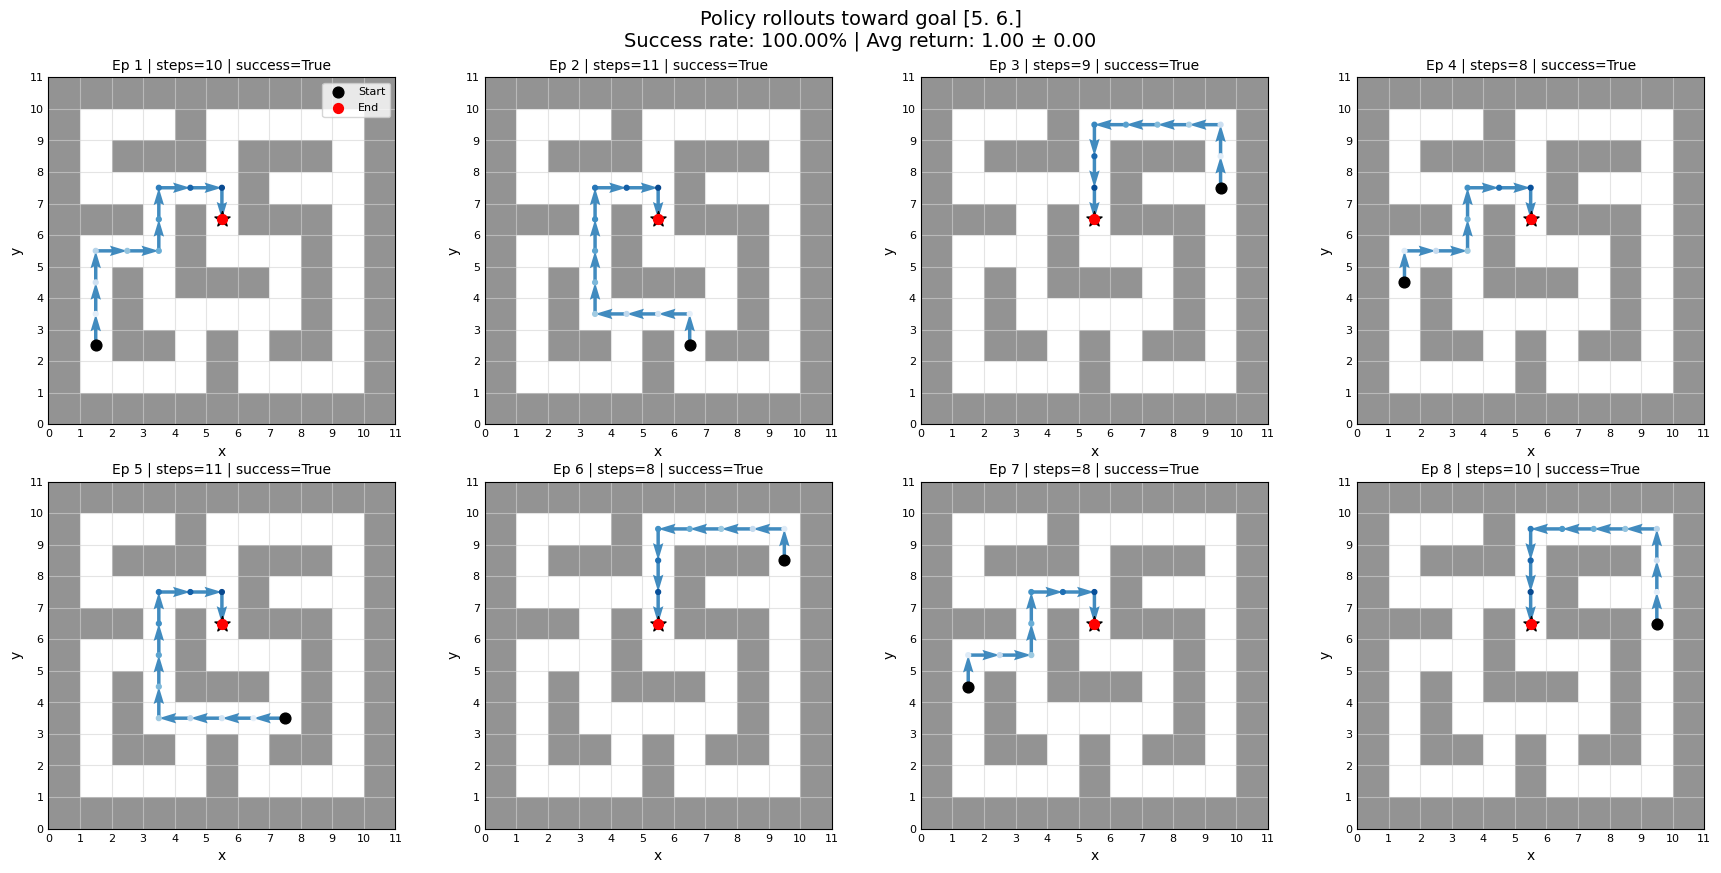

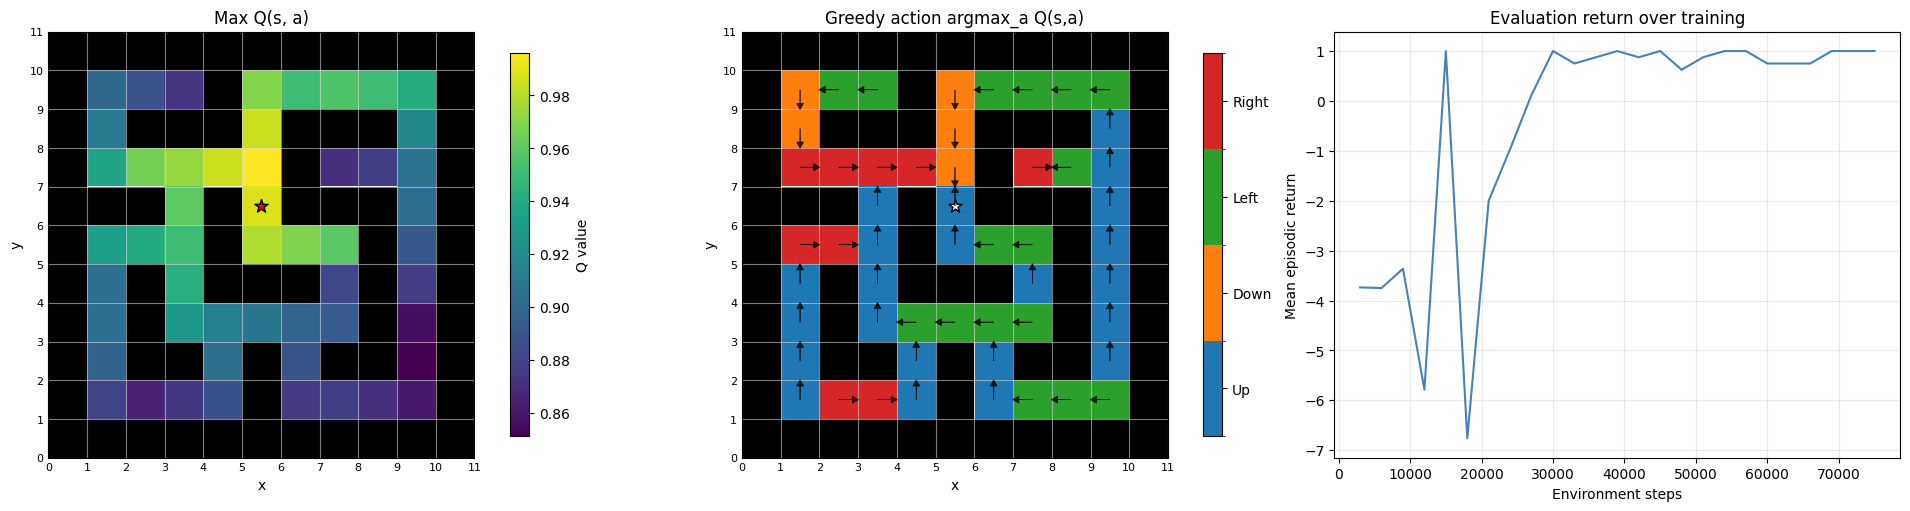

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 16)
psi(z) / task code base: (1, 16)

Diagnostic tensor devices: phi=cpu, psi=cpu

State-action encoder statistics
phi(s,a) norms: mean=0.9967, std=0.0147, min=0.8916, max=1.0000
top 5 singular values: [3.583446  3.5607104 2.8799872 2.284624  1.8782786]
cumulative variance (first 5 dimensions): [0.25709784 0.51094365 0.67700857 0.78151095 0.85214543]

Goal encoder statistics
psi(z) / task-code norm: 1.0000
psi(z) dimension values: mean=-0.0989, std=0.2372, min=-0.4575, max=0.4304
goal-code dimension magnitudes: [0.40044463 0.43043223 0.00582749 0.15621822 0.07637533]
goal-code cumulative squared magnitude (first 5 dimensions): [0.1603559  0.34562778 0.34566173 0.37006587 0.37589905]

Cosine similarity statistics
cos(phi(s,a), psi/task): mean=0.8656, std=0.0604, min=0.7534, max=0.9961


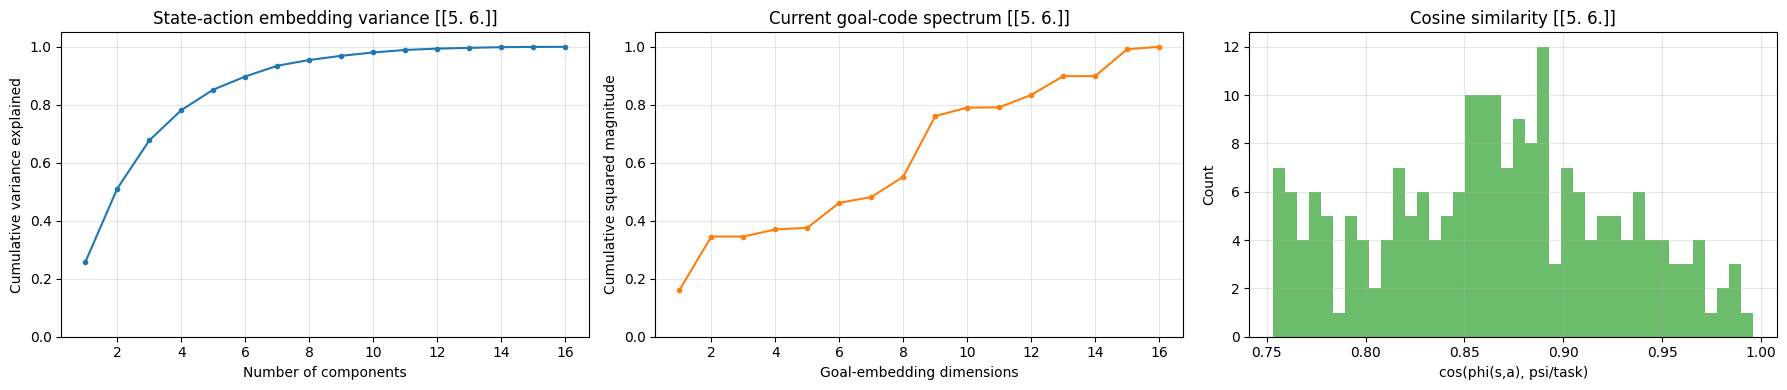

Raw psi norms: [1.0814129]
Raw psi norm mean/std: 1.0814129114151 0.0
Seed 42 | after task 0
Number of seen goals: 1
Goal embedding shape: (1, 16)
Goal labels: ['task_0']

Embedding statistics
Embedding norm: mean=1.000000, std=0.000000, min=1.000000, max=1.000000
Per-dimension standard deviation: mean=0.000000, std=0.000000, min=0.000000, max=0.000000

Pairwise distances and cosine similarities require at least two goals.

Goal embedding singular-value analysis
Top singular values: [0.]
Cumulative explained variance (first 5 components): [0.]
Numerical rank: 0
Effective rank: 0.000000
Maximum possible centred rank: 0

Collapse checks


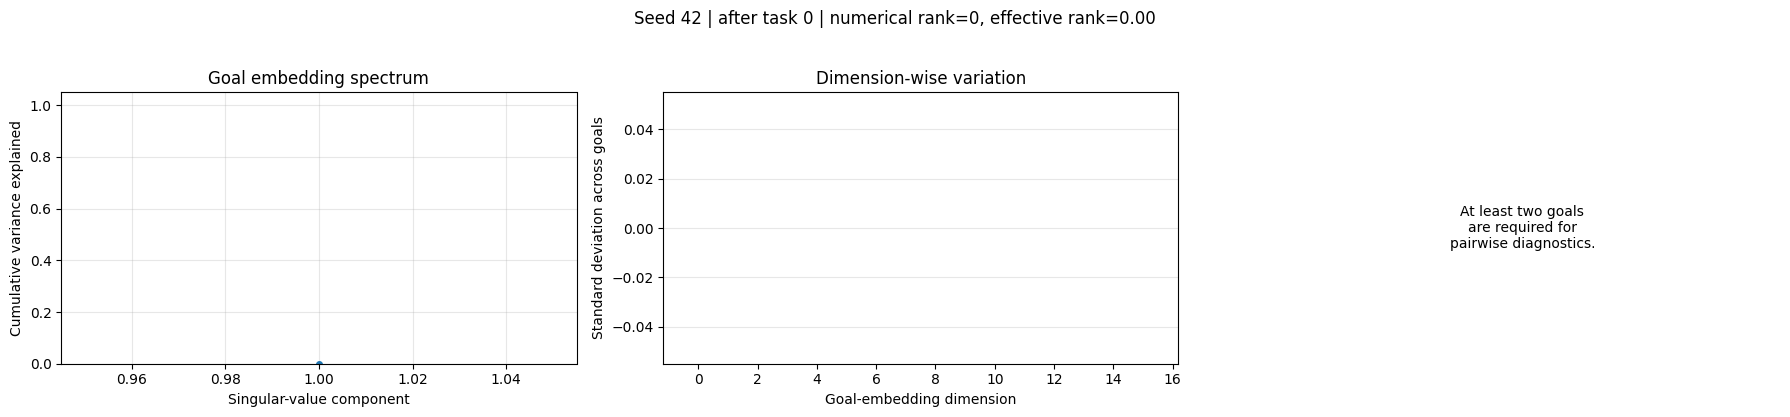

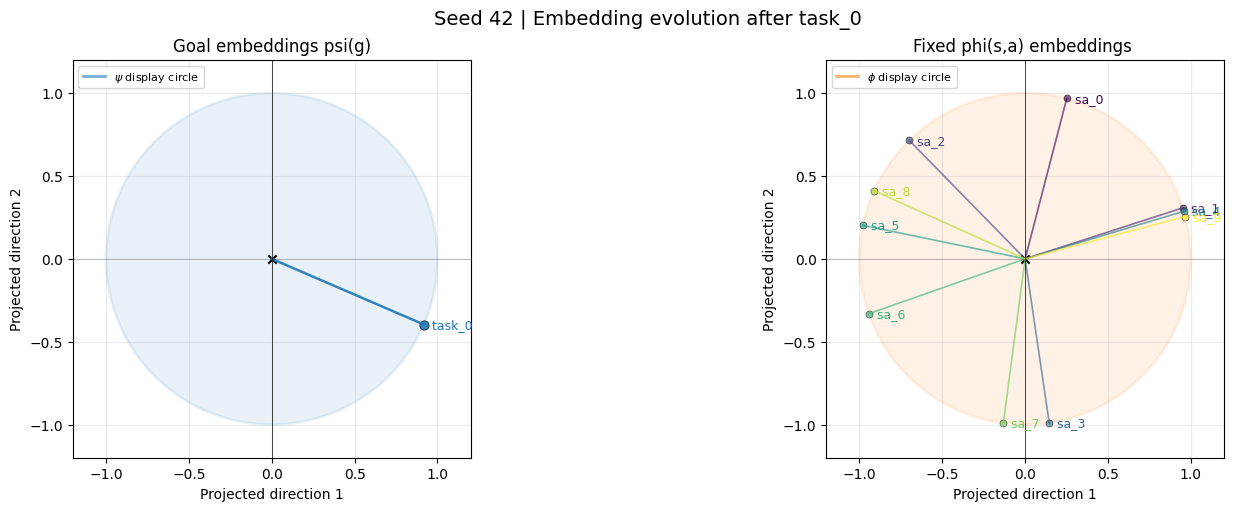


----- seed=42, task_idx=1, goal=[3. 5.] -----

[DQN-functional-phi-psi] step=   3000 | eps=0.953 | return=-1.237 | len=100.0 | Current=0.00038 | OldReplay=0.00019 | SIGReg=0.97417 | QBound=1.000 | ReplayTasks=1 | GoalSeparation=0.00065 | RawPsiNormLoss=0.013039 | RawPhiNormLoss=0.132343
[DQN-functional-phi-psi] step=   6000 | eps=0.905 | return=0.000 | len=100.0 | Current=0.00098 | OldReplay=0.00018 | SIGReg=0.97401 | QBound=1.000 | ReplayTasks=1 | GoalSeparation=0.00011 | RawPsiNormLoss=0.019699 | RawPhiNormLoss=0.095547
[DQN-functional-phi-psi] step=   9000 | eps=0.858 | return=0.375 | len=64.1 | Current=0.00060 | OldReplay=0.00015 | SIGReg=0.97249 | QBound=1.000 | ReplayTasks=1 | GoalSeparation=0.00040 | RawPsiNormLoss=0.021136 | RawPhiNormLoss=0.098553
[DQN-functional-phi-psi] step=  12000 | eps=0.810 | return=0.250 | len=76.0 | Current=0.00089 | OldReplay=0.00012 | SIGReg=0.97237 | QBound=1.000 | ReplayTasks=1 | GoalSeparation=0.00023 | RawPsiNormLoss=0.026268 | RawPhiNormLoss=0.

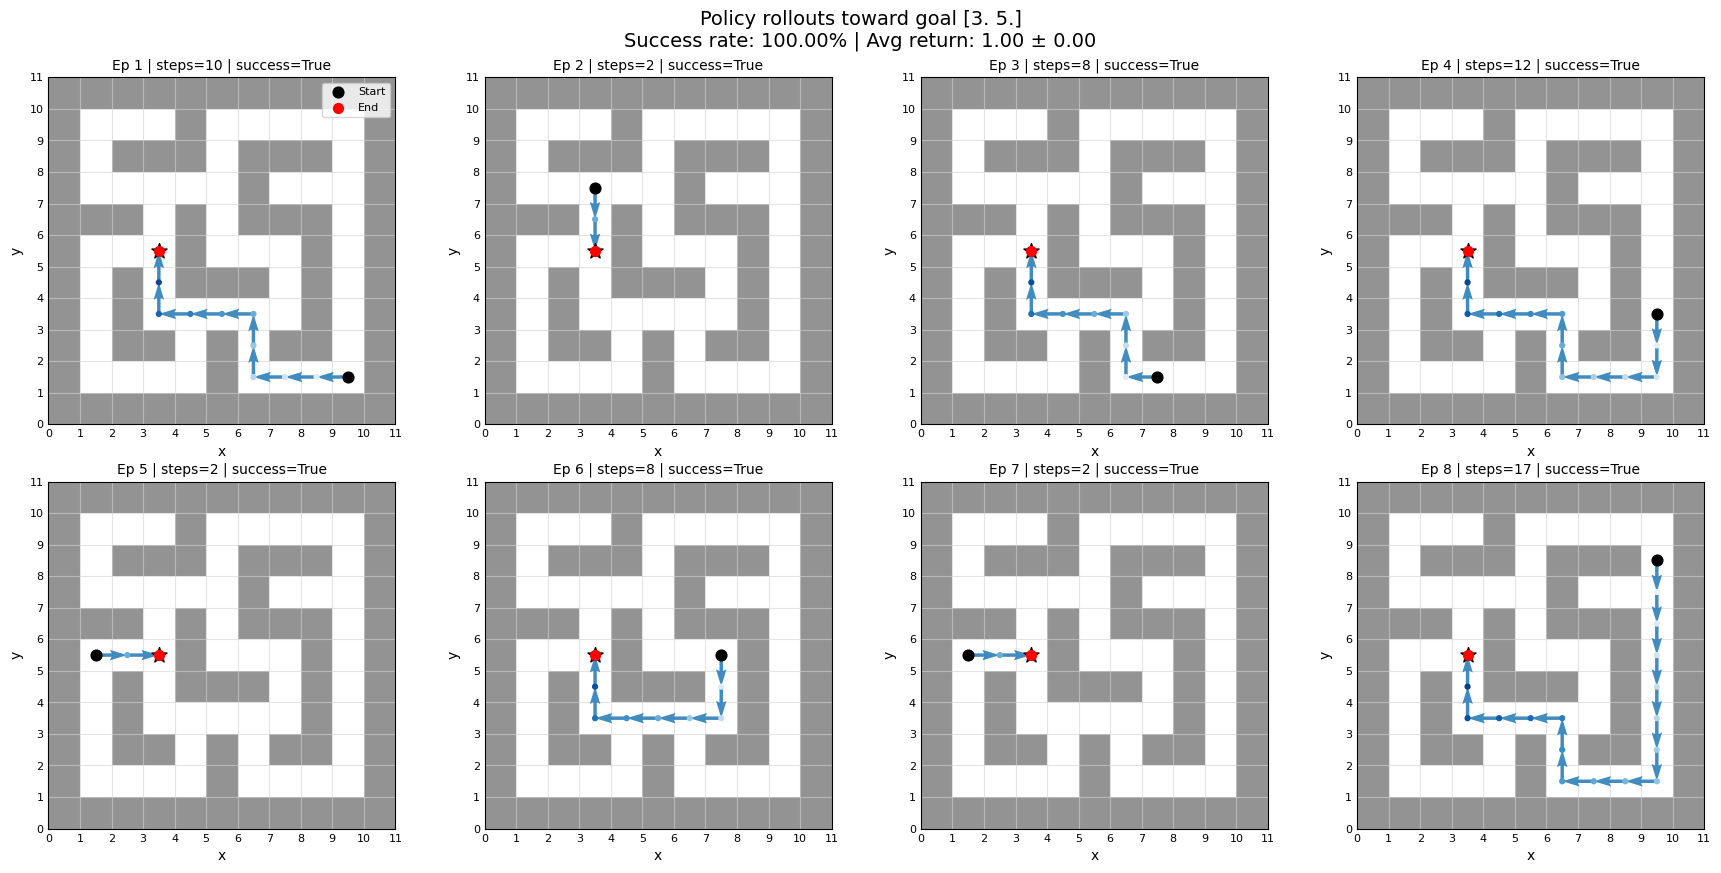

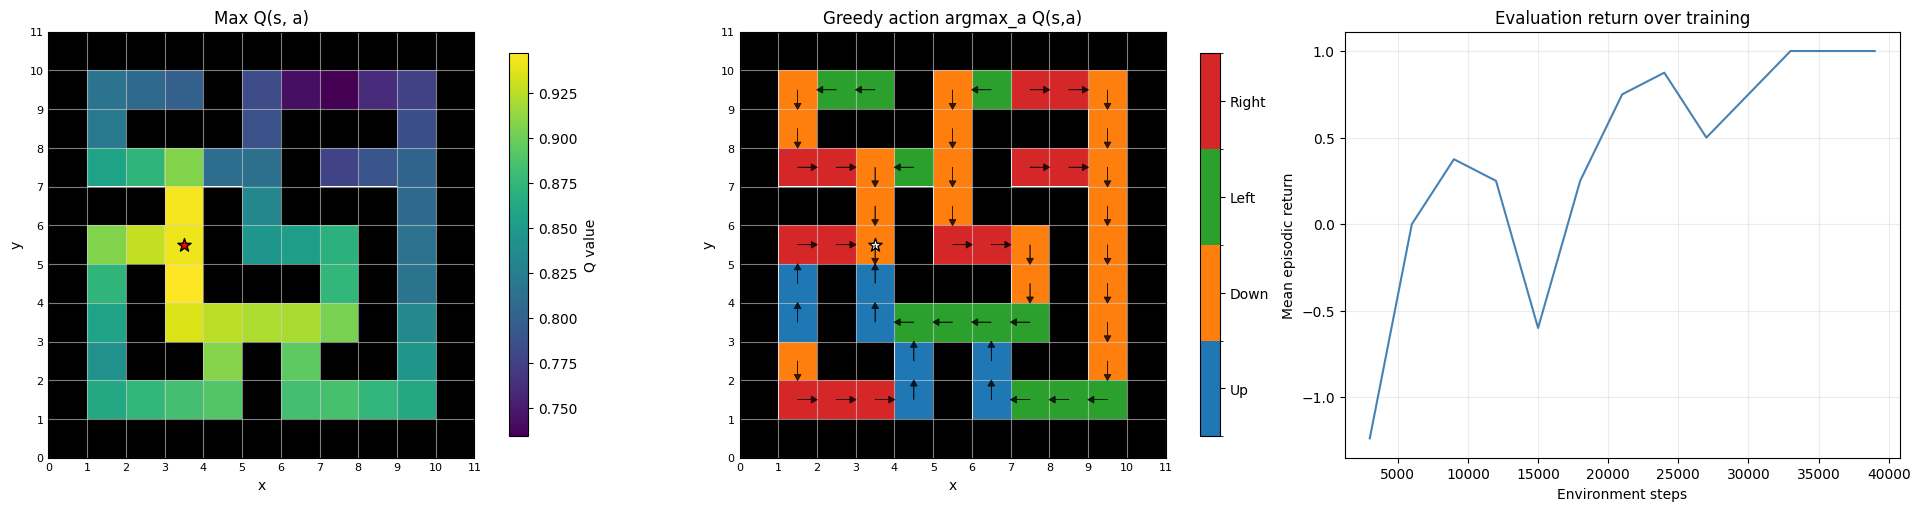

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 16)
psi(z) / task code base: (1, 16)

Diagnostic tensor devices: phi=cpu, psi=cpu

State-action encoder statistics
phi(s,a) norms: mean=0.9949, std=0.0186, min=0.8651, max=1.0000
top 5 singular values: [3.1603615 2.8873417 2.7667134 2.2023687 1.9155307]
cumulative variance (first 5 dimensions): [0.23340607 0.4282267  0.60710883 0.7204581  0.8062047 ]

Goal encoder statistics
psi(z) / task-code norm: 1.0000
psi(z) dimension values: mean=-0.0791, std=0.2449, min=-0.5915, max=0.4756
goal-code dimension magnitudes: [0.26810008 0.19777997 0.056669   0.36553776 0.14658852]
goal-code cumulative squared magnitude (first 5 dimensions): [0.07187765 0.11099456 0.11420594 0.2478238  0.269312  ]

Cosine similarity statistics
cos(phi(s,a), psi/task): mean=0.7981, std=0.0735, min=0.6099, max=0.9469


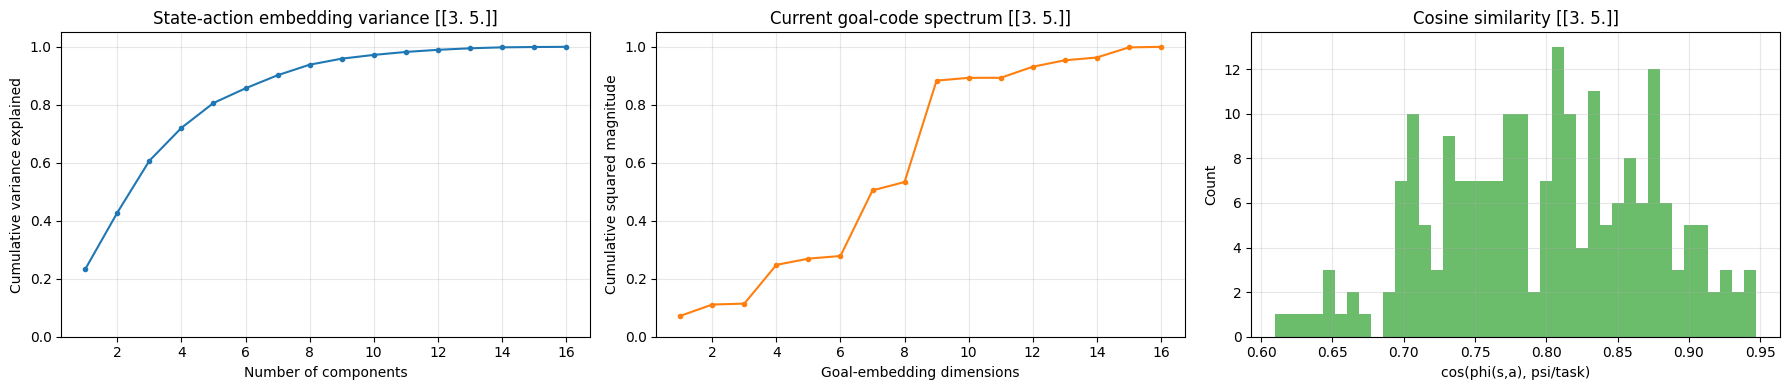

Raw psi norms: [1.0881317]
Raw psi norm mean/std: 1.0881316661834717 0.0
Seed 42 | after task 1
Number of seen goals: 2
Goal embedding shape: (2, 16)
Goal labels: ['task_0', 'task_1']

Embedding statistics
Embedding norm: mean=1.000000, std=0.000000, min=1.000000, max=1.000000
Per-dimension standard deviation: mean=0.075767, std=0.049782, min=0.006002, max=0.188026

Pairwise goal distances
Distance: mean=0.725266, std=0.000000, min=0.725266, max=0.725266
Pairwise cosine similarity: mean=0.736995, std=0.000000, min=0.736995, max=0.736995

Goal embedding singular-value analysis
Top singular values: [5.1284033e-01 4.0208068e-08]
Cumulative explained variance (first 5 components): [1. 1.]
Numerical rank: 1
Effective rank: 1.000000
Maximum possible centred rank: 1

Covariance diagnostics
Covariance diagonal: mean=0.016438, std=0.019153, min=0.000072, max=0.070707
Off-diagonal covariance Frobenius ratio: 0.923387

Collapse checks
Pairwise-distance check: embeddings are not completely collaps

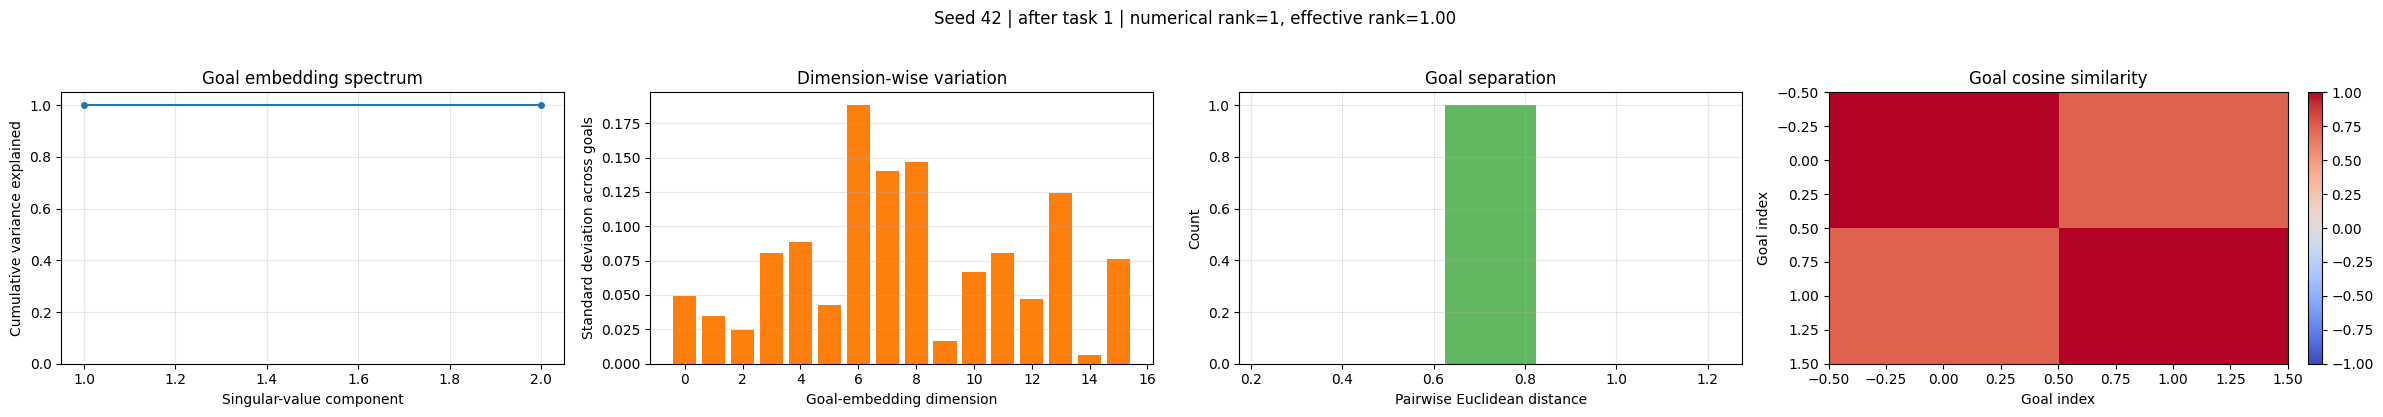

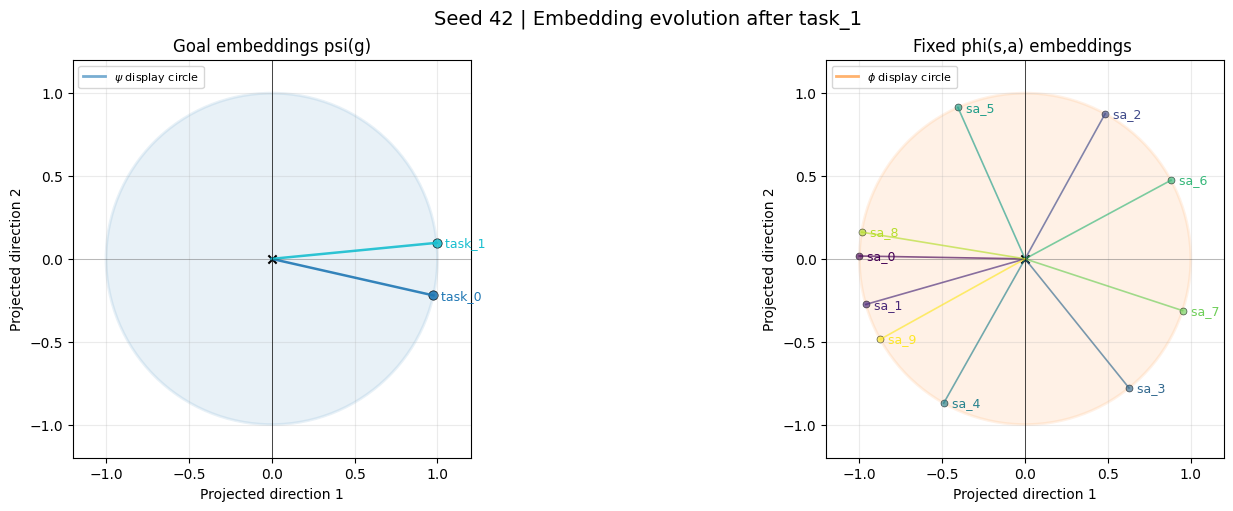


----- seed=42, task_idx=2, goal=[3. 3.] -----

[DQN-functional-phi-psi] step=   3000 | eps=0.953 | return=-1.000 | len=75.9 | Current=0.00084 | OldReplay=0.00041 | SIGReg=0.97396 | QBound=1.000 | ReplayTasks=2 | GoalSeparation=0.00255 | RawPsiNormLoss=0.014044 | RawPhiNormLoss=0.166649
[DQN-functional-phi-psi] step=   6000 | eps=0.905 | return=-0.600 | len=41.2 | Current=0.00093 | OldReplay=0.00040 | SIGReg=0.97430 | QBound=1.000 | ReplayTasks=2 | GoalSeparation=0.00348 | RawPsiNormLoss=0.025290 | RawPhiNormLoss=0.239209
[DQN-functional-phi-psi] step=   9000 | eps=0.858 | return=0.875 | len=16.6 | Current=0.00059 | OldReplay=0.00049 | SIGReg=0.97160 | QBound=1.000 | ReplayTasks=2 | GoalSeparation=0.00397 | RawPsiNormLoss=0.034032 | RawPhiNormLoss=0.219780
[DQN-functional-phi-psi] step=  12000 | eps=0.810 | return=-0.350 | len=18.8 | Current=0.00055 | OldReplay=0.00031 | SIGReg=0.97220 | QBound=1.000 | ReplayTasks=2 | GoalSeparation=0.00342 | RawPsiNormLoss=0.036741 | RawPhiNormLoss=0.

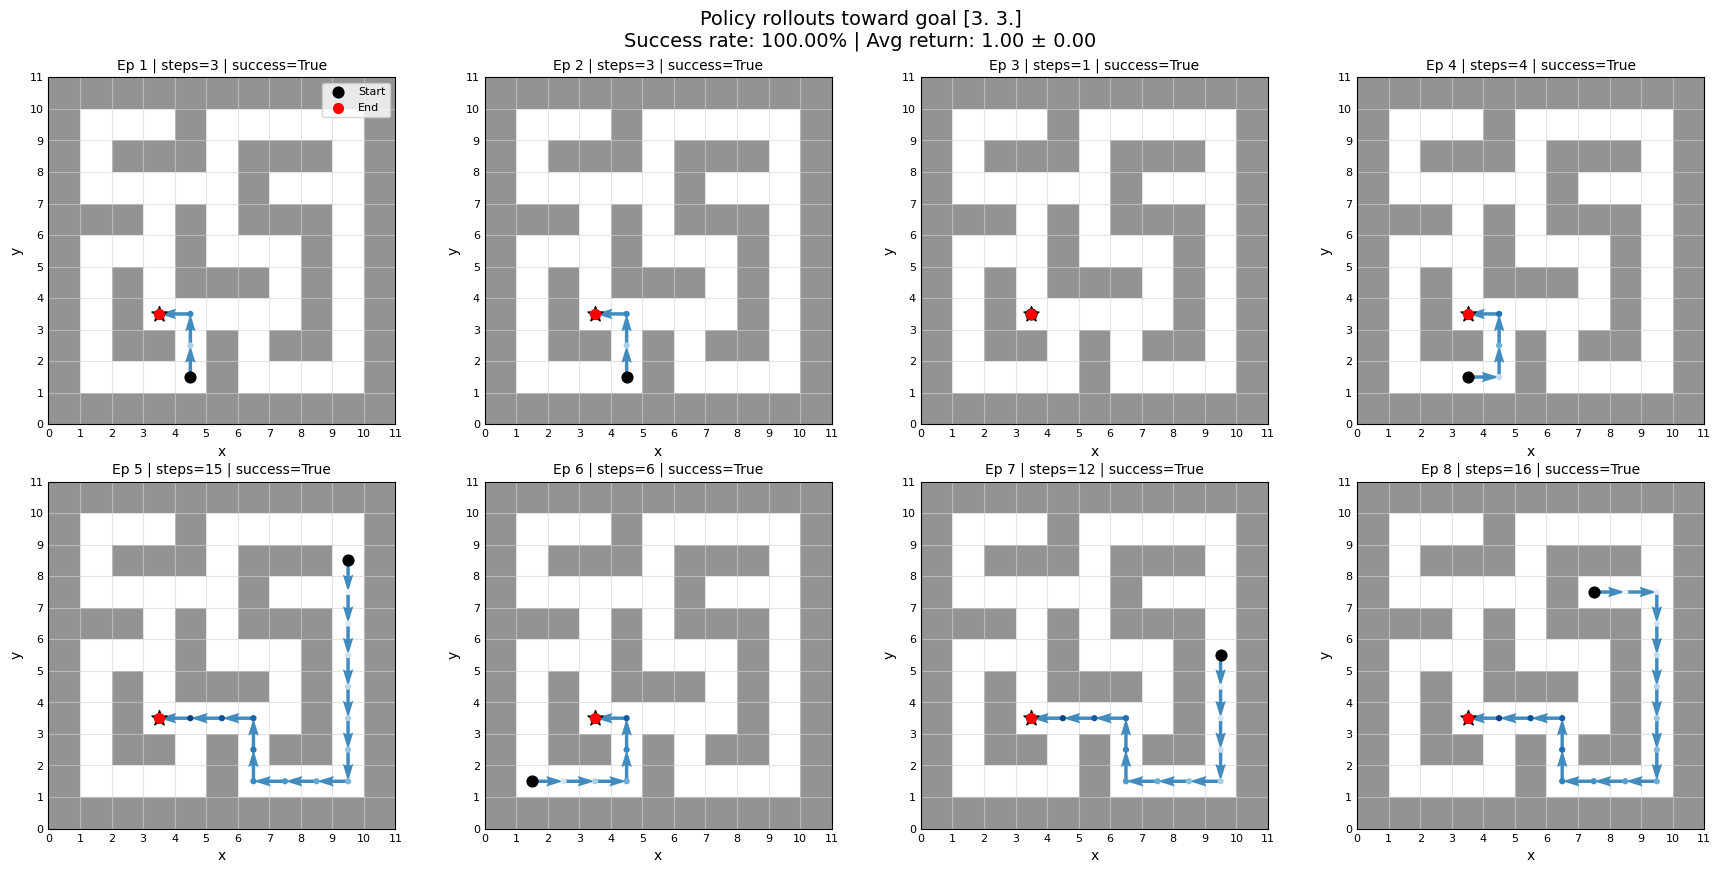

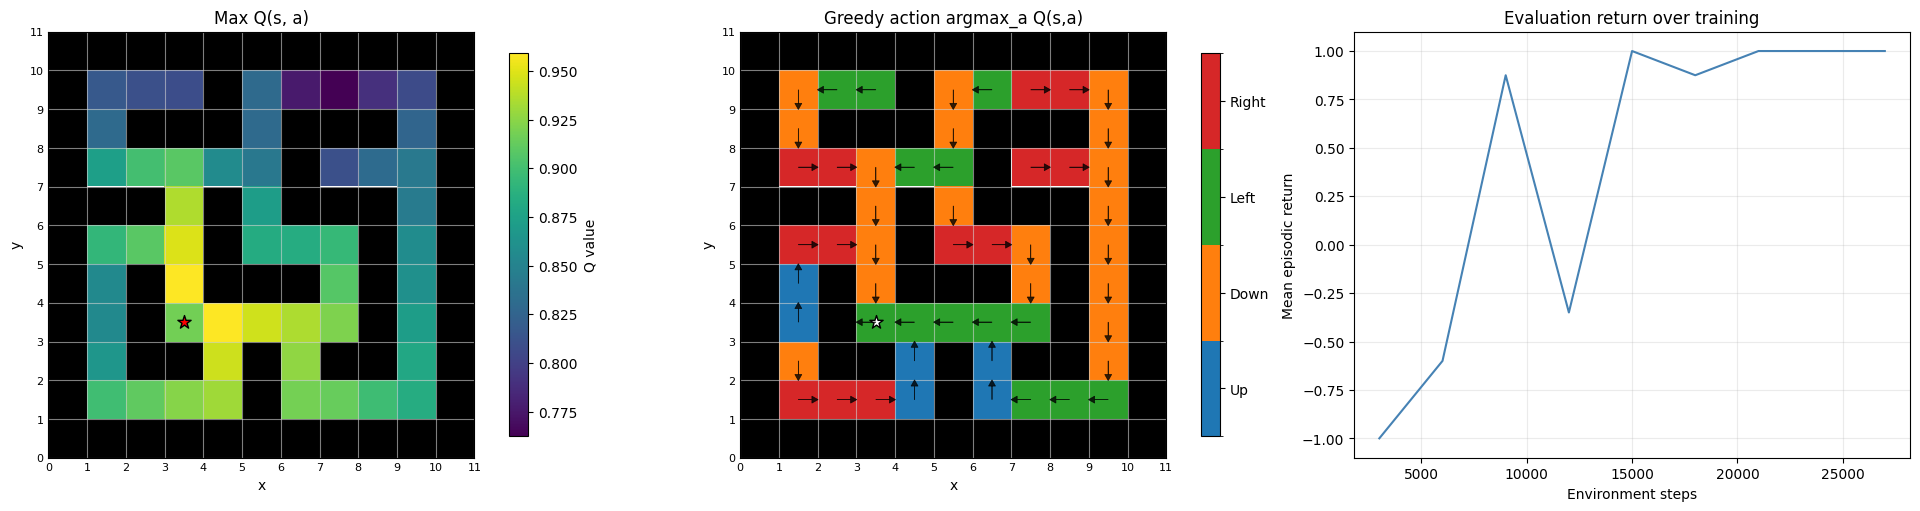

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 16)
psi(z) / task code base: (1, 16)

Diagnostic tensor devices: phi=cpu, psi=cpu

State-action encoder statistics
phi(s,a) norms: mean=0.9962, std=0.0178, min=0.8599, max=1.0000
top 5 singular values: [3.3728106 2.8748639 2.4684553 2.0446117 1.6588702]
cumulative variance (first 5 dimensions): [0.2820775  0.48701388 0.63810366 0.74176246 0.8099978 ]

Goal encoder statistics
psi(z) / task-code norm: 1.0000
psi(z) dimension values: mean=-0.0669, std=0.2488, min=-0.3735, max=0.3654
goal-code dimension magnitudes: [0.2833766  0.32317746 0.1063756  0.2995942  0.19565062]
goal-code cumulative squared magnitude (first 5 dimensions): [0.08030232 0.18474601 0.19606179 0.2858185  0.32409766]

Cosine similarity statistics
cos(phi(s,a), psi/task): mean=0.8210, std=0.0696, min=0.6480, max=0.9593


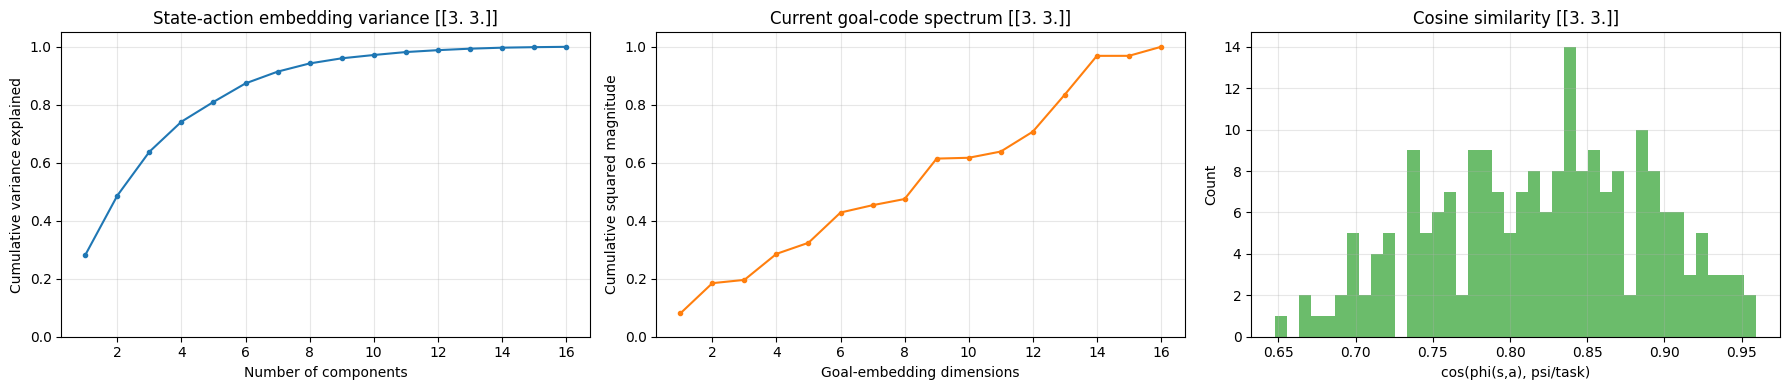

Raw psi norms: [1.0487144]
Raw psi norm mean/std: 1.0487143993377686 0.0
Seed 42 | after task 2
Number of seen goals: 3
Goal embedding shape: (3, 16)
Goal labels: ['task_0', 'task_1', 'task_2']

Embedding statistics
Embedding norm: mean=1.000000, std=0.000000, min=1.000000, max=1.000000
Per-dimension standard deviation: mean=0.087755, std=0.045754, min=0.028871, max=0.198279

Pairwise goal distances
Distance: mean=0.685643, std=0.004725, min=0.678973, max=0.689306
Pairwise cosine similarity: mean=0.764935, std=0.003232, min=0.762429, max=0.769498

Goal embedding singular-value analysis
Top singular values: [4.8952511e-01 4.8009843e-01 5.4851970e-08]
Cumulative explained variance (first 5 components): [0.5097211 1.        1.       ]
Numerical rank: 2
Effective rank: 1.999622
Maximum possible centred rank: 2

Covariance diagnostics
Covariance diagonal: mean=0.014692, std=0.015196, min=0.001250, max=0.058972
Off-diagonal covariance Frobenius ratio: 0.861031

Collapse checks
Pairwise-dista

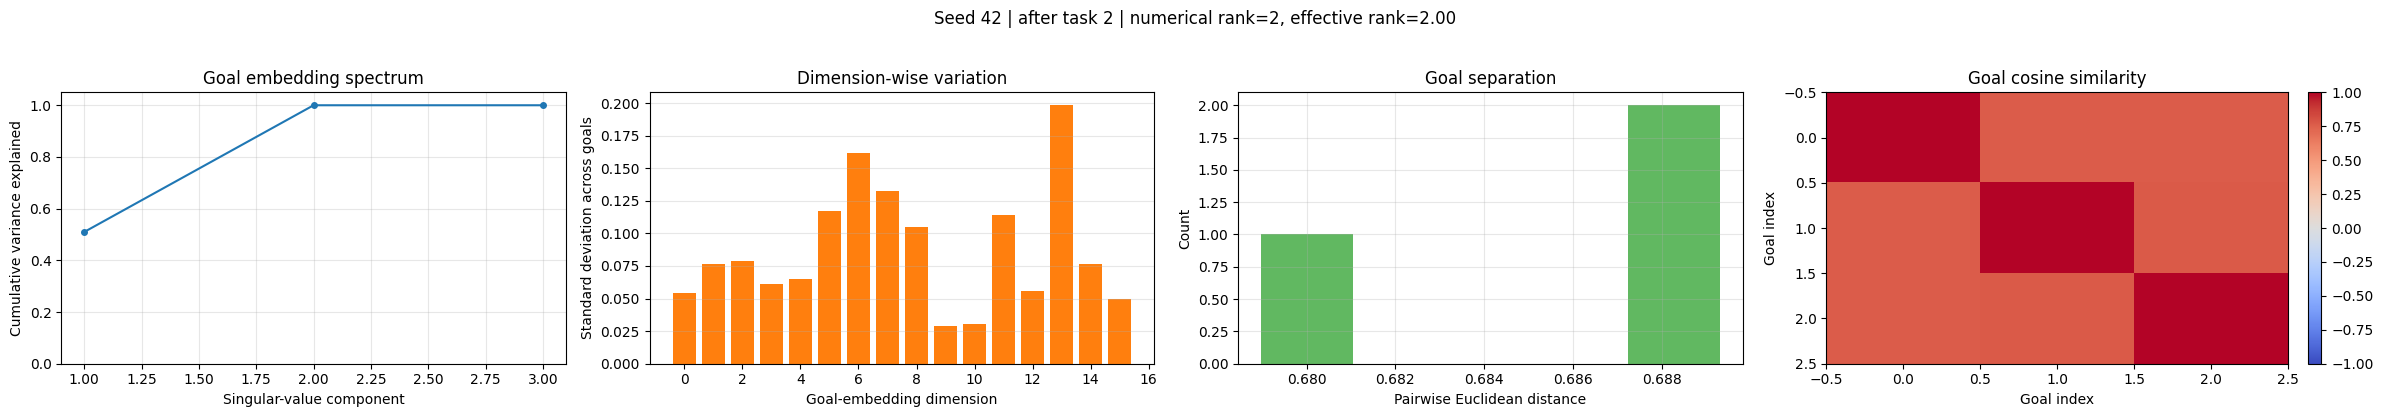

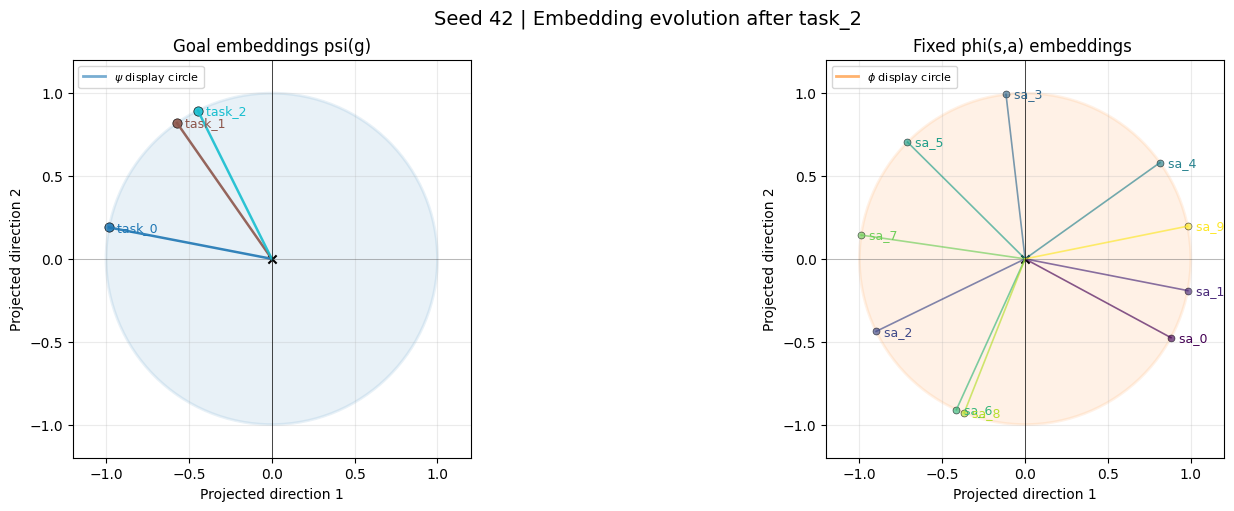


----- seed=42, task_idx=3, goal=[6. 3.] -----

[DQN-functional-phi-psi] step=   3000 | eps=0.953 | return=0.500 | len=51.5 | Current=0.00094 | OldReplay=0.00032 | SIGReg=0.97220 | QBound=1.000 | ReplayTasks=3 | GoalSeparation=0.00480 | RawPsiNormLoss=0.062001 | RawPhiNormLoss=0.124701
[DQN-functional-phi-psi] step=   6000 | eps=0.905 | return=0.500 | len=51.8 | Current=0.00059 | OldReplay=0.00041 | SIGReg=0.97493 | QBound=1.000 | ReplayTasks=3 | GoalSeparation=0.00576 | RawPsiNormLoss=0.034846 | RawPhiNormLoss=0.176634
[DQN-functional-phi-psi] step=   9000 | eps=0.858 | return=1.000 | len=8.5 | Current=0.00045 | OldReplay=0.00042 | SIGReg=0.97340 | QBound=1.000 | ReplayTasks=3 | GoalSeparation=0.00485 | RawPsiNormLoss=0.028330 | RawPhiNormLoss=0.127032
[DQN-functional-phi-psi] step=  12000 | eps=0.810 | return=1.000 | len=6.1 | Current=0.00031 | OldReplay=0.00039 | SIGReg=0.97601 | QBound=1.000 | ReplayTasks=3 | GoalSeparation=0.00470 | RawPsiNormLoss=0.019307 | RawPhiNormLoss=0.12087

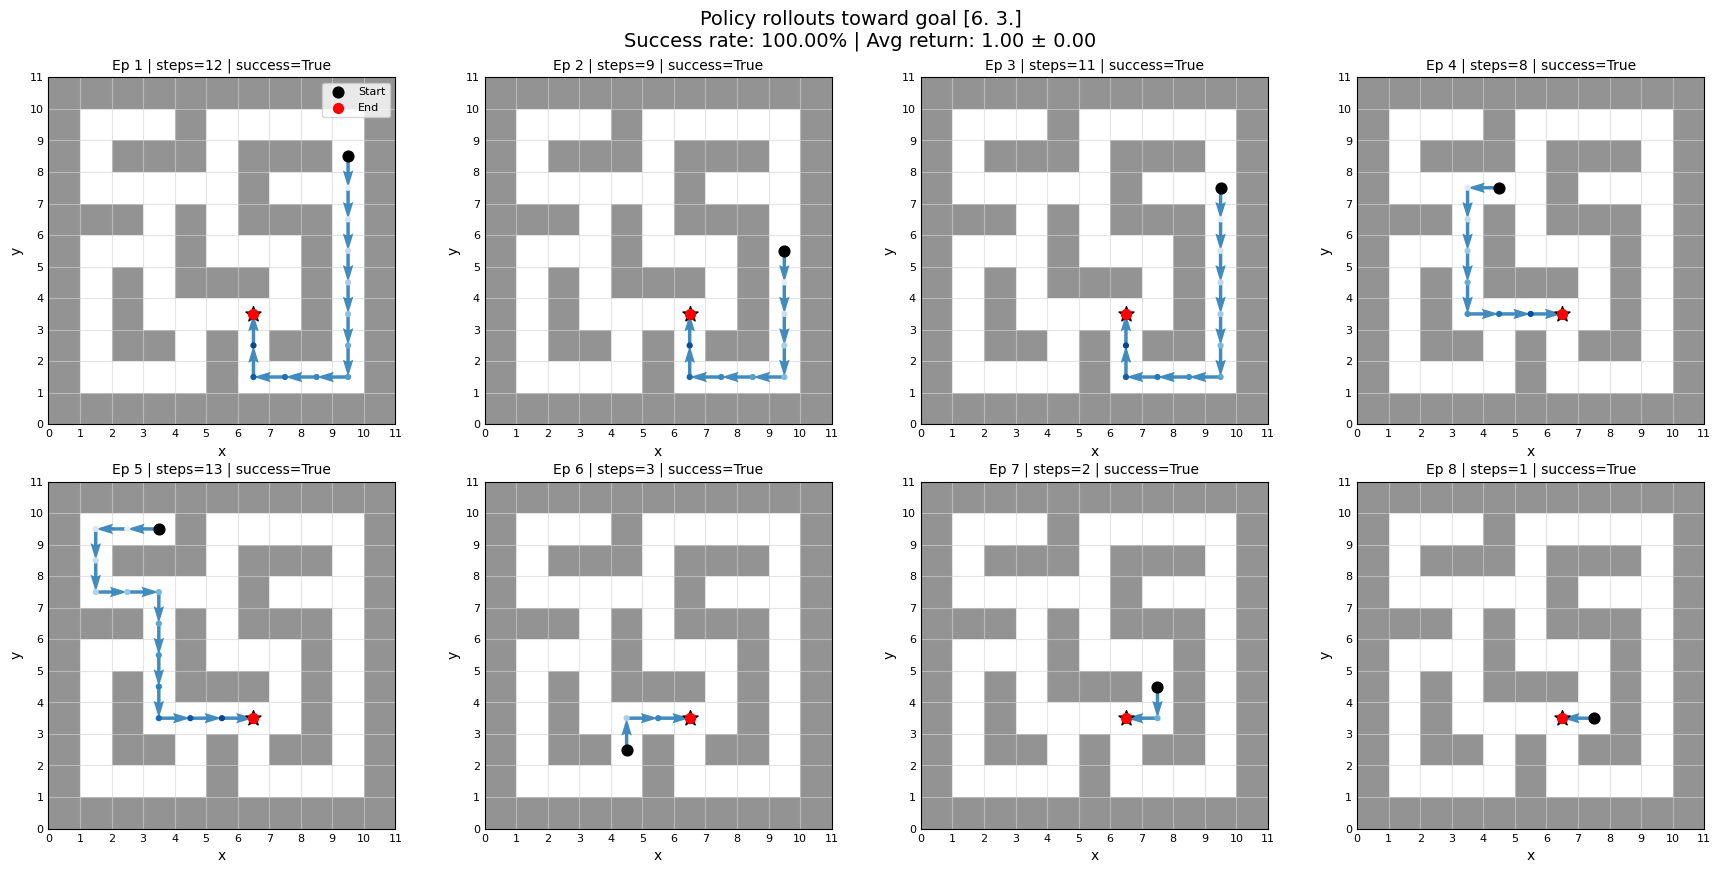

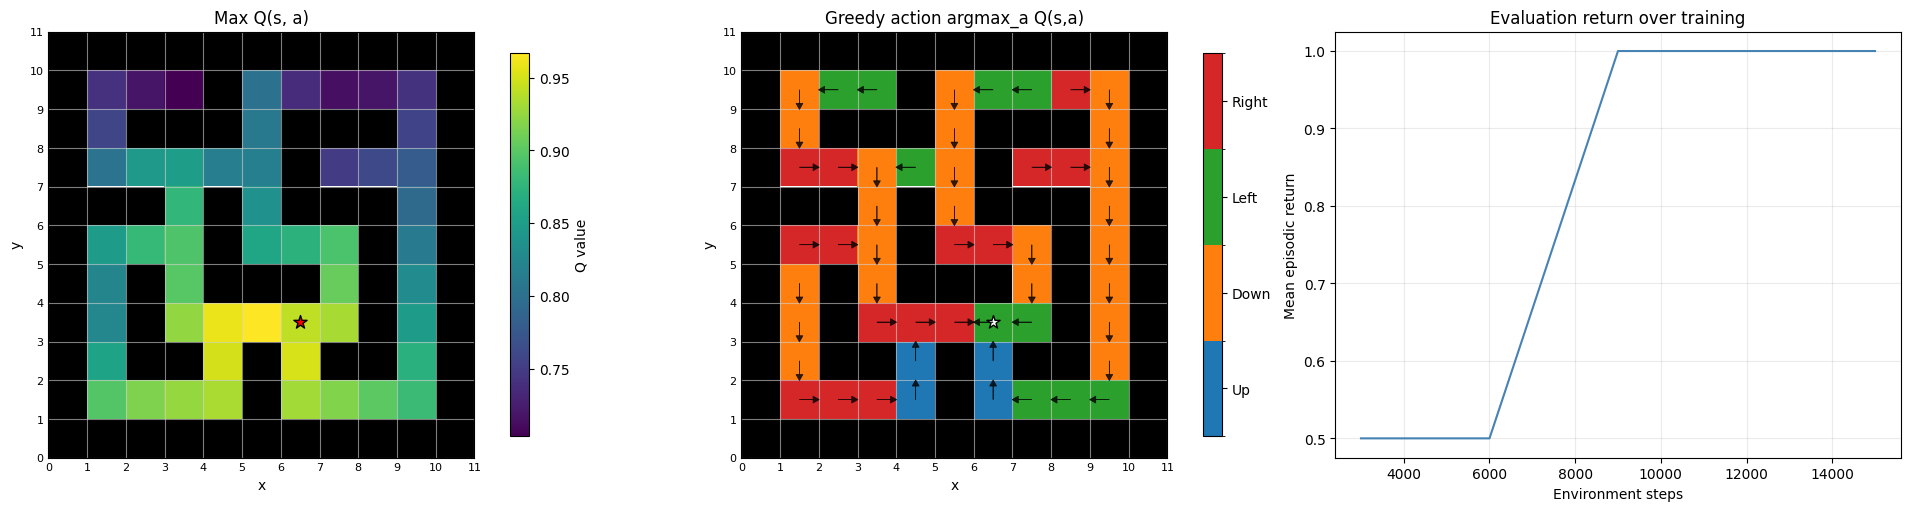

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 16)
psi(z) / task code base: (1, 16)

Diagnostic tensor devices: phi=cpu, psi=cpu

State-action encoder statistics
phi(s,a) norms: mean=0.9967, std=0.0159, min=0.8789, max=1.0000
top 5 singular values: [3.4022722 2.9539113 2.4078608 1.9799305 1.8904884]
cumulative variance (first 5 dimensions): [0.28186023 0.49432677 0.635502   0.7309563  0.81798124]

Goal encoder statistics
psi(z) / task-code norm: 1.0000
psi(z) dimension values: mean=-0.0692, std=0.2481, min=-0.4200, max=0.2924
goal-code dimension magnitudes: [0.28113148 0.26032758 0.12674898 0.3447254  0.04340351]
goal-code cumulative squared magnitude (first 5 dimensions): [0.07903493 0.1468054  0.1628707  0.28170633 0.2835902 ]

Cosine similarity statistics
cos(phi(s,a), psi/task): mean=0.7867, std=0.0891, min=0.5898, max=0.9671


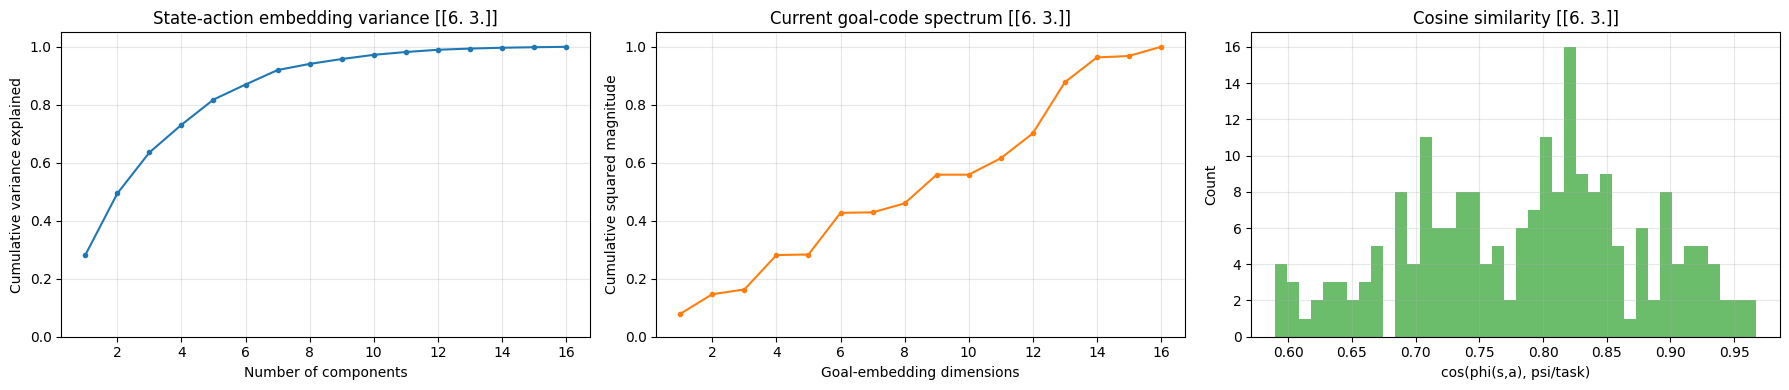

Raw psi norms: [1.1417377]
Raw psi norm mean/std: 1.141737699508667 0.0
Seed 42 | after task 3
Number of seen goals: 4
Goal embedding shape: (4, 16)
Goal labels: ['task_0', 'task_1', 'task_2', 'task_3']

Embedding statistics
Embedding norm: mean=1.000000, std=0.000000, min=1.000000, max=1.000000
Per-dimension standard deviation: mean=0.088948, std=0.051784, min=0.021858, max=0.195790

Pairwise goal distances
Distance: mean=0.671808, std=0.025567, min=0.642562, max=0.720739
Pairwise cosine similarity: mean=0.774010, std=0.017462, min=0.740268, max=0.793557

Goal embedding singular-value analysis
Top singular values: [5.1268089e-01 4.6339321e-01 4.4765553e-01 3.0433640e-08]
Cumulative explained variance (first 5 components): [0.38768902 0.70441854 1.         1.        ]
Numerical rank: 3
Effective rank: 2.979512
Maximum possible centred rank: 3

Covariance diagnostics
Covariance diagonal: mean=0.014124, std=0.013258, min=0.000637, max=0.051112
Off-diagonal covariance Frobenius ratio: 0.8

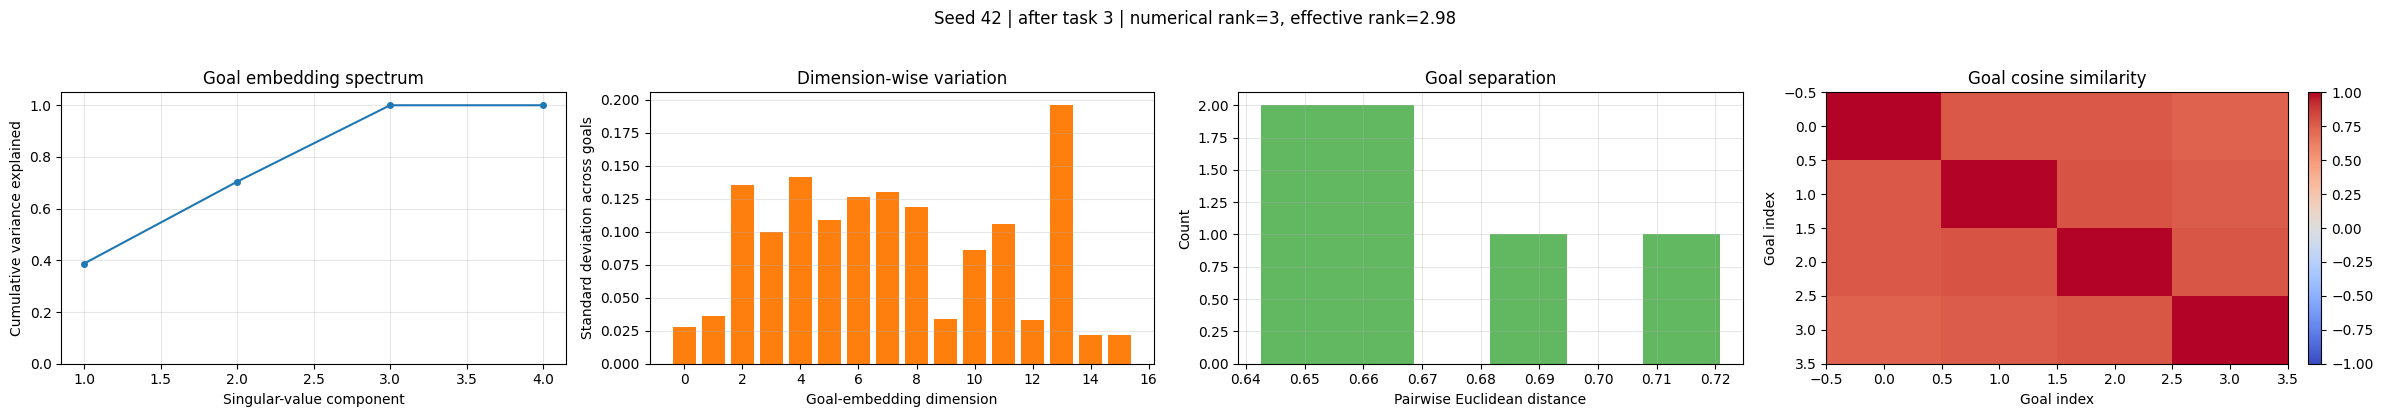

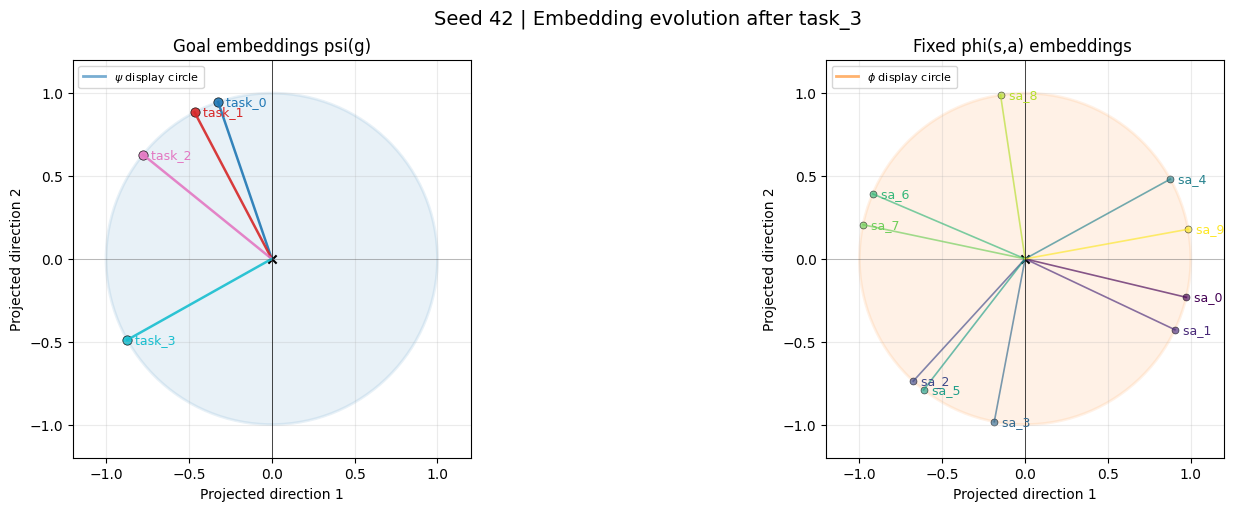


----- seed=42, task_idx=4, goal=[9. 7.] -----

[DQN-functional-phi-psi] step=   3000 | eps=0.953 | return=0.125 | len=87.9 | Current=0.00035 | OldReplay=0.00040 | SIGReg=0.97809 | QBound=1.000 | ReplayTasks=4 | GoalSeparation=0.00545 | RawPsiNormLoss=0.035315 | RawPhiNormLoss=0.131990
[DQN-functional-phi-psi] step=   6000 | eps=0.905 | return=0.500 | len=51.9 | Current=0.00026 | OldReplay=0.00034 | SIGReg=0.97837 | QBound=1.000 | ReplayTasks=4 | GoalSeparation=0.00473 | RawPsiNormLoss=0.031587 | RawPhiNormLoss=0.113826
[DQN-functional-phi-psi] step=   9000 | eps=0.858 | return=0.125 | len=87.8 | Current=0.00022 | OldReplay=0.00040 | SIGReg=0.97843 | QBound=1.000 | ReplayTasks=4 | GoalSeparation=0.00438 | RawPsiNormLoss=0.031141 | RawPhiNormLoss=0.107927
[DQN-functional-phi-psi] step=  12000 | eps=0.810 | return=0.000 | len=100.0 | Current=0.00025 | OldReplay=0.00032 | SIGReg=0.98024 | QBound=1.000 | ReplayTasks=4 | GoalSeparation=0.00457 | RawPsiNormLoss=0.033974 | RawPhiNormLoss=0.10

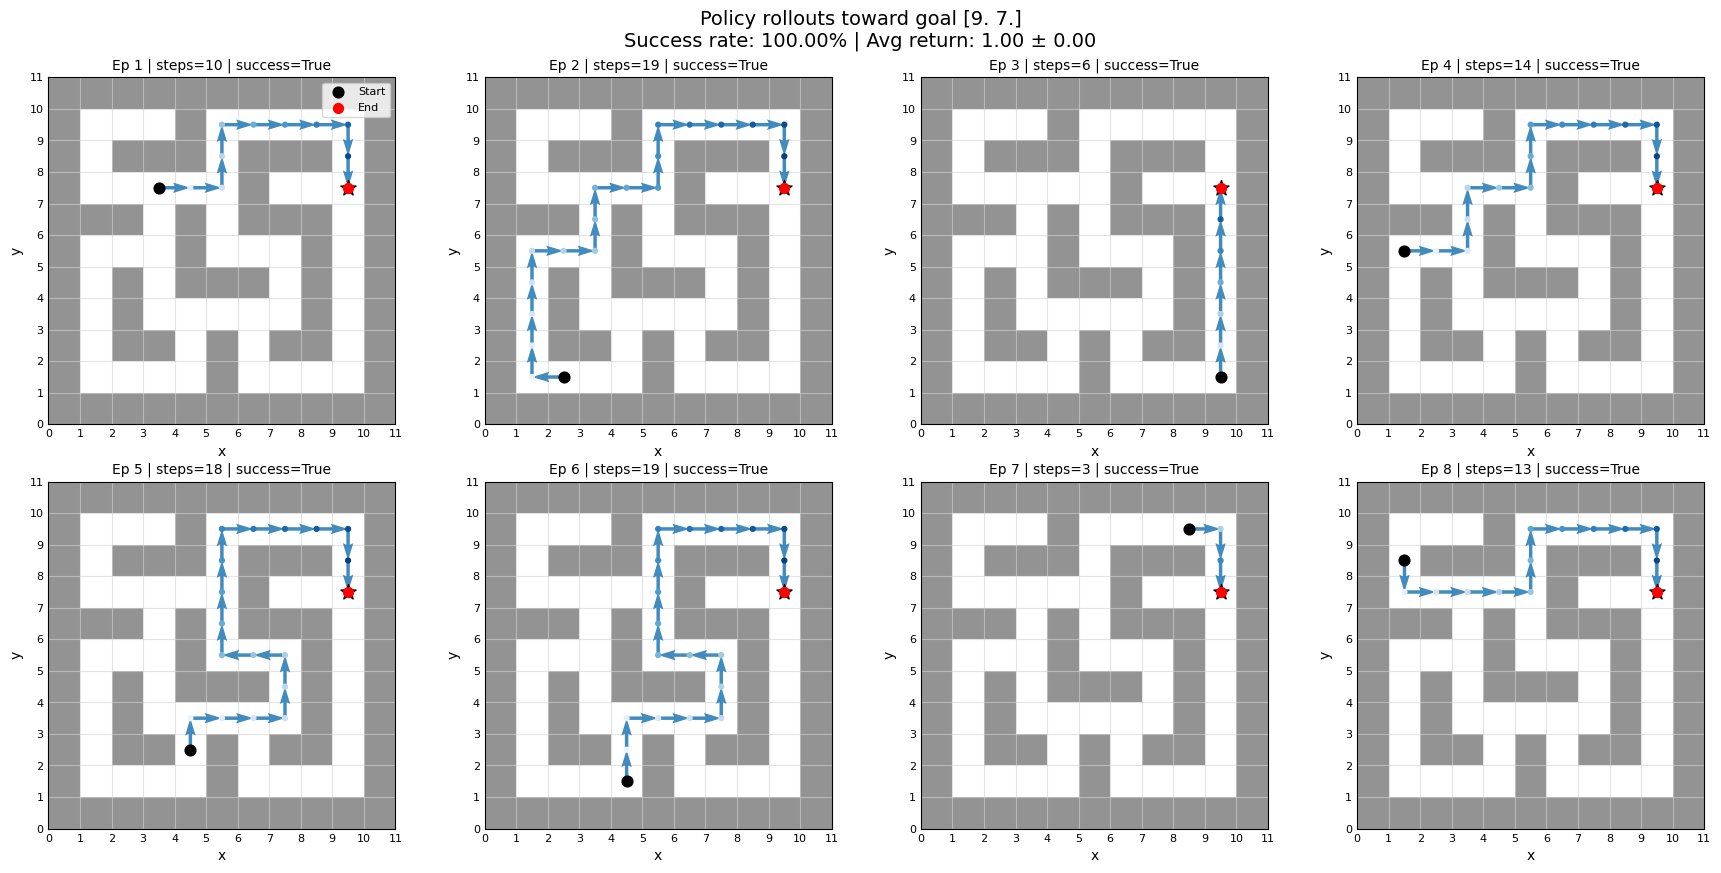

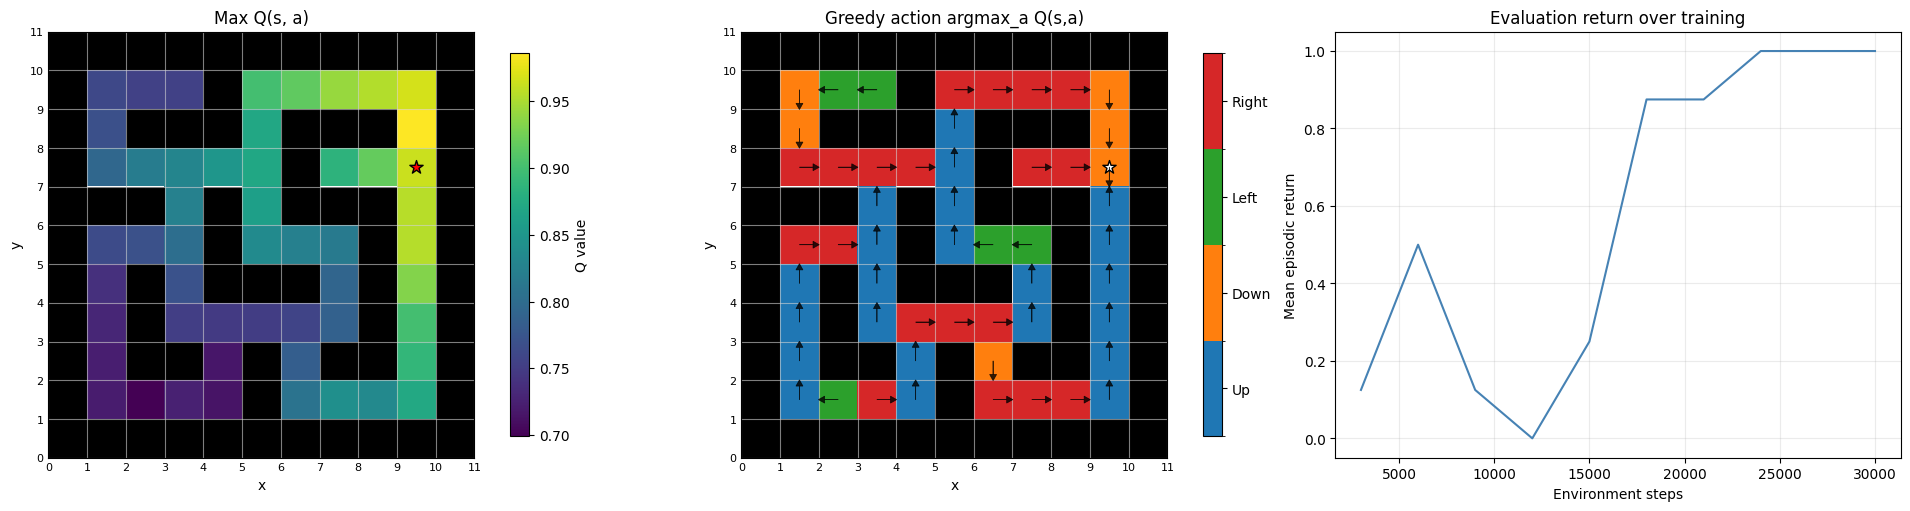

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 16)
psi(z) / task code base: (1, 16)

Diagnostic tensor devices: phi=cpu, psi=cpu

State-action encoder statistics
phi(s,a) norms: mean=0.9939, std=0.0224, min=0.8545, max=1.0000
top 5 singular values: [3.3479426 2.950536  2.2022784 2.096403  1.9014404]
cumulative variance (first 5 dimensions): [0.27507854 0.48872837 0.6077553  0.71561277 0.8043419 ]

Goal encoder statistics
psi(z) / task-code norm: 1.0000
psi(z) dimension values: mean=-0.1360, std=0.2166, min=-0.4679, max=0.2219
goal-code dimension magnitudes: [0.32637534 0.0981805  0.0311285  0.17171936 0.07713824]
goal-code cumulative squared magnitude (first 5 dimensions): [0.10652088 0.1161603  0.11712928 0.14661682 0.15256712]

Cosine similarity statistics
cos(phi(s,a), psi/task): mean=0.7720, std=0.0910, min=0.5860, max=0.9862


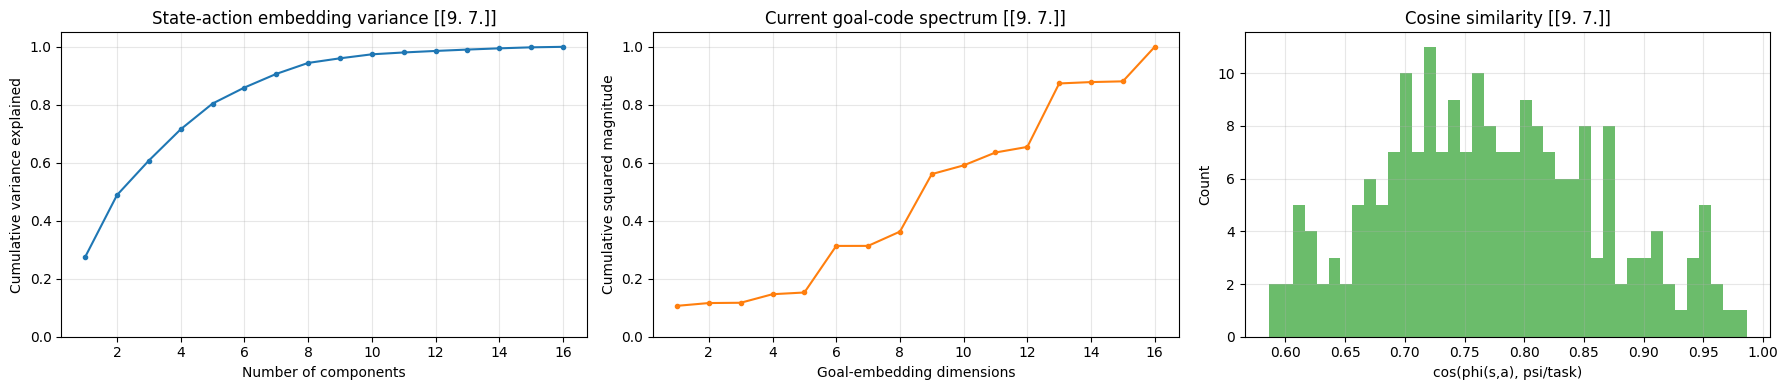

Raw psi norms: [1.2527484]
Raw psi norm mean/std: 1.2527483701705933 0.0
Seed 42 | after task 4
Number of seen goals: 5
Goal embedding shape: (5, 16)
Goal labels: ['task_0', 'task_1', 'task_2', 'task_3', 'task_4']

Embedding statistics
Embedding norm: mean=1.000000, std=0.000000, min=1.000000, max=1.000000
Per-dimension standard deviation: mean=0.099154, std=0.048057, min=0.024815, max=0.211555

Pairwise goal distances
Distance: mean=0.695575, std=0.042568, min=0.629129, max=0.758133
Pairwise cosine similarity: mean=0.757181, std=0.029766, min=0.712617, max=0.802099

Goal embedding singular-value analysis
Top singular values: [5.6654596e-01 5.0309426e-01 4.5474124e-01 4.3635616e-01 6.8689737e-08]
Cumulative explained variance (first 5 components): [0.33046716 0.5910566  0.803962   1.         1.        ]
Numerical rank: 4
Effective rank: 3.916234
Maximum possible centred rank: 4

Covariance diagnostics
Covariance diagonal: mean=0.015176, std=0.013933, min=0.000770, max=0.055944
Off-diag

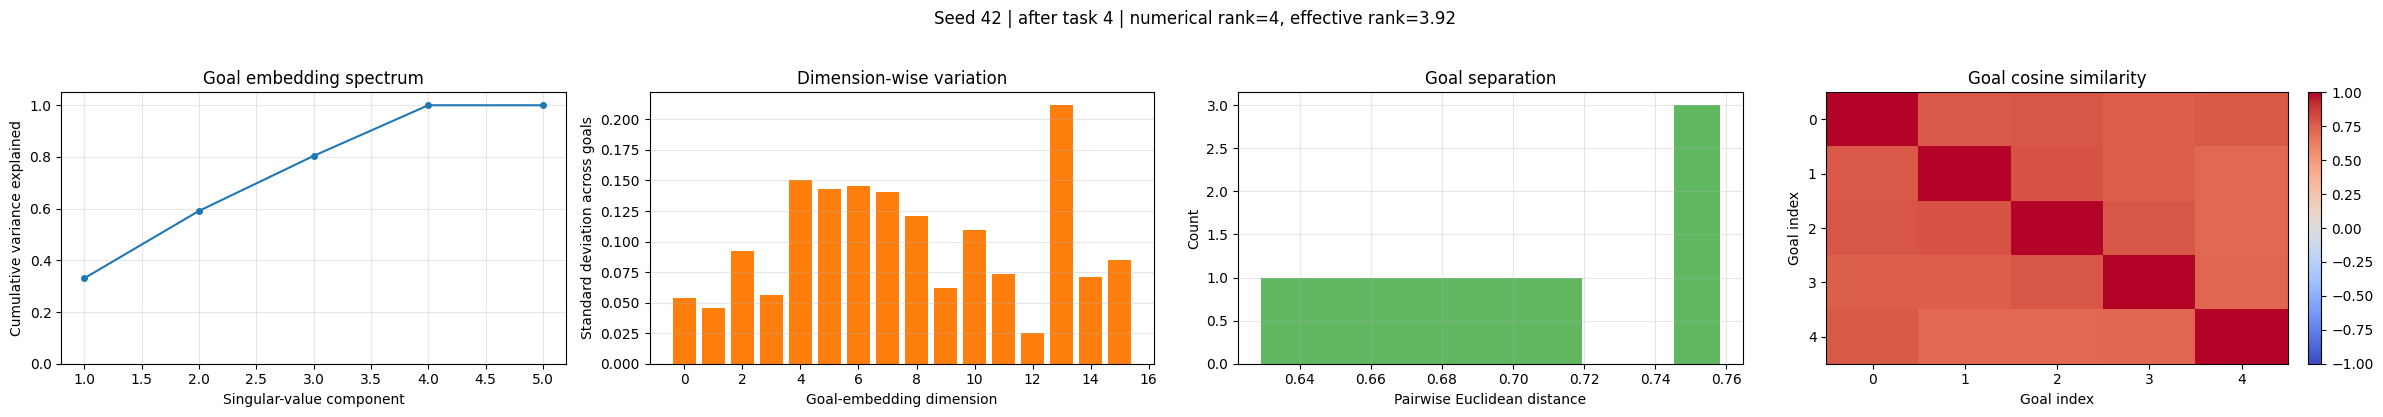

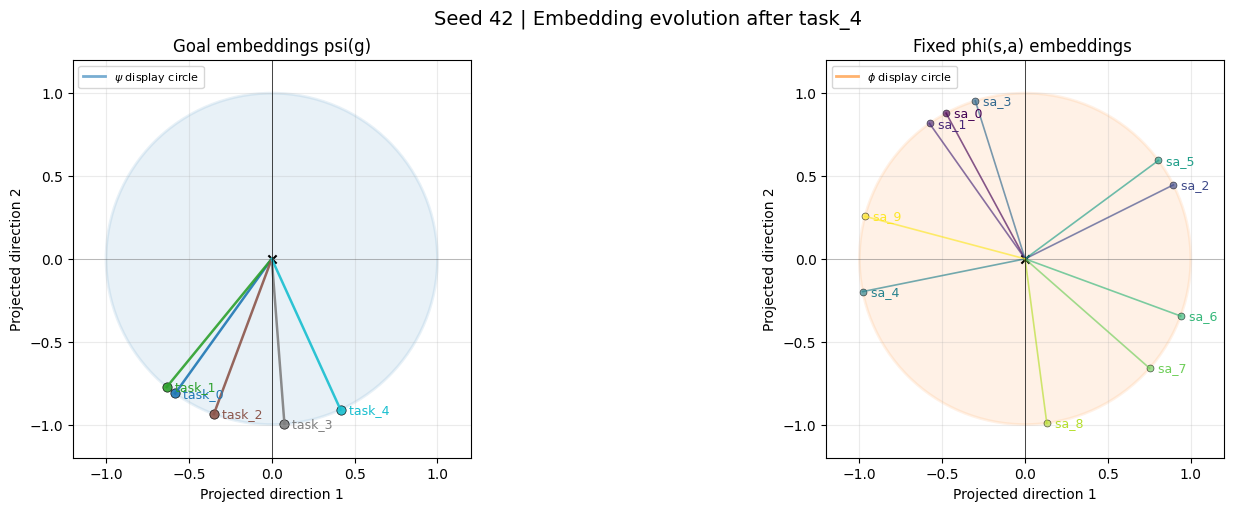


Saved final networks and task memory for seed 42.


In [ ]:
SEEDS = [42]

# Use the same goals across seeds so seed averaging is cleaner.
# GOALS = [(1, 1), (9, 9), (5, 5), (1, 9), (9, 1)]
# NUM_GOALS = len(GOALS)
NUM_GOALS = 5

goal_rng = np.random.default_rng(0)

GOALS = sample_goals(
    NUM_GOALS,
    goal_rng,
    cells=free_cells,
)

print("Sampled GOALS:", GOALS)

BUFFER_CAPACITY = 100_000
LR = float(1e-3)

sa_keywords_local = ["sa_encoder"]
goal_keywords_local = ["goal_encoder"]

overall_results = {
    task_idx: {
        "goals_by_seed": {},
        "eval_returns": [],
        "eval_returns_time": [],
        "min_steps": [],
        "min_time": [],
        "task_embeddings": [],
        "sa_embeddings": [],
        "sa_fixed_probe_embeddings": [],
        "sa_batches_final": [],
        "sa_weight_change": [],
        "goal_weight_change": [],
        "goal_encoder_analysis": [],
    }
    for task_idx in range(NUM_GOALS)
}

goals_by_seed = {}
final_q_networks = {}
final_q_target_networks = {}
weight_history_by_seed = {}
seed_task_memories = {}
seed_retrieval_histories = {}

free_cells = get_free_cells(MAZE_LAYOUT)


def encode_raw_phi_from_tensors(
    q_network,
    obs,
    actions,
    num_actions,
):
    action_onehot = F.one_hot(
        actions.long(),
        num_classes=num_actions,
    ).to(
        dtype=obs.dtype,
        device=obs.device,
    )

    sa_input = torch.cat([obs, action_onehot], dim=-1)

    return q_network.sa_encoder(sa_input)


for seed in SEEDS:
    print(f"\n================ SEED {seed} ================\n")

    set_seed(seed)

    # Use exactly the same goals for every seed.
    goals_by_seed[seed] = list(GOALS)

    for task_idx, goal in enumerate(GOALS):
        overall_results[task_idx]["goals_by_seed"][seed] = goal

    print(f"Sampled GOALS for seed {seed}: {GOALS}")

    # ---------------------------------------------------------
    # Environment and network initialisation
    # ---------------------------------------------------------

    env_tmp = make_env(goal=GOALS[0])

    obs_dim = env_tmp.observation_space.shape[0]
    num_actions = env_tmp.action_space.n

    env_tmp.close()

    q_net_base = FactorisedDQN_QNetwork_BallNorm(
        obs_dim=obs_dim,
        num_actions=num_actions,
        goal_dim=2,
        hidden_dim=64,
        rep_dim=16,
        phi_max_norm=1.0,
        psi_max_norm=1.0,
    ).to(DEVICE)

    q_target_base = FactorisedDQN_QNetwork_BallNorm(
        obs_dim=obs_dim,
        num_actions=num_actions,
        goal_dim=2,
        hidden_dim=64,
        rep_dim=16,
        phi_max_norm=1.0,
        psi_max_norm=1.0,
    ).to(DEVICE)

    q_target_base.load_state_dict(q_net_base.state_dict())

    for parameter in q_net_base.parameters():
        parameter.requires_grad_(True)

    for parameter in q_target_base.parameters():
        parameter.requires_grad_(False)

    # ---------------------------------------------------------
    # Fixed state-action probes for visualisation
    # ---------------------------------------------------------

    probe_env = make_env(goal=GOALS[0])

    fixed_probe_states = []
    fixed_probe_actions = []

    for probe_idx in range(10):
        obs, _ = probe_env.reset(
            seed=seed + 10_000 + probe_idx
        )

        action = probe_idx % num_actions

        fixed_probe_states.append(
            np.asarray(obs, dtype=np.float32)
        )

        fixed_probe_actions.append(action)

    probe_env.close()

    fixed_probe_obs = torch.as_tensor(
        np.asarray(fixed_probe_states, dtype=np.float32),
        dtype=torch.float32,
        device=DEVICE,
    )

    fixed_probe_actions = torch.as_tensor(
        np.asarray(fixed_probe_actions, dtype=np.int64),
        dtype=torch.long,
        device=DEVICE,
    )

    # ---------------------------------------------------------
    # Persistent task memory across tasks in this seed
    # ---------------------------------------------------------

    task_embedding_memory = {}
    replay_task_buffers = {}
    task_goals = {}
    weight_history = []
    logical_buffers = {}   # buffer_id -> TrajectoryReplayBufferDiscrete
    task_to_buf = {} 

    # =========================================================
    # Sequential task training
    # =========================================================

    for task_idx, goal in enumerate(GOALS):
        task_label = f"task_{task_idx}"

        goal = np.asarray(goal, dtype=np.float32)
        task_goals[task_idx] = goal.copy()

        print(
            f"\n----- seed={seed}, "
            f"task_idx={task_idx}, "
            f"goal={goal} -----\n"
        )

        # -----------------------------------------------------
        # Ensure current online network is trainable
        # -----------------------------------------------------

        for parameter in q_net_base.parameters():
            parameter.requires_grad_(True)

        # -----------------------------------------------------
        # Record weights before training this task
        # -----------------------------------------------------

        weight_history.append(
            collect_weight_snapshot(
                qnet=q_net_base,
                goal_label=task_label,
                stage_label=f"goal_{task_label}_before_train",
                sa_keywords_local=sa_keywords_local,
                goal_keywords_local=goal_keywords_local,
                max_samples_per_group=40000,
            )
        )

        # -----------------------------------------------------
        # Train the current task
        # -----------------------------------------------------

        (
            q_network,
            q_target_network,
            eval_returns,
            min_steps,
            min_time,
            final_task_embedding,
            sa_embedding_mean,
            sa_embedding_fixed,
            sa_batch_final,
            buffer,
            cosine_matrix
        ) = dqn_train_phi_psi_adjustment(
            seed=seed,
            q_network=q_net_base,
            q_target_network=q_target_base,
            env=make_env(goal=goal),
            buffer_capacity=BUFFER_CAPACITY,
            lr_sa=LR,
            lr_goal_init=LR,
            obs_dim=obs_dim,
            device=DEVICE,
            total_steps=100_000,
            warmup_steps=1_000,
            batch_size=256,
            eval_freq=1000,
            gamma=0.99,
            tau=0.005,
            eps_start=1.0,
            eps_end=0.05,
            eps_decay_steps=60_000,
            train_freq=3,
            goal=goal,
            task_id=task_idx,
            make_env=make_env,
            td_steps=1,
            replay_task_buffers=replay_task_buffers,
            replay_ratio=task_idx + 1,
            replay_tasks_per_batch=None,
            replay_loss_coef=1.0,
            task_goals=task_goals,
            bootstrap_on_truncation=True,
            early_stop_reward=0.99,
            early_stop_patience=3,
            enable_early_stop=True,
            sigreg_coef=0.01,
            sketch_dim=16,
            goal_separation_coef=0.04,
            goal_separation_target_cosine=0.70,
            psi_raw_norm_coef=2e-4,
            phi_raw_norm_coef=2e-4,
        )

        # -----------------------------------------------------
        # Record weights after training this task
        # -----------------------------------------------------

        weight_history.append(
            collect_weight_snapshot(
                qnet=q_network,
                goal_label=goal,
                stage_label=f"{task_idx}_after_train",
                sa_keywords_local=sa_keywords_local,
                goal_keywords_local=goal_keywords_local,
                max_samples_per_group=40000,
            )
        )

        # -----------------------------------------------------
        # Visualise current-task Q-values
        # -----------------------------------------------------

        visualise_q_table(
            goal,
            q_network,
            eval_returns=eval_returns,
            device=DEVICE,
            make_env=make_env,
        )

        # -----------------------------------------------------
        # Visualise current-task state-action embeddings
        # -----------------------------------------------------

        visualise_embeddings(
            goal,
            q_network,
            device=DEVICE,
            make_env=make_env,
        )

        before_snap = weight_history[-2]
        after_snap = weight_history[-1]

        sa_change_stats = compute_weight_change_from_snapshots(
            before_snap,
            after_snap,
            prefix="sa",
        )

        goal_change_stats = compute_weight_change_from_snapshots(
            before_snap,
            after_snap,
            prefix="goal",
        )

        with torch.no_grad():
            raw_psi = q_network.goal_encoder(
                torch.tensor(
                    goal,
                    dtype=torch.float32,
                    device=DEVICE,
                ).unsqueeze(0)
            )

        raw_psi_norms = torch.linalg.vector_norm(
            raw_psi,
            dim=-1,
        )

        print(
            "Raw psi norms:",
            raw_psi_norms.detach().cpu().numpy(),
        )

        print(
            "Raw psi norm mean/std:",
            raw_psi_norms.mean().item(),
            raw_psi_norms.std(unbiased=False).item(),
        )

        # -----------------------------------------------------
        # Analyse all goals seen so far
        # -----------------------------------------------------

        seen_goals = np.asarray(
            GOALS[:task_idx + 1],
            dtype=np.float32,
        )

        seen_goal_tensor = torch.as_tensor(
            seen_goals,
            dtype=torch.float32,
            device=DEVICE,
        )

        seen_goal_ids = [
            f"task_{i}"
            for i in range(task_idx + 1)
        ]

        current_goal_id = f"task_{task_idx}"

        goal_encoder_analysis = analyse_seen_goal_embeddings(
            q_network=q_network,
            seen_goals=seen_goals,
            device=DEVICE,
            goal_labels=seen_goal_ids,
            plot=True,
            title=f"Seed {seed} | after task {task_idx}",
        )

        # -----------------------------------------------------
        # Encode all seen goals and fixed SA probes
        # -----------------------------------------------------

        q_network.eval()

        with torch.no_grad():
            raw_psi_all = q_network.goal_encoder(
                seen_goal_tensor
            )

            raw_phi_probed = encode_raw_phi_from_tensors(
                q_network=q_network,
                obs=fixed_probe_obs,
                actions=fixed_probe_actions,
                num_actions=num_actions,
            )

        # -----------------------------------------------------
        # Plot directly in the notebook
        # -----------------------------------------------------

        plot_embedding_evolution_2d(
            goal_embeddings=raw_psi_all,
            sa_embeddings=raw_phi_probed,
            goal_radius=float(q_network.psi_max_norm),
            sa_radius=float(q_network.phi_max_norm),
            goal_labels=seen_goal_ids,
            title=(
                f"Seed {seed} | "
                f"Embedding evolution after "
                f"{current_goal_id}"
            ),
            display_radius=1.0,
            display_mode="direction",
        )

        # -----------------------------------------------------
        # Store results for sthis task
        # -----------------------------------------------------

        overall_results[task_idx]["eval_returns"].append(
            eval_returns
        )

        overall_results[task_idx]["min_steps"].append(
            min_steps
        )

        overall_results[task_idx]["min_time"].append(
            min_time
        )

        overall_results[task_idx]["task_embeddings"].append(
            raw_psi_all.detach().cpu().numpy()
        )

        overall_results[task_idx]["sa_embeddings"].append(
            sa_embedding_mean
        )

        overall_results[task_idx][
            "sa_fixed_probe_embeddings"
        ].append(
            raw_phi_probed.detach().cpu().numpy()
        )

        overall_results[task_idx]["sa_batches_final"].append(
            sa_batch_final
        )

        overall_results[task_idx]["sa_weight_change"].append(
            sa_change_stats
        )

        overall_results[task_idx]["goal_weight_change"].append(
            goal_change_stats
        )

        overall_results[task_idx][
            "goal_encoder_analysis"
        ].append(
            goal_encoder_analysis
        )

        # -----------------------------------------------------
        # Prepare networks for the next task
        # -----------------------------------------------------

        q_net_base = deepcopy(q_network).train()
        q_target_base = deepcopy(q_target_network).eval()

        for parameter in q_net_base.parameters():
            parameter.requires_grad_(True)

        for parameter in q_target_base.parameters():
            parameter.requires_grad_(False)

        # -----------------------------------------------------
        # Keep this task's replay buffer for future replay
        # -----------------------------------------------------

        trimmed_buffer = keep_last_fraction_of_buffer(
            buffer,
            keep_fraction=0.4,
        )

        if task_idx == 0:
            buf_id = f"buf_{task_idx}"
            logical_buffers[buf_id] = trimmed_buffer
            task_to_buf[task_idx] = buf_id
        else:
            sims = cosine_matrix[task_idx, :task_idx]

            sims_np = sims.detach().cpu().numpy() if hasattr(sims, "cpu") else sims
            i_star = int(np.argmax(sims_np))
            s = float(sims_np[i_star])

            X = 0.8  # your threshold

            if abs(s - 1.0) < 1e-6:
                buf_id = task_to_buf[i_star]

            elif s <= X:
                buf_id = f"buf_{task_idx}"
                logical_buffers[buf_id] = trimmed_buffer
                task_to_buf[task_idx] = buf_id

            else:
                r = (1.0 - s) / (1.0 - X)
                buf_id = task_to_buf[i_star]

                base_buffer = logical_buffers[buf_id]
                merge_fraction_of_buffers(base_buffer, trimmed_buffer, fraction=r)

                task_to_buf[task_idx] = buf_id
                
        for tid in task_to_buf.keys():
            buf_id = task_to_buf[tid]
            replay_task_buffers[tid] = logical_buffers[buf_id]


    # =========================================================
    # Save seed-level objects
    # =========================================================

    final_q_networks[seed] = deepcopy(q_network).eval()

    final_q_target_networks[seed] = deepcopy(
        q_target_network
    ).eval()

    weight_history_by_seed[seed] = deepcopy(weight_history)

    seed_task_memories[seed] = deepcopy(task_embedding_memory)

    seed_retrieval_histories[seed] = []

    print(
        f"\nSaved final networks and task memory for seed {seed}."
    )

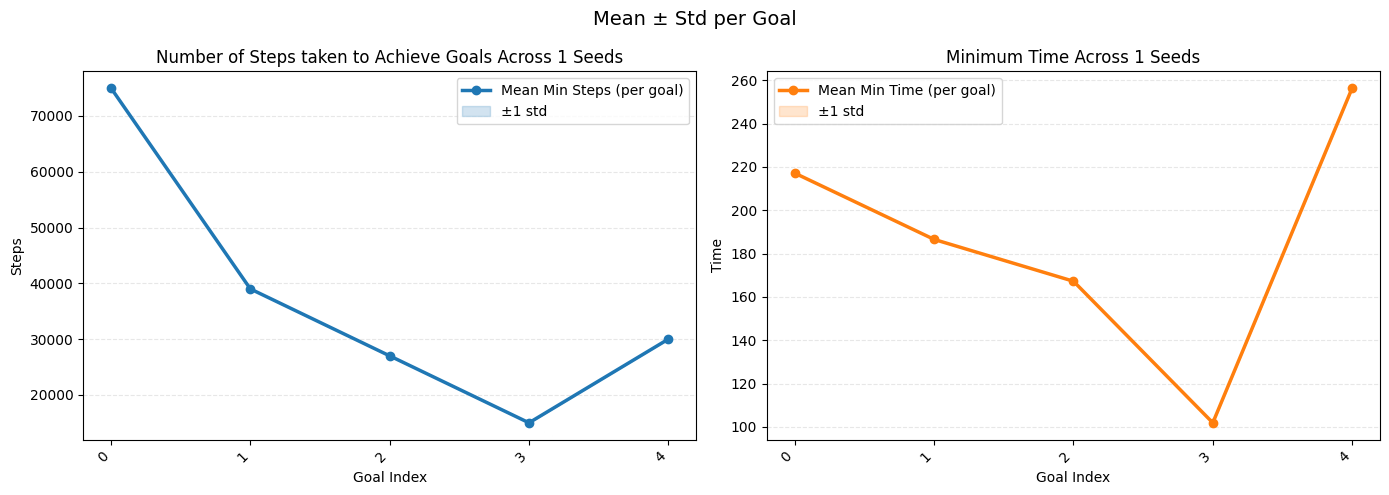

In [7]:
plot_min_steps_and_min_time(overall_results=overall_results, seeds=SEEDS)

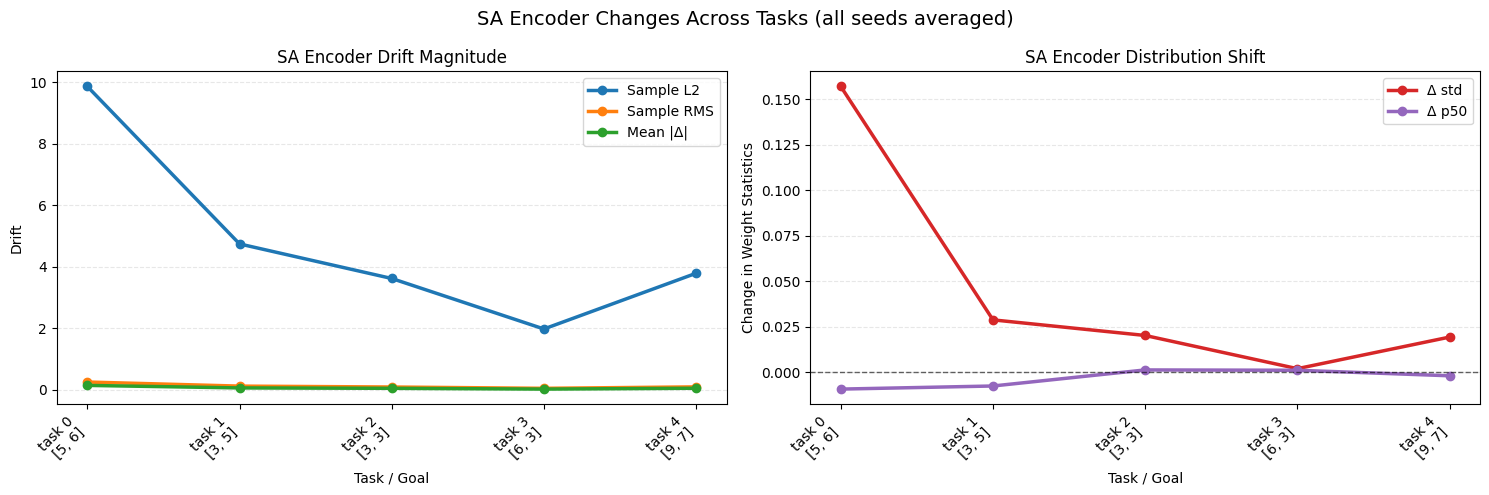

[{'prefix': 'sa', 'num_compared': 1488, 'sample_l2': 3.7880890369415283, 'sample_l1': 79.59288024902344, 'sample_linf': 0.936292290687561, 'sample_mean_abs': 0.05348983779549599, 'sample_rms': 0.09820163249969482, 'stats_delta': {'delta_mean': -0.0026351232081651688, 'delta_std': 0.01931208372116089, 'delta_min': -0.04098057746887207, 'delta_max': 0.35615384578704834, 'delta_p01': -0.021012187004089355, 'delta_p50': -0.0019705910235643387, 'delta_p99': 0.02948784828186035}}]
Per-task buffer sizes: {0: 65640, 1: 65640, 2: 65640, 3: 65640, 4: 65640}
Total: 328200


In [8]:
from utils import plot_sa_encoder_changes_across_tasks

plot_sa_encoder_changes_across_tasks(overall_results=overall_results)
print(overall_results[task_idx]["sa_weight_change"])

sizes = {task_id: len(buf) for task_id, buf in replay_task_buffers.items()}
print("Per-task buffer sizes:", sizes)
print("Total:", sum(sizes.values()))

In [9]:

def evaluate_zero_shot_goal(
    q_network,
    goal,
    make_env,
    device,
    episodes=8,
):
    q_network.eval()

    eval_env = make_env(goal=goal)

    goal_arr = np.asarray(
        goal,
        dtype=np.float32,
    )

    goal_t = torch.tensor(
        goal_arr,
        dtype=torch.float32,
        device=device,
    ).unsqueeze(0)

    def eval_policy(obs):
        obs_t = torch.tensor(
            obs,
            dtype=torch.float32,
            device=device,
        ).unsqueeze(0)

        with torch.inference_mode():
            q_values = q_network.q_val_for_argmax_action(
                obs_t,
                goal_t,
            )

        return int(
            q_values.argmax(
                dim=-1,
            ).item()
        )

    mean_return, mean_length = evaluate_policy(
        eval_env,
        eval_policy,
        episodes=episodes,
    )

    eval_env.close()

    return mean_return, mean_length


# Check that seed-specific goals were saved
if "goals_by_seed" not in globals():
    raise RuntimeError(
        "goals_by_seed does not exist. "
        "Add goals_by_seed = {} before the training loop and "
        "goals_by_seed[seed] = list(GOALS) after sampling goals."
    )


# Store zero-shot results using task_idx rather than goal coordinates
zero_shot_returns = {
    seed: {
        task_idx: None
        for task_idx in range(NUM_GOALS)
    }
    for seed in SEEDS
}

zero_shot_lengths = {
    seed: {
        task_idx: None
        for task_idx in range(NUM_GOALS)
    }
    for seed in SEEDS
}


# Evaluate each final network on the goals sampled for its own seed
for seed in SEEDS:
    print(
        f"\n========== ZERO-SHOT EVALUATION "
        f"SEED {seed} ==========\n"
    )

    q_final = final_q_networks[seed]

    # These are the goals generated for this particular seed
    seed_goals = goals_by_seed[seed]

    if len(seed_goals) != NUM_GOALS:
        raise ValueError(
            f"Seed {seed} has {len(seed_goals)} goals, "
            f"but NUM_GOALS={NUM_GOALS}."
        )

    for task_idx, test_goal in enumerate(seed_goals):
        mean_return, mean_length = evaluate_zero_shot_goal(
            q_network=q_final,
            goal=test_goal,
            make_env=make_env,
            device=DEVICE,
            episodes=8,
        )

        zero_shot_returns[seed][task_idx] = mean_return
        zero_shot_lengths[seed][task_idx] = mean_length

        print(
            f"task_idx={task_idx} | "
            f"goal={test_goal} | "
            f"return={mean_return:.3f} | "
            f"length={mean_length:.1f}"
        )


# Aggregate zero-shot results across seeds by task index
zero_shot_return_mean = {}
zero_shot_return_std = {}
zero_shot_length_mean = {}
zero_shot_length_std = {}

for task_idx in range(NUM_GOALS):
    return_values = [
        zero_shot_returns[seed][task_idx]
        for seed in SEEDS
    ]

    length_values = [
        zero_shot_lengths[seed][task_idx]
        for seed in SEEDS
    ]

    zero_shot_return_mean[task_idx] = float(
        np.mean(return_values)
    )

    zero_shot_return_std[task_idx] = float(
        np.std(return_values)
    )

    zero_shot_length_mean[task_idx] = float(
        np.mean(length_values)
    )

    zero_shot_length_std[task_idx] = float(
        np.std(length_values)
    )


# Print final task-index-based results
print(
    "\n========== FINAL ZERO-SHOT RESULTS "
    "BY TASK INDEX ==========\n"
)

for task_idx in range(NUM_GOALS):
    print(
        f"task_idx={task_idx} | "
        f"return="
        f"{zero_shot_return_mean[task_idx]:.3f} "
        f"+/- "
        f"{zero_shot_return_std[task_idx]:.3f} | "
        f"length="
        f"{zero_shot_length_mean[task_idx]:.1f} "
        f"+/- "
        f"{zero_shot_length_std[task_idx]:.1f}"
    )


# Optional diagnostic: show which physical goal each task_idx represented
print(
    "\n========== TASK INDEX TO GOAL MAPPING ==========\n"
)

for task_idx in range(NUM_GOALS):
    task_goal_mapping = {
        seed: goals_by_seed[seed][task_idx]
        for seed in SEEDS
    }

    print(
        f"task_idx={task_idx} | "
        f"goals_by_seed={task_goal_mapping}"
    )


========== ZERO-SHOT EVALUATION SEED 42 ==========

task_idx=0 | goal=(5, 6) | return=-3.050 | length=51.9
task_idx=1 | goal=(3, 5) | return=0.875 | length=18.1
task_idx=2 | goal=(3, 3) | return=0.250 | length=76.5
task_idx=3 | goal=(6, 3) | return=0.750 | length=30.0
task_idx=4 | goal=(9, 7) | return=1.000 | length=8.4

========== FINAL ZERO-SHOT RESULTS BY TASK INDEX ==========

task_idx=0 | return=-3.050 +/- 0.000 | length=51.9 +/- 0.0
task_idx=1 | return=0.875 +/- 0.000 | length=18.1 +/- 0.0
task_idx=2 | return=0.250 +/- 0.000 | length=76.5 +/- 0.0
task_idx=3 | return=0.750 +/- 0.000 | length=30.0 +/- 0.0
task_idx=4 | return=1.000 +/- 0.000 | length=8.4 +/- 0.0

========== TASK INDEX TO GOAL MAPPING ==========

task_idx=0 | goals_by_seed={42: (5, 6)}
task_idx=1 | goals_by_seed={42: (3, 5)}
task_idx=2 | goals_by_seed={42: (3, 3)}
task_idx=3 | goals_by_seed={42: (6, 3)}
task_idx=4 | goals_by_seed={42: (9, 7)}



========== CONTINUAL LEARNING METRICS BY TASK INDEX ==========

Task 0 | initial=1.000 +/- 0.000 | final zero-shot=-3.050 +/- 0.000 | forgetting=4.050 +/- 0.000 | BWT=-4.050 +/- 0.000 | retention=-3.050 +/- 0.000
Task 1 | initial=1.000 +/- 0.000 | final zero-shot=0.875 +/- 0.000 | forgetting=0.125 +/- 0.000 | BWT=-0.125 +/- 0.000 | retention=0.875 +/- 0.000
Task 2 | initial=1.000 +/- 0.000 | final zero-shot=0.250 +/- 0.000 | forgetting=0.750 +/- 0.000 | BWT=-0.750 +/- 0.000 | retention=0.250 +/- 0.000
Task 3 | initial=1.000 +/- 0.000 | final zero-shot=0.750 +/- 0.000 | forgetting=0.250 +/- 0.000 | BWT=-0.250 +/- 0.000 | retention=0.750 +/- 0.000
Task 4 | initial=1.000 +/- 0.000 | final zero-shot=1.000 +/- 0.000 | forgetting=0.000 +/- 0.000 | BWT=0.000 +/- 0.000 | retention=1.000 +/- 0.000

========== OVERALL METRICS ==========

Mean initial return: 1.000
Mean final zero-shot return: -0.035
Mean forgetting: 1.035
Mean backward transfer: -1.035
Mean retention: -0.035


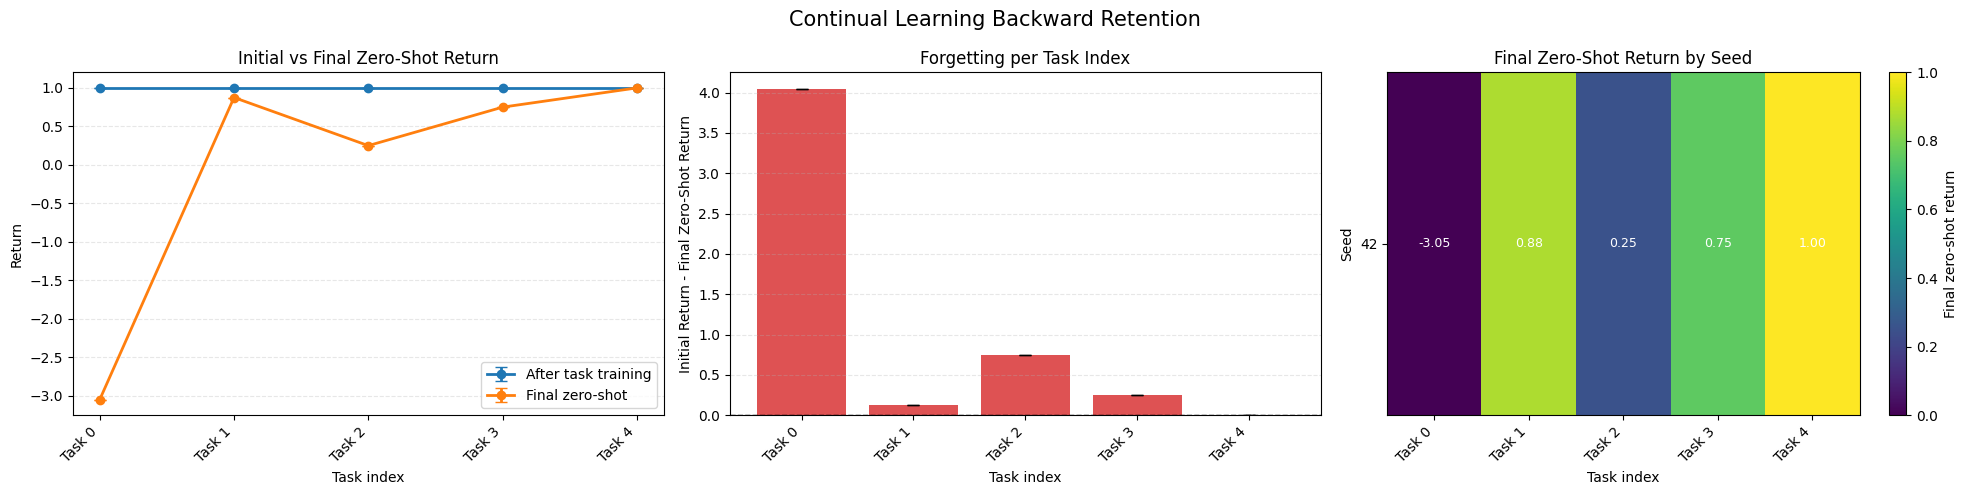

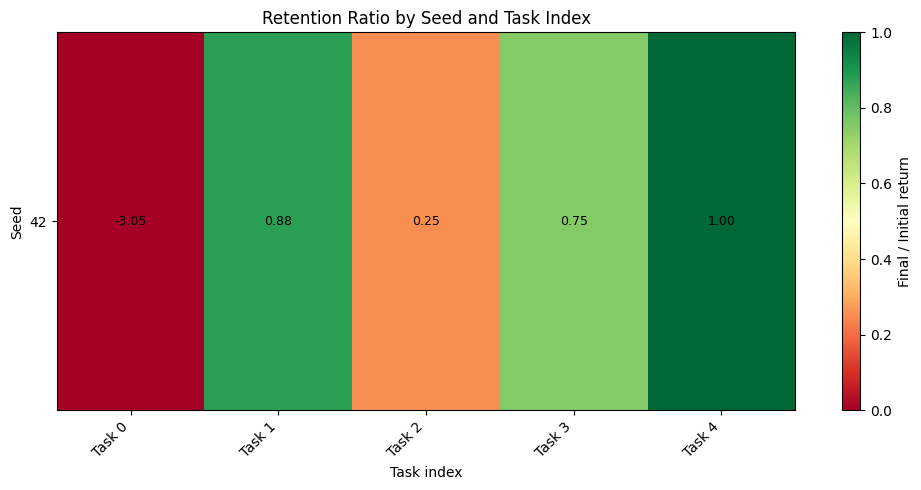

In [10]:
def extract_initial_return(eval_history):
    if len(eval_history) == 0:
        return np.nan

    last_entry = eval_history[-1]

    if isinstance(
        last_entry,
        (tuple, list, np.ndarray),
    ):
        return float(last_entry[1])

    return float(last_entry)


num_seeds = len(SEEDS)
num_tasks = NUM_GOALS


# ------------------------------------------------------------
# Allocate matrices
# Rows    = seeds
# Columns = task indices
# ------------------------------------------------------------
initial_matrix = np.full(
    (num_seeds, num_tasks),
    np.nan,
    dtype=np.float32,
)

final_zero_shot_matrix = np.full(
    (num_seeds, num_tasks),
    np.nan,
    dtype=np.float32,
)


# ------------------------------------------------------------
# Fill initial and final zero-shot matrices
# ------------------------------------------------------------
for seed_idx, seed in enumerate(SEEDS):
    for task_idx in range(num_tasks):

        # Initial return after training this task.
        # Results were appended in SEEDS order during training.
        eval_history = (
            overall_results[task_idx][
                "eval_returns"
            ][seed_idx]
        )

        initial_matrix[
            seed_idx,
            task_idx,
        ] = extract_initial_return(
            eval_history
        )

        # Final zero-shot return for this seed/task pair
        final_zero_shot_matrix[
            seed_idx,
            task_idx,
        ] = zero_shot_returns[
            seed
        ][
            task_idx
        ]


# ------------------------------------------------------------
# Continual-learning metrics
# ------------------------------------------------------------
forgetting_matrix = (
    initial_matrix
    - final_zero_shot_matrix
)

backward_transfer_matrix = (
    final_zero_shot_matrix
    - initial_matrix
)


# Use a safe division operation for retention.
# This avoids division by zero when the initial return is zero.
retention_matrix = np.divide(
    final_zero_shot_matrix,
    initial_matrix,
    out=np.full_like(
        final_zero_shot_matrix,
        np.nan,
    ),
    where=np.abs(initial_matrix) > 1e-8,
)


# ------------------------------------------------------------
# Aggregate metrics across seeds
# ------------------------------------------------------------
initial_mean = np.nanmean(
    initial_matrix,
    axis=0,
)

initial_std = np.nanstd(
    initial_matrix,
    axis=0,
)

final_mean = np.nanmean(
    final_zero_shot_matrix,
    axis=0,
)

final_std = np.nanstd(
    final_zero_shot_matrix,
    axis=0,
)

forgetting_mean = np.nanmean(
    forgetting_matrix,
    axis=0,
)

forgetting_std = np.nanstd(
    forgetting_matrix,
    axis=0,
)

bwt_mean = np.nanmean(
    backward_transfer_matrix,
    axis=0,
)

bwt_std = np.nanstd(
    backward_transfer_matrix,
    axis=0,
)

retention_mean = np.nanmean(
    retention_matrix,
    axis=0,
)

retention_std = np.nanstd(
    retention_matrix,
    axis=0,
)


# ------------------------------------------------------------
# Print per-task metrics
# ------------------------------------------------------------
print(
    "\n========== CONTINUAL LEARNING METRICS "
    "BY TASK INDEX ==========\n"
)

for task_idx in range(num_tasks):
    print(
        f"Task {task_idx} | "
        f"initial="
        f"{initial_mean[task_idx]:.3f} "
        f"+/- "
        f"{initial_std[task_idx]:.3f} | "
        f"final zero-shot="
        f"{final_mean[task_idx]:.3f} "
        f"+/- "
        f"{final_std[task_idx]:.3f} | "
        f"forgetting="
        f"{forgetting_mean[task_idx]:.3f} "
        f"+/- "
        f"{forgetting_std[task_idx]:.3f} | "
        f"BWT="
        f"{bwt_mean[task_idx]:.3f} "
        f"+/- "
        f"{bwt_std[task_idx]:.3f} | "
        f"retention="
        f"{retention_mean[task_idx]:.3f} "
        f"+/- "
        f"{retention_std[task_idx]:.3f}"
    )


# ------------------------------------------------------------
# Print overall metrics
# ------------------------------------------------------------
print(
    "\n========== OVERALL METRICS ==========\n"
)

print(
    f"Mean initial return: "
    f"{np.nanmean(initial_matrix):.3f}"
)

print(
    f"Mean final zero-shot return: "
    f"{np.nanmean(final_zero_shot_matrix):.3f}"
)

print(
    f"Mean forgetting: "
    f"{np.nanmean(forgetting_matrix):.3f}"
)

print(
    f"Mean backward transfer: "
    f"{np.nanmean(backward_transfer_matrix):.3f}"
)

print(
    f"Mean retention: "
    f"{np.nanmean(retention_matrix):.3f}"
)


# ------------------------------------------------------------
# Plot labels
# ------------------------------------------------------------
task_labels = [
    f"Task {task_idx}"
    for task_idx in range(num_tasks)
]

seed_labels = [
    str(seed)
    for seed in SEEDS
]

x = np.arange(num_tasks)


# ------------------------------------------------------------
# Main plots
# ------------------------------------------------------------
fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 5),
)


# ------------------------------------------------------------
# Initial versus final zero-shot return
# ------------------------------------------------------------
axes[0].errorbar(
    x,
    initial_mean,
    yerr=initial_std,
    marker="o",
    linewidth=2,
    capsize=4,
    label="After task training",
)

axes[0].errorbar(
    x,
    final_mean,
    yerr=final_std,
    marker="o",
    linewidth=2,
    capsize=4,
    label="Final zero-shot",
)

axes[0].set_title(
    "Initial vs Final Zero-Shot Return"
)

axes[0].set_xlabel(
    "Task index"
)

axes[0].set_ylabel(
    "Return"
)

axes[0].set_xticks(x)

axes[0].set_xticklabels(
    task_labels,
    rotation=45,
    ha="right",
)

axes[0].grid(
    True,
    axis="y",
    linestyle="--",
    alpha=0.3,
)

axes[0].legend()


# ------------------------------------------------------------
# Forgetting
# ------------------------------------------------------------
forgetting_colors = [
    "tab:red" if value > 0 else "tab:green"
    for value in forgetting_mean
]

axes[1].bar(
    x,
    forgetting_mean,
    yerr=forgetting_std,
    color=forgetting_colors,
    alpha=0.8,
    capsize=4,
)

axes[1].axhline(
    0.0,
    color="black",
    linestyle="--",
    linewidth=1,
)

axes[1].set_title(
    "Forgetting per Task Index"
)

axes[1].set_xlabel(
    "Task index"
)

axes[1].set_ylabel(
    "Initial Return - Final Zero-Shot Return"
)

axes[1].set_xticks(x)

axes[1].set_xticklabels(
    task_labels,
    rotation=45,
    ha="right",
)

axes[1].grid(
    True,
    axis="y",
    linestyle="--",
    alpha=0.3,
)


# ------------------------------------------------------------
# Final zero-shot heatmap across seeds
# ------------------------------------------------------------
im = axes[2].imshow(
    final_zero_shot_matrix,
    aspect="auto",
    cmap="viridis",
    vmin=0.0,
    vmax=1.0,
)

axes[2].set_title(
    "Final Zero-Shot Return by Seed"
)

axes[2].set_xlabel(
    "Task index"
)

axes[2].set_ylabel(
    "Seed"
)

axes[2].set_xticks(
    np.arange(num_tasks)
)

axes[2].set_xticklabels(
    task_labels,
    rotation=45,
    ha="right",
)

axes[2].set_yticks(
    np.arange(num_seeds)
)

axes[2].set_yticklabels(
    seed_labels
)


for seed_idx in range(num_seeds):
    for task_idx in range(num_tasks):
        value = final_zero_shot_matrix[
            seed_idx,
            task_idx,
        ]

        if np.isnan(value):
            text_value = "nan"
        else:
            text_value = f"{value:.2f}"

        axes[2].text(
            task_idx,
            seed_idx,
            text_value,
            ha="center",
            va="center",
            color="white",
            fontsize=9,
        )


fig.colorbar(
    im,
    ax=axes[2],
    label="Final zero-shot return",
)


fig.suptitle(
    "Continual Learning Backward Retention",
    fontsize=15,
)

fig.tight_layout()

plt.show()


# ------------------------------------------------------------
# Separate retention heatmap
# ------------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(10, 5),
)


# Clip only for visualisation
retention_plot = np.clip(
    retention_matrix,
    0.0,
    1.0,
)


im = ax.imshow(
    retention_plot,
    aspect="auto",
    cmap="RdYlGn",
    vmin=0.0,
    vmax=1.0,
)

ax.set_title(
    "Retention Ratio by Seed and Task Index"
)

ax.set_xlabel(
    "Task index"
)

ax.set_ylabel(
    "Seed"
)

ax.set_xticks(
    np.arange(num_tasks)
)

ax.set_xticklabels(
    task_labels,
    rotation=45,
    ha="right",
)

ax.set_yticks(
    np.arange(num_seeds)
)

ax.set_yticklabels(
    seed_labels
)


for seed_idx in range(num_seeds):
    for task_idx in range(num_tasks):
        value = retention_matrix[
            seed_idx,
            task_idx,
        ]

        if np.isnan(value):
            text_value = "nan"
        else:
            text_value = f"{value:.2f}"

        ax.text(
            task_idx,
            seed_idx,
            text_value,
            ha="center",
            va="center",
            color="black",
            fontsize=9,
        )


fig.colorbar(
    im,
    ax=ax,
    label="Final / Initial return",
)

fig.tight_layout()

plt.show()

Episode 1: 4 steps | return: 1.00 | reached goal: True
Episode 2: 10 steps | return: 1.00 | reached goal: True
Episode 3: 100 steps | return: -9.80 | reached goal: False
Episode 4: 2 steps | return: 1.00 | reached goal: True
Episode 5: 100 steps | return: -9.90 | reached goal: False
Episode 6: 7 steps | return: 1.00 | reached goal: True
Episode 7: 4 steps | return: 1.00 | reached goal: True
Episode 8: 100 steps | return: -9.30 | reached goal: False

Success rate: 62.50% over 8 episodes
Average return: -3.00 ± 5.17


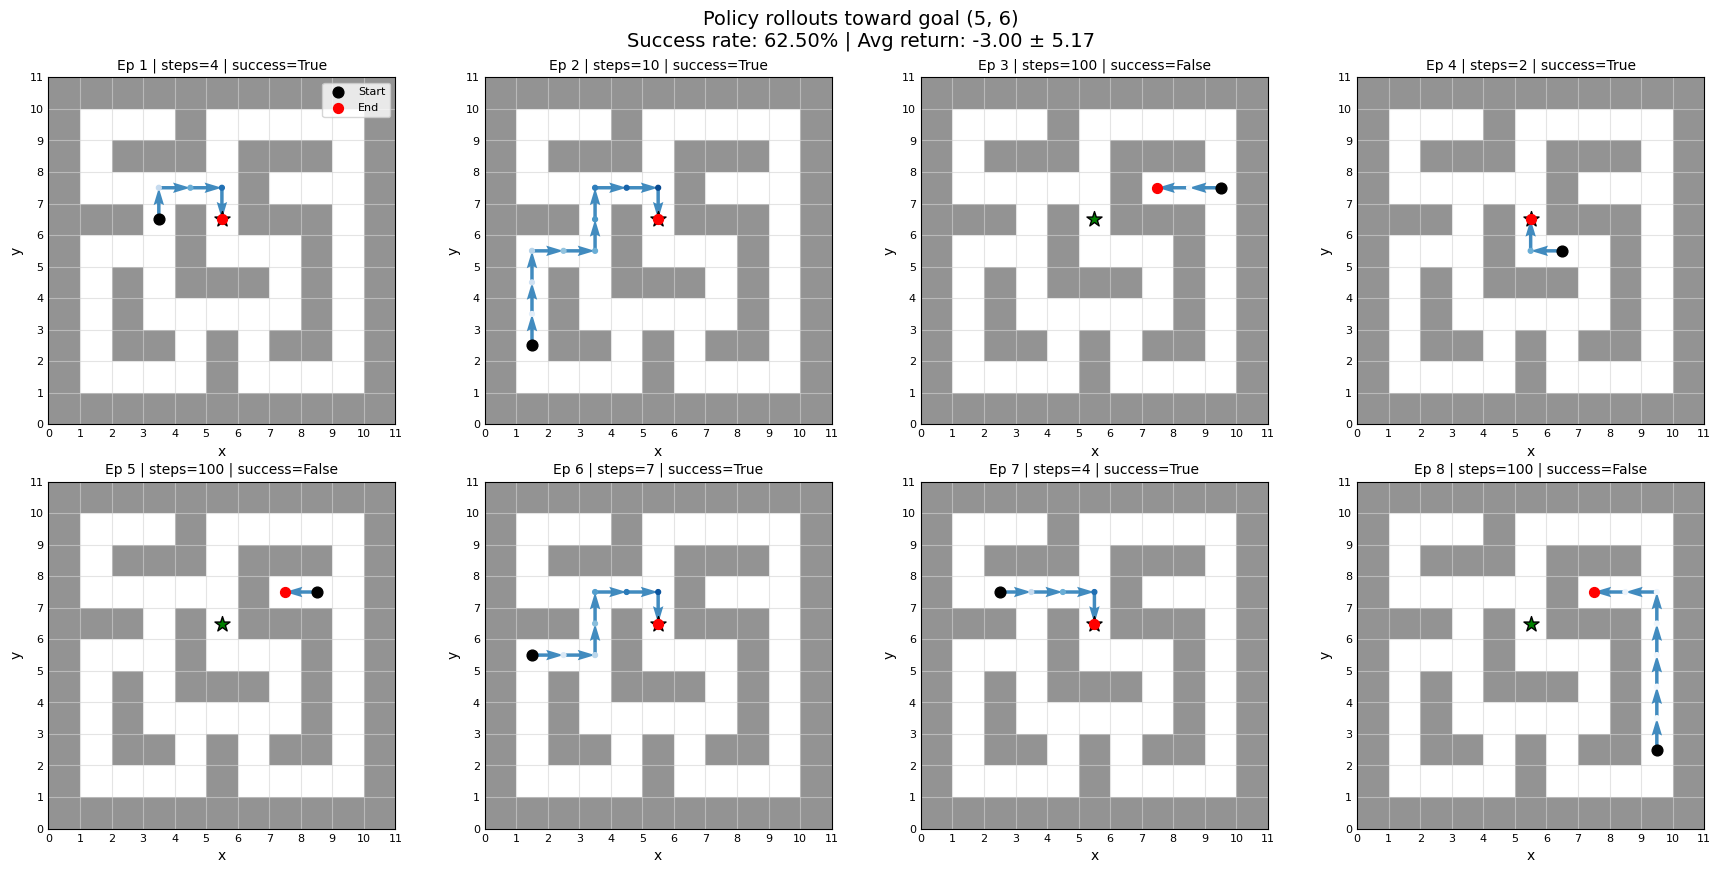

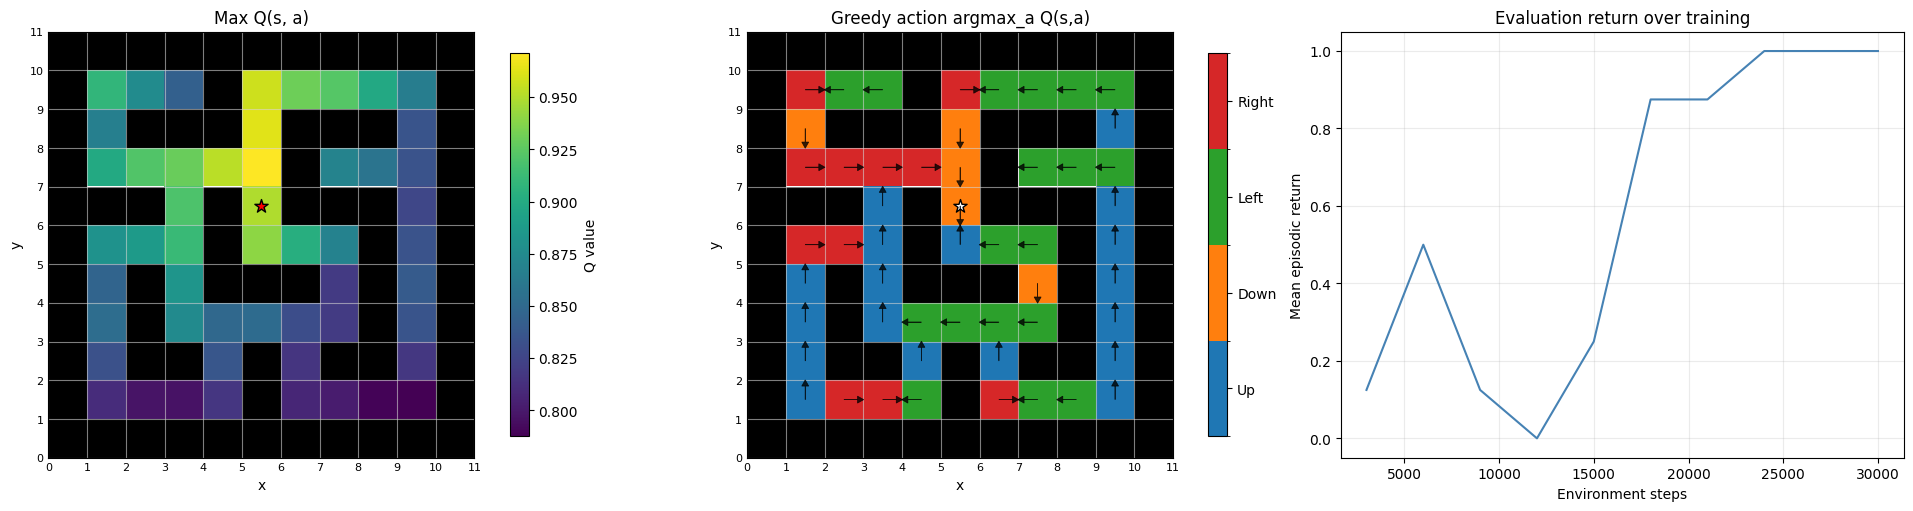

Episode 1: 3 steps | return: 1.00 | reached goal: True
Episode 2: 16 steps | return: 1.00 | reached goal: True
Episode 3: 4 steps | return: 1.00 | reached goal: True
Episode 4: 1 steps | return: 1.00 | reached goal: True
Episode 5: 10 steps | return: 1.00 | reached goal: True
Episode 6: 2 steps | return: 1.00 | reached goal: True
Episode 7: 8 steps | return: 1.00 | reached goal: True
Episode 8: 3 steps | return: 1.00 | reached goal: True

Success rate: 100.00% over 8 episodes
Average return: 1.00 ± 0.00


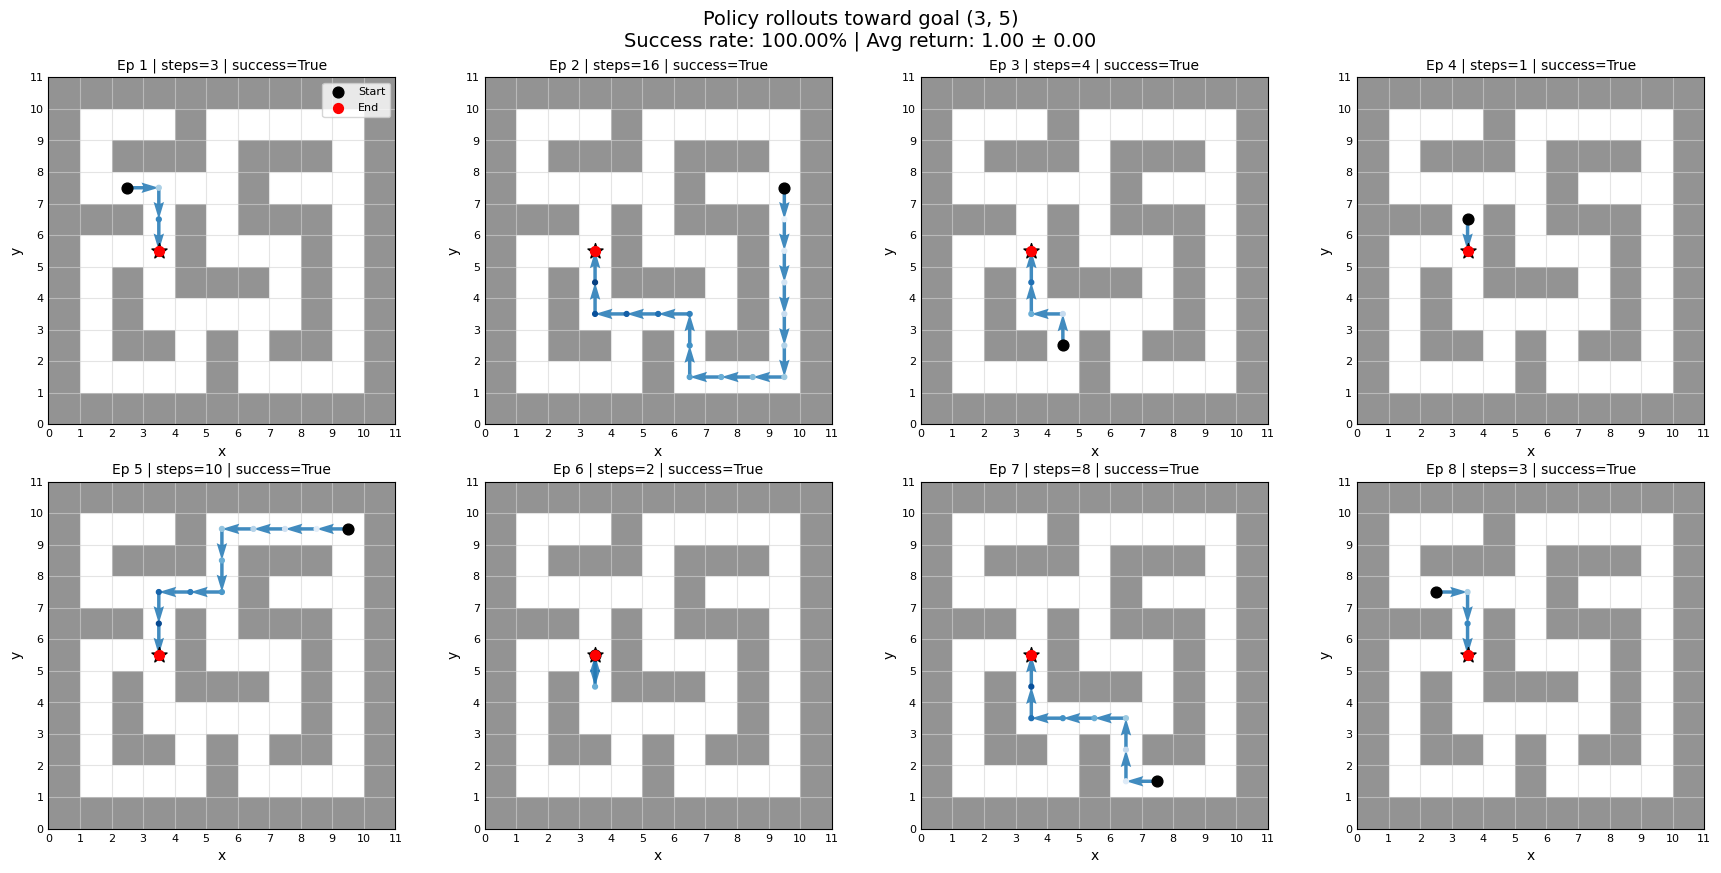

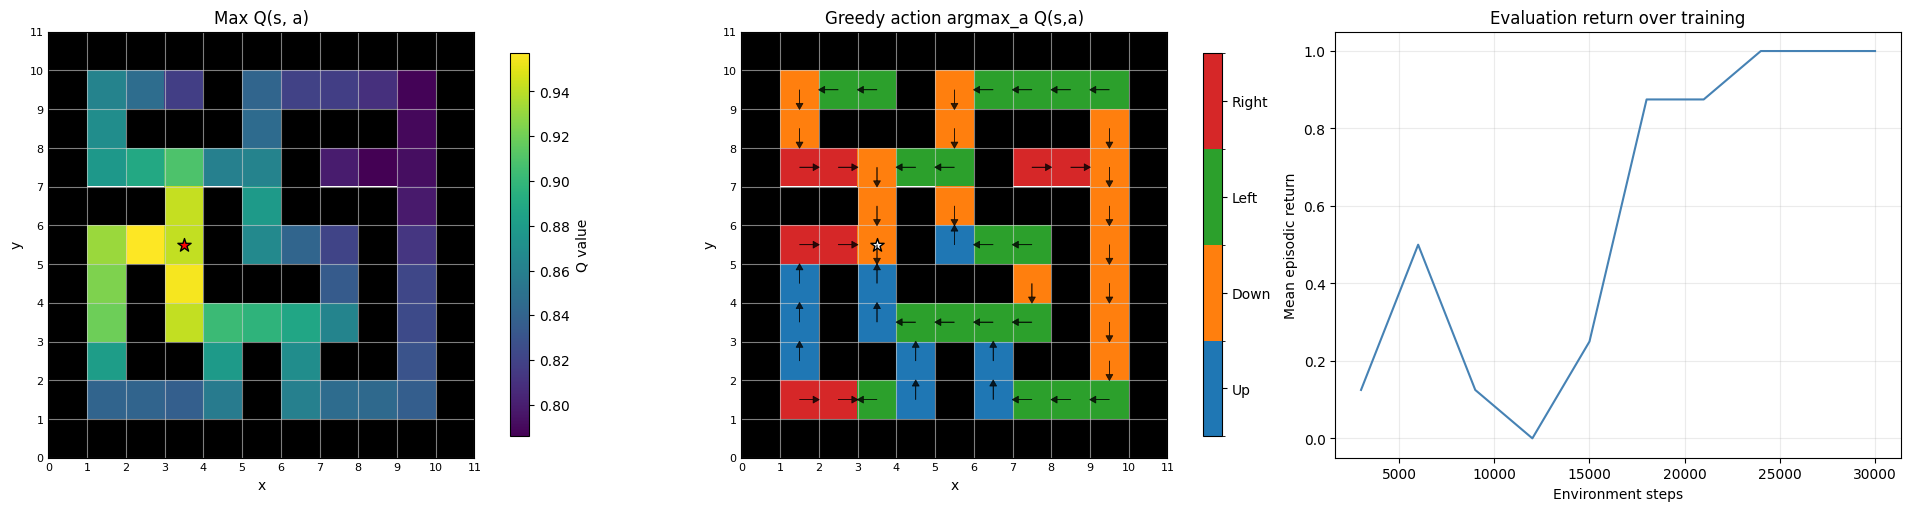

Episode 1: 100 steps | return: 0.00 | reached goal: False
Episode 2: 100 steps | return: 0.00 | reached goal: False
Episode 3: 2 steps | return: 1.00 | reached goal: True
Episode 4: 4 steps | return: 1.00 | reached goal: True
Episode 5: 6 steps | return: 1.00 | reached goal: True
Episode 6: 3 steps | return: 1.00 | reached goal: True
Episode 7: 100 steps | return: 0.00 | reached goal: False
Episode 8: 100 steps | return: 0.00 | reached goal: False

Success rate: 50.00% over 8 episodes
Average return: 0.50 ± 0.50


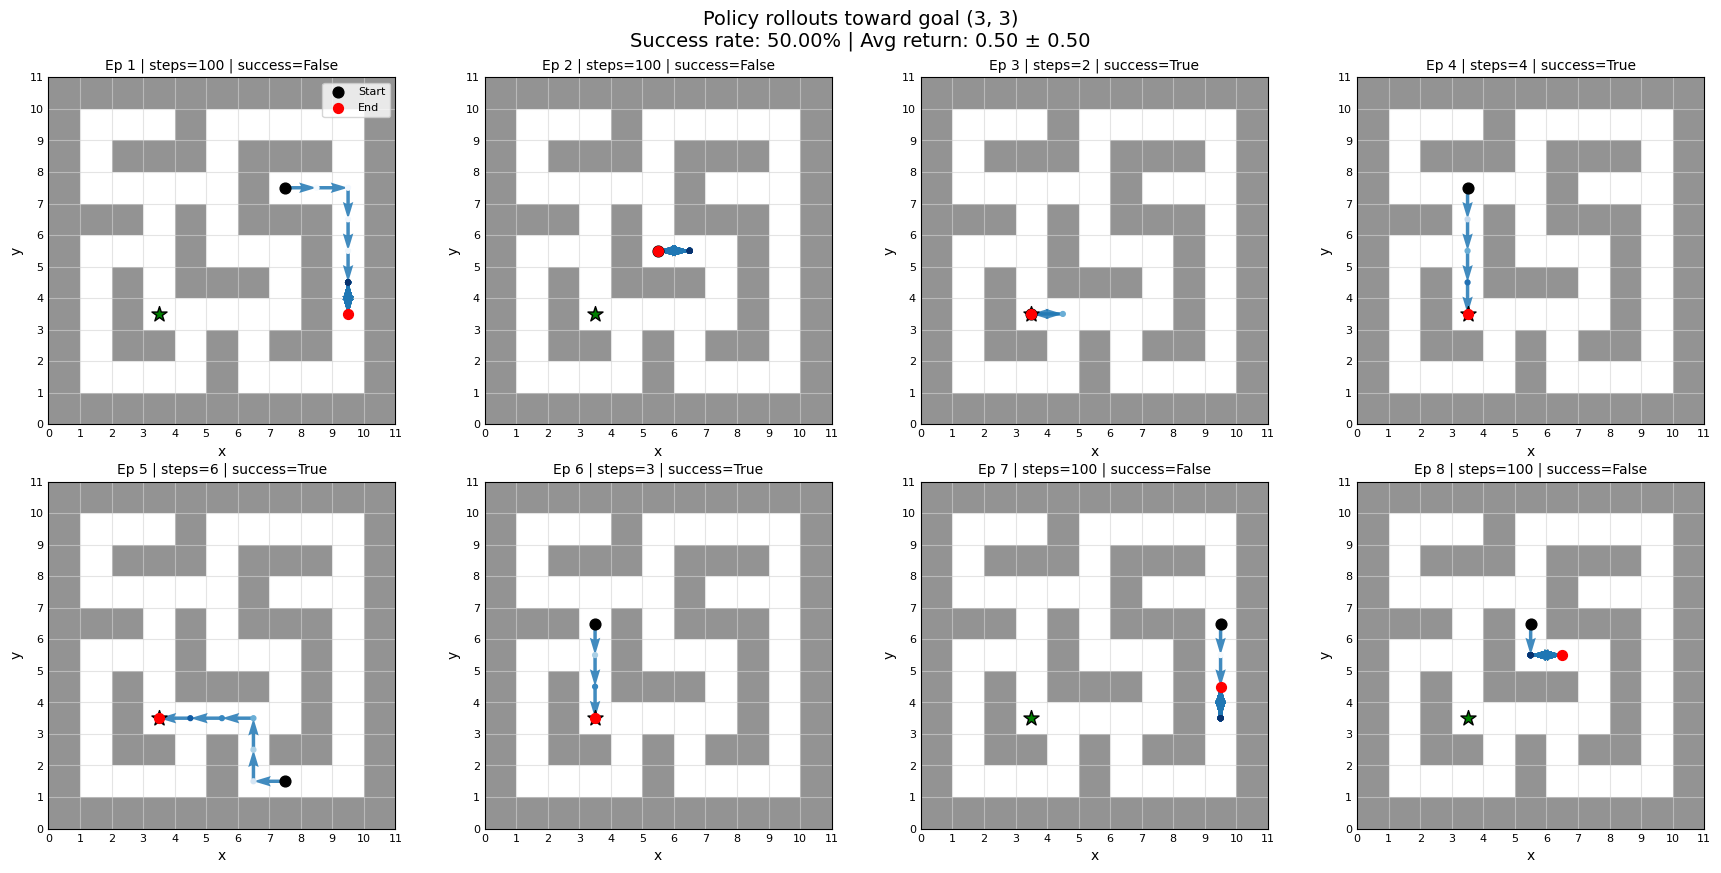

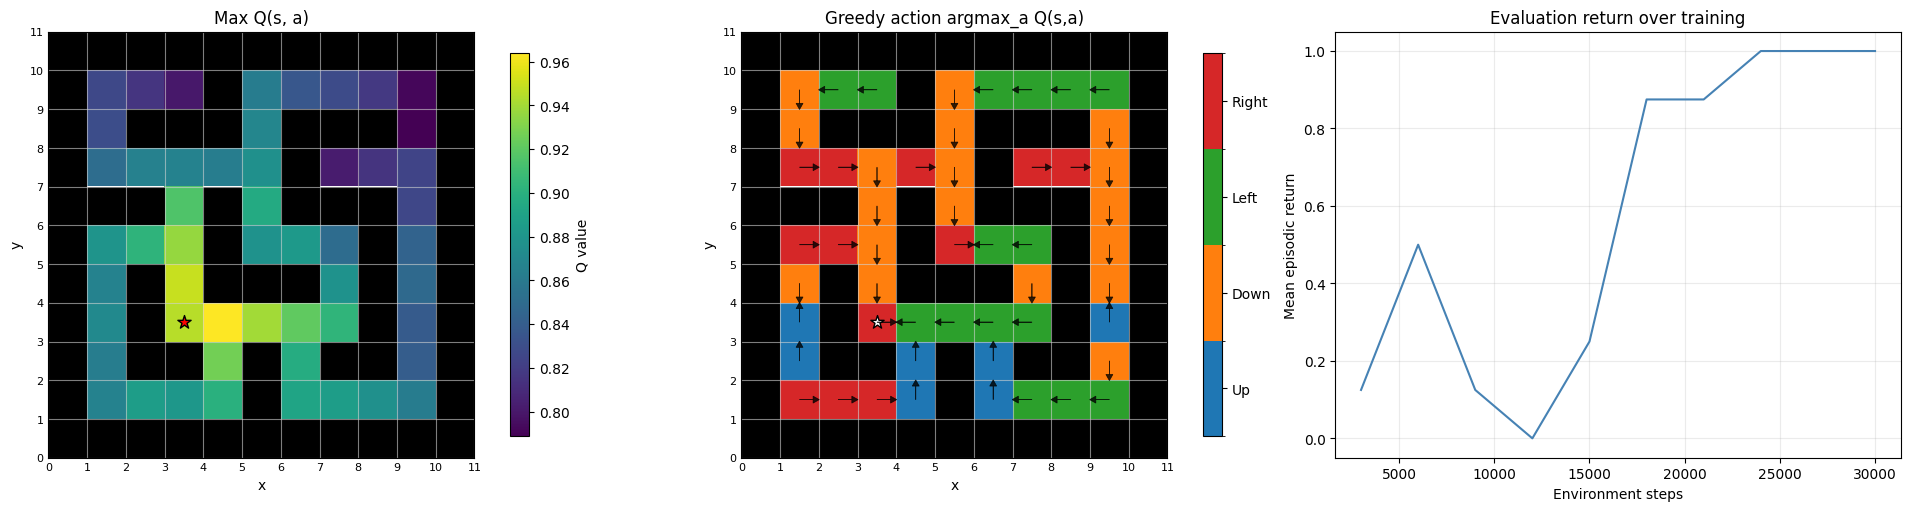

Episode 1: 13 steps | return: 1.00 | reached goal: True
Episode 2: 100 steps | return: 0.00 | reached goal: False
Episode 3: 2 steps | return: 1.00 | reached goal: True
Episode 4: 11 steps | return: 1.00 | reached goal: True
Episode 5: 2 steps | return: 1.00 | reached goal: True
Episode 6: 12 steps | return: 1.00 | reached goal: True
Episode 7: 7 steps | return: 1.00 | reached goal: True
Episode 8: 6 steps | return: 1.00 | reached goal: True

Success rate: 87.50% over 8 episodes
Average return: 0.88 ± 0.33


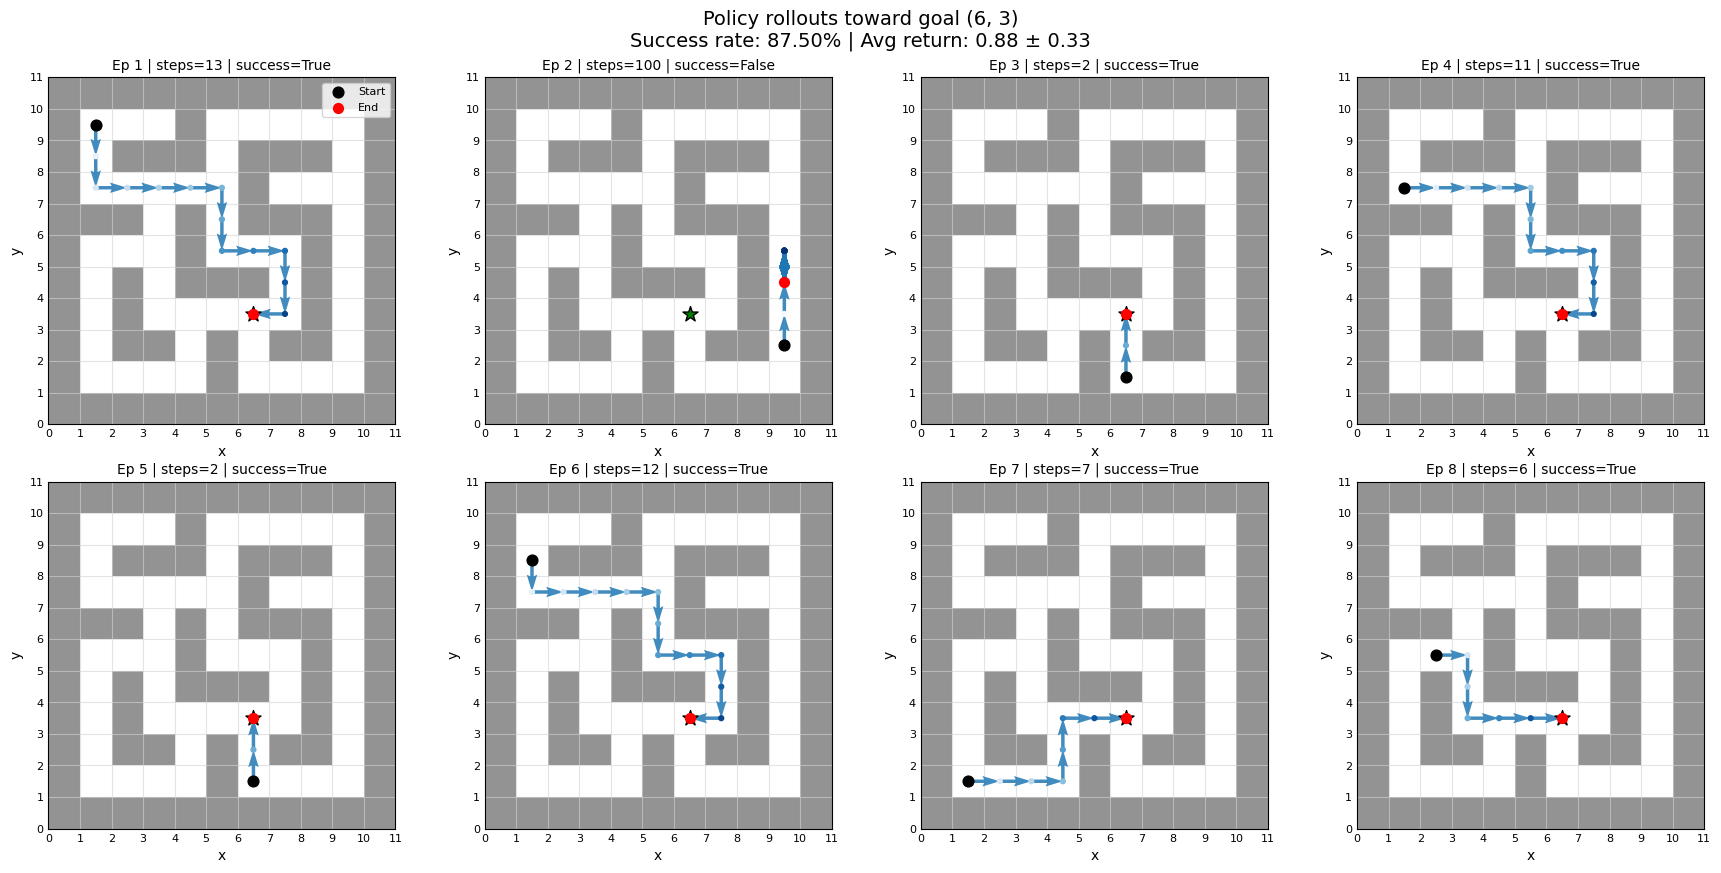

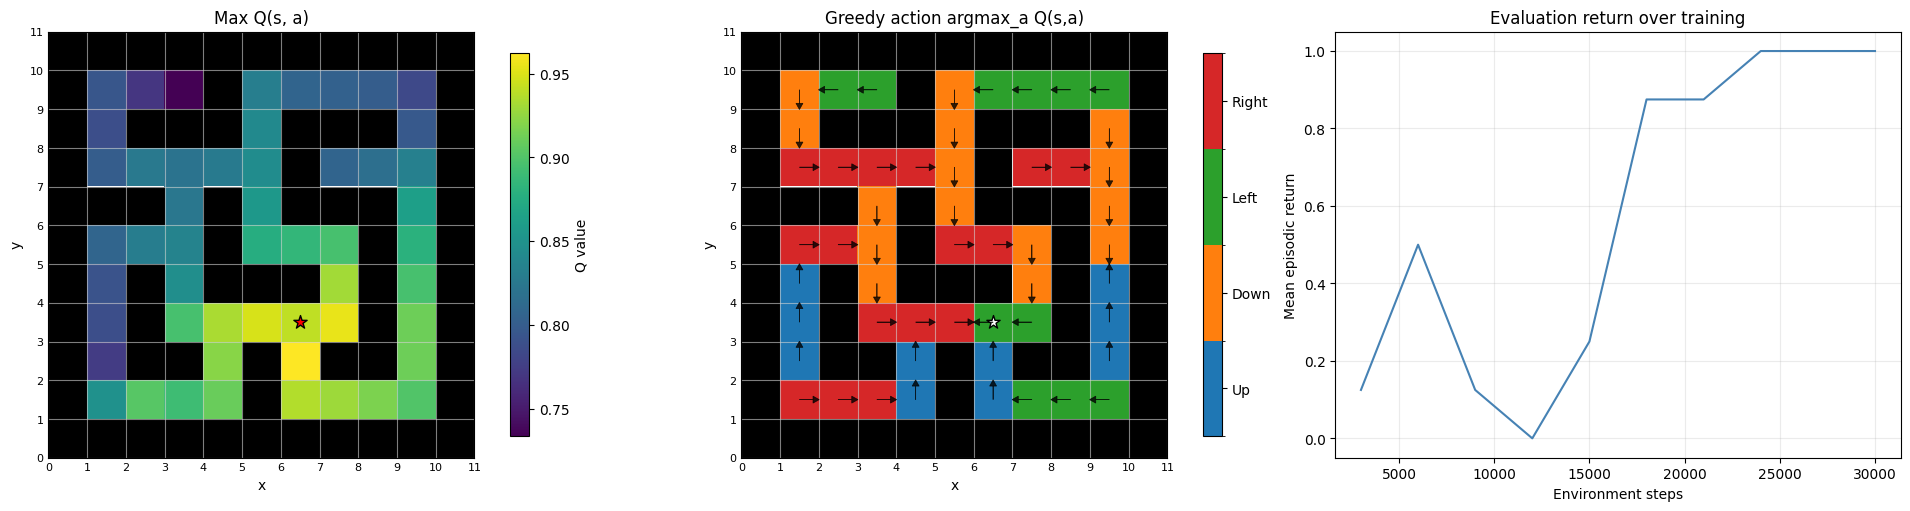

Episode 1: 18 steps | return: 1.00 | reached goal: True
Episode 2: 13 steps | return: 1.00 | reached goal: True
Episode 3: 1 steps | return: 1.00 | reached goal: True
Episode 4: 15 steps | return: 1.00 | reached goal: True
Episode 5: 11 steps | return: 1.00 | reached goal: True
Episode 6: 7 steps | return: 1.00 | reached goal: True
Episode 7: 10 steps | return: 1.00 | reached goal: True
Episode 8: 5 steps | return: 1.00 | reached goal: True

Success rate: 100.00% over 8 episodes
Average return: 1.00 ± 0.00


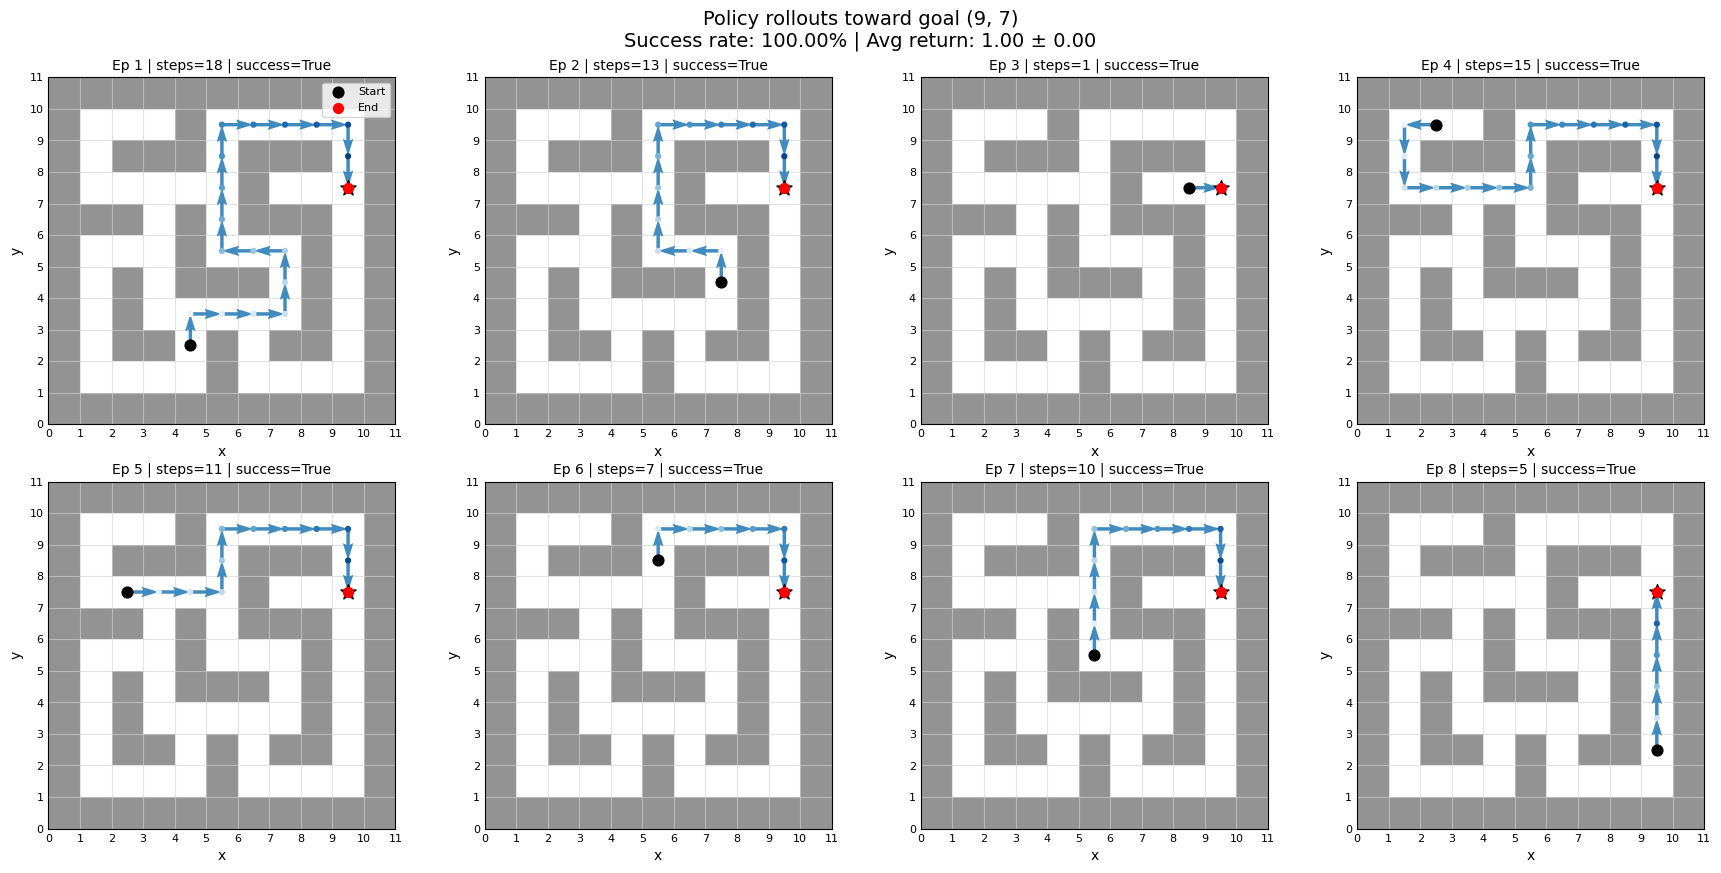

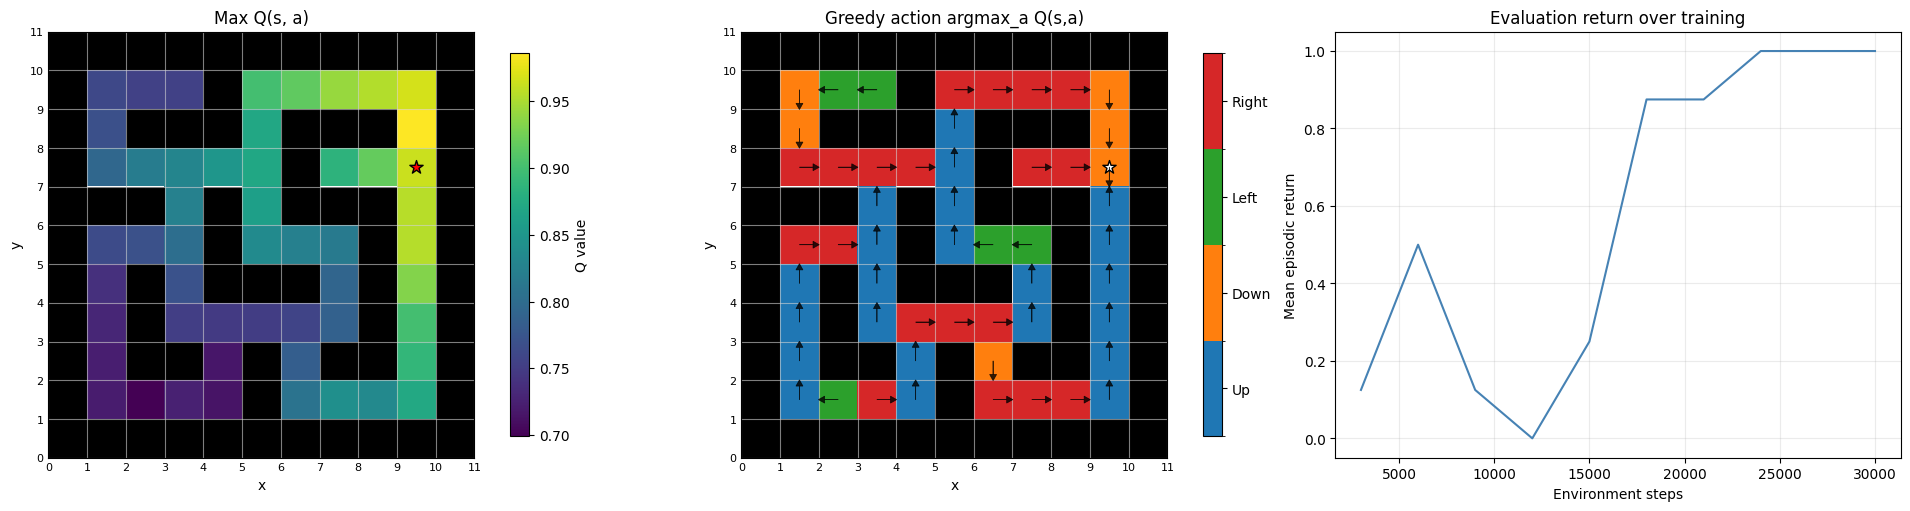

In [11]:
for goal in GOALS:

    visualise_q_table(
        goal=goal,
        q_network=q_network,
        eval_returns=eval_returns,
        device=DEVICE,
        make_env=make_env,
    )

## New Goal Test. 
Random sample goals from free cells, and check the embeddings. No training. This is to check the Spatial knowledge on psi(g)

## Backward Tasks Fine-tuning
Because embeddings have changed, to successfully achieve the earlier tasks, fine-tuning is needed.

In [ ]:


RETRAIN_LR = 1e-3
RETRAIN_GOALS_MODE = "all"   # "early", "all", or "custom"
RETRAIN_NUM_EARLY = 3
RETRAIN_CUSTOM_GOALS = []    # only used if RETRAIN_GOALS_MODE == "custom"


def freeze_sa_encoder_only(model):
    """
    Freeze sa_encoder parameters; leave everything else trainable.
    Returns the list of trainable parameters (for sanity check).
    """
    for name, p in model.named_parameters():
        if name.startswith("sa_encoder"):
            p.requires_grad_(False)
        else:
            p.requires_grad_(True)

    trainable_params = [p for p in model.parameters() if p.requires_grad]

    if len(trainable_params) == 0:
        raise ValueError("No trainable params left after freezing sa_encoder.")

    return trainable_params


# Build mapping: seed -> goal -> task_idx
seed_goal_to_task_idx = {
    seed: {goal: i for i, goal in enumerate(goals_by_seed[seed])}
    for seed in SEEDS
}


def get_baseline_for_goal(seed, goal):
    task_idx = seed_goal_to_task_idx[seed][goal]
    seed_pos = SEEDS.index(seed)  # 0 if only one seed
    return {
        "min_steps": overall_results[task_idx]["min_steps"][seed_pos],
        "min_time": overall_results[task_idx]["min_time"][seed_pos],
        "eval_returns": overall_results[task_idx]["eval_returns"][seed_pos],
    }


# Same structure as the original overall_results, so your plot function can be reused
overall_results_retrain = {
    goal: {
        "eval_returns": [],
        "min_steps": [],
        "min_time": [],
        "task_embeddings": [],
        "sa_embeddings": [],
        "sa_fixed_probe_embeddings": [],
        "sa_batches_final": [],
    }
    for goal in GOALS
}


# Baseline vs retrain comparison
retrain_comparison = {
    goal: {
        "baseline_min_steps": [],
        "baseline_min_time": [],
        "retrain_min_steps": [],
        "retrain_min_time": [],
        "steps_ratio": [],
        "time_ratio": [],
    }
    for goal in GOALS
}


for seed in SEEDS:
    print(f"\n================ BACKWARD RETRAIN SEED {seed} ================\n")
    set_seed(seed)

    env_tmp = make_env(goal=GOALS[0])
    obs_dim = env_tmp.observation_space.shape[0]
    num_actions = env_tmp.action_space.n
    env_tmp.close()

    seed_goals = goals_by_seed[seed]  # list of goals in order

    # Start from the final trained networks for this seed
    final_q_net = deepcopy(final_q_networks[seed]).to(DEVICE)
    final_q_target = deepcopy(final_q_target_networks[seed]).to(DEVICE)
    final_q_target.load_state_dict(final_q_net.state_dict())

    # -----------------------------------------------------
    # Decide which goals to retrain for this seed
    # -----------------------------------------------------

    if RETRAIN_GOALS_MODE == "early":
        retrain_goals = seed_goals[:RETRAIN_NUM_EARLY]
    elif RETRAIN_GOALS_MODE == "all":
        # Exclude the last task if you want only "old" ones
        retrain_goals = seed_goals
    elif RETRAIN_GOALS_MODE == "custom":
        retrain_goals = RETRAIN_CUSTOM_GOALS
    else:
        raise ValueError(f"Unknown RETRAIN_GOALS_MODE: {RETRAIN_GOALS_MODE}")

    # -----------------------------------------------------
    # Retrieve this seed's final task embeddings
    # -----------------------------------------------------

    # seed_task_memories[seed] is {task_idx: embedding_tensor}
    final_task_embedding_memory = deepcopy(seed_task_memories[seed])

    # We do NOT reuse old replay buffers here.
    # Each task will collect fresh data during fine-tuning.
    final_replay_task_buffers = {}

    for goal in retrain_goals:
        print(f"\n----- backward retrain: seed={seed}, goal={goal} -----\n")

        task_idx = seed_goal_to_task_idx[seed][goal]

        # -------------------------------------------------
        # Start from the final networks, but freeze sa_encoder
        # -------------------------------------------------

        q_net = deepcopy(final_q_net).to(DEVICE)
        q_target = deepcopy(final_q_target).to(DEVICE)
        q_target.load_state_dict(q_net.state_dict())

        # Freeze sa_encoder; only task codes and goal_encoder can change
        # trainable_params = freeze_sa_encoder_only(q_net)

        # -------------------------------------------------
        # Prepare task memory for this goal
        # -------------------------------------------------

        # Start from the final task embeddings learned in the forward pass.
        # The trainer will use task_embedding_memory[task_idx] to initialise
        # the trainable code for this task.
        task_embedding_memory_ft = deepcopy(final_task_embedding_memory)

        # No old-task replay buffers are used in this fine-tuning setup.
        replay_task_buffers_ft = {}

        # -------------------------------------------------
        # Call the trainer with:
        #   - lr_sa = 0.0 (no SA encoder updates; also frozen via requires_grad)
        #   - replay_ratio = 0.0 (no replay from other tasks)
        #   - Fresh data collection for this task only
        # -------------------------------------------------

        (
            q_network_ft,
            q_target_network_ft,
            eval_returns_ft,
            min_steps_ft,
            min_time_ft,
            final_task_embedding_ft,
            sa_embedding_mean_ft,
            sa_embedding_fixed_ft,
            sa_batch_final_ft,
            buffer_ft,
            collected_episodes_ft
        ) = dqn_train_phi_psi_adjustment(
            seed=seed,
            q_network=q_net,
            q_target_network=q_target,
            env=make_env(goal=goal),
            buffer_capacity=BUFFER_CAPACITY,
            lr_sa=RETRAIN_LR,
            lr_goal_init=RETRAIN_LR,
            lr_task_code=RETRAIN_LR,
            obs_dim=obs_dim,
            device=DEVICE,
            total_steps=100_000,
            warmup_steps=1_000,
            batch_size=256,
            eval_freq=1000,
            gamma=0.99,
            tau=0.005,
            eps_start=0.8,
            eps_end=0.05,
            eps_decay_steps=30000,
            train_freq=4,
            goal=goal,
            task_id=task_idx,
            make_env=make_env,
            td_steps=1,
            replay_task_buffers=replay_task_buffers_ft,
            replay_ratio=(task_idx +1),
            replay_tasks_per_batch=None,
            replay_loss_coef=1.0,
            task_goals=task_goals,
            bootstrap_on_truncation=True,
            early_stop_reward=0.99,
            early_stop_patience=3,
            enable_early_stop=True,

            # Start with SIGReg disabled to isolate the new
            # bounded-norm factorisation.
            sigreg_coef=0.01,
            sketch_dim=16,

            goal_separation_coef=0.04,
            goal_separation_target_cosine=0.70,
            psi_raw_norm_coef=2e-4,
            phi_raw_norm_coef=2e-4,
        )

        visualise_q_table(
            goal,
            q_network_ft,
            eval_returns=eval_returns_ft,
            device=DEVICE,
            make_env=make_env,
        )

        # -----------------------------------------------------
        # Visualise current-task state-action embeddings (baseline)
        # -----------------------------------------------------

        visualise_embeddings(
            goal,
            q_network_ft,
            device=DEVICE,
            make_env=make_env,
        )

        

        # -------------------------------------------------
        # Store results for this goal
        # -------------------------------------------------

        overall_results_retrain[goal]["eval_returns"].append(eval_returns_ft)
        overall_results_retrain[goal]["min_steps"].append(min_steps_ft)
        overall_results_retrain[goal]["min_time"].append(min_time_ft)
        overall_results_retrain[goal]["task_embeddings"].append(final_task_embedding_ft)
        overall_results_retrain[goal]["sa_embeddings"].append(sa_embedding_mean_ft)
        overall_results_retrain[goal]["sa_fixed_probe_embeddings"].append(sa_embedding_fixed_ft)
        overall_results_retrain[goal]["sa_batches_final"].append(sa_batch_final_ft)

        baseline = get_baseline_for_goal(seed, goal)

        steps_ratio = None
        time_ratio = None

        if baseline["min_steps"] is not None and min_steps_ft is not None:
            steps_ratio = min_steps_ft / baseline["min_steps"]

        if baseline["min_time"] is not None and min_time_ft is not None:
            time_ratio = min_time_ft / baseline["min_time"]

        retrain_comparison[goal]["baseline_min_steps"].append(baseline["min_steps"])
        retrain_comparison[goal]["baseline_min_time"].append(baseline["min_time"])
        retrain_comparison[goal]["retrain_min_steps"].append(min_steps_ft)
        retrain_comparison[goal]["retrain_min_time"].append(min_time_ft)
        retrain_comparison[goal]["steps_ratio"].append(steps_ratio)
        retrain_comparison[goal]["time_ratio"].append(time_ratio)

        print(
            f"[seed={seed} goal={goal}] "
            f"baseline_steps={baseline['min_steps']} | retrain_steps={min_steps_ft} | "
            f"steps_ratio={steps_ratio}"
        )
        print(
            f"[seed={seed} goal={goal}] "
            f"baseline_time={baseline['min_time']} | retrain_time={min_time_ft} | "
            f"time_ratio={time_ratio}"
        )


# Optional: reuse your existing plot function
plot_min_steps_and_min_time(overall_results=overall_results_retrain, seeds=SEEDS)


# =========================
# Summary across seeds
# =========================

print("\n===== Backward retrain summary (freeze sa_encoder only) =====\n")

goal_summaries = {}

for goal in GOALS:
    base_steps = np.array(
        [x for x in retrain_comparison[goal]["baseline_min_steps"] if x is not None],
        dtype=float,
    )
    base_time = np.array(
        [x for x in retrain_comparison[goal]["baseline_min_time"] if x is not None],
        dtype=float,
    )
    retrain_steps = np.array(
        [x for x in retrain_comparison[goal]["retrain_min_steps"] if x is not None],
        dtype=float,
    )
    retrain_time = np.array(
        [x for x in retrain_comparison[goal]["retrain_min_time"] if x is not None],
        dtype=float,
    )
    steps_ratios = np.array(
        [x for x in retrain_comparison[goal]["steps_ratio"] if x is not None],
        dtype=float,
    )
    time_ratios = np.array(
        [x for x in retrain_comparison[goal]["time_ratio"] if x is not None],
        dtype=float,
    )

    summary = {
        "n_seeds_steps": int(steps_ratios.size),
        "n_seeds_time": int(time_ratios.size),
        "baseline_steps_mean": float(base_steps.mean()) if base_steps.size > 0 else None,
        "baseline_steps_std": float(base_steps.std(ddof=1)) if base_steps.size > 1 else 0.0,
        "baseline_time_mean": float(base_time.mean()) if base_time.size > 0 else None,
        "baseline_time_std": float(base_time.std(ddof=1)) if base_time.size > 1 else 0.0,
        "retrain_steps_mean": float(retrain_steps.mean()) if retrain_steps.size > 0 else None,
        "retrain_steps_std": float(retrain_steps.std(ddof=1)) if retrain_steps.size > 1 else 0.0,
        "retrain_time_mean": float(retrain_time.mean()) if retrain_time.size > 0 else None,
        "retrain_time_std": float(retrain_time.std(ddof=1)) if retrain_time.size > 1 else 0.0,
        "steps_ratio_mean": float(steps_ratios.mean()) if steps_ratios.size > 0 else None,
        "steps_ratio_std": float(steps_ratios.std(ddof=1)) if steps_ratios.size > 1 else 0.0,
        "time_ratio_mean": float(time_ratios.mean()) if time_ratios.size > 0 else None,
        "time_ratio_std": float(time_ratios.std(ddof=1)) if time_ratios.size > 1 else 0.0,
    }

    goal_summaries[goal] = summary

    print(
        f"Goal {goal}: "
        f"baseline_steps_mean={summary['baseline_steps_mean']}, "
        f"retrain_steps_mean={summary['retrain_steps_mean']}, "
        f"steps_ratio_mean={summary['steps_ratio_mean']}, "
        f"n={summary['n_seeds_steps']}"
    )
    print(
        f"          baseline_time_mean={summary['baseline_time_mean']}, "
        f"retrain_time_mean={summary['retrain_time_mean']}, "
        f"time_ratio_mean={summary['time_ratio_mean']}, "
        f"n={summary['n_seeds_time']}\n"
    )

In [ ]:
plot_min_steps_and_min_time(overall_results=overall_results_retrain, seeds=SEEDS)

In [ ]:
from typing import Any, Dict, List, Optional, Tuple
import os
import numpy as np
import matplotlib.pyplot as plt


def find_goal_result(
    results: Dict[Any, Any],
    goal: Any,
    task_idx: Optional[int] = None,
) -> Optional[Dict[str, Any]]:
    """
    Find a result dictionary using either:
      1. task_idx, e.g. results[0], results[1], ...
      2. tuple goal, e.g. results[(4, 1)]
      3. string goal variants, e.g. "(4,1)" or "(4, 1)"
    """
    candidates = []

    if task_idx is not None:
        candidates.extend([task_idx, str(task_idx)])

    candidates.append(goal)

    if isinstance(goal, tuple):
        candidates.extend([
            str(goal),
            str(goal).replace(" ", ""),
            f"({goal[0]},{goal[1]})",
            f"({goal[0]}, {goal[1]})",
            f"{goal[0]},{goal[1]}",
            f"{goal[0]}, {goal[1]}",
        ])
    else:
        candidates.append(str(goal))

    for key in candidates:
        if key in results:
            return results[key]

    return None


def extract_seed_metric(
    result_entry: Optional[Dict[str, Any]],
    metric_name: str,
    seed_position: int,
) -> float:
    """
    Extract one seed's value from a result entry.

    Your initial overall_results structure stores metrics as lists:
        overall_results[task_idx]["min_steps"] = [seed_0_value, seed_1_value, ...]

    seed_position is the position of the seed in SEEDS, not necessarily
    the seed value itself.
    """
    if result_entry is None:
        return np.nan

    metric_values = result_entry.get(metric_name, None)

    if metric_values is None:
        return np.nan

    if np.isscalar(metric_values):
        value = metric_values
    else:
        if seed_position >= len(metric_values):
            return np.nan
        value = metric_values[seed_position]

    if value is None:
        return np.nan

    try:
        value = float(value)
    except (TypeError, ValueError):
        return np.nan

    return value if np.isfinite(value) else np.nan


def get_goal_for_task(
    initial_results: Dict[Any, Any],
    task_idx: int,
    seed: int,
    fallback_goals: Optional[List[Any]] = None,
) -> Any:
    """
    Retrieve the actual physical goal assigned to task_idx for a seed.

    Uses:
        overall_results[task_idx]["goals_by_seed"][seed]

    This matches your training loop exactly.
    """
    entry = initial_results.get(task_idx, {})

    if "goals_by_seed" in entry and seed in entry["goals_by_seed"]:
        return entry["goals_by_seed"][seed]

    if fallback_goals is not None and task_idx < len(fallback_goals):
        return fallback_goals[task_idx]

    return task_idx


def plot_cumulative_comparison(
    overall_results_initial: Dict[Any, Any],
    overall_results_retrain: Dict[Any, Any],
    seeds: List[int],
    num_goals: Optional[int] = None,
    goals: Optional[List[Any]] = None,
    save_path: Optional[str] = None,
    figsize: Tuple[float, float] = (15, 10),
    color_initial: str = "#1f77b4",
    color_retrain: str = "#d62728",
    alpha_lines: float = 0.85,
    alpha_shade: float = 0.18,
    marker_style: str = "o",
    marker_size: int = 6,
    line_width: float = 2.2,
    show_diagnostics: bool = True,
):
    """
    Compare sequential initial training against backward retraining.

    Initial result format expected
    ------------------------------
    overall_results_initial[task_idx] = {
        "goals_by_seed": {seed: goal_tuple},
        "min_steps": [value_for_seed_0, value_for_seed_1, ...],
        "min_time": [value_for_seed_0, value_for_seed_1, ...],
        ...
    }

    Retrain result format accepted
    ------------------------------
    The retrain dictionary may be keyed by:
      - task index: overall_results_retrain[task_idx]
      - physical goal tuple: overall_results_retrain[(x, y)]
      - string versions of goal tuples.
    """
    if num_goals is None:
        if goals is not None:
            num_goals = len(goals)
        else:
            numeric_keys = [key for key in overall_results_initial if isinstance(key, int)]
            num_goals = max(numeric_keys) + 1 if numeric_keys else len(overall_results_initial)

    if goals is not None and len(goals) != num_goals:
        raise ValueError(
            f"`goals` has {len(goals)} entries but num_goals={num_goals}."
        )

    if len(seeds) == 0:
        raise ValueError("`seeds` cannot be empty.")

    task_indices = np.arange(num_goals)
    n_seeds = len(seeds)

    # Arrays have shape: [seed_position, task_idx]
    initial_steps_by_seed = np.full((n_seeds, num_goals), np.nan)
    retrain_steps_by_seed = np.full((n_seeds, num_goals), np.nan)

    initial_times_by_seed = np.full((n_seeds, num_goals), np.nan)
    retrain_times_by_seed = np.full((n_seeds, num_goals), np.nan)

    goal_labels = []

    # Labels are derived from the first seed's actual sampled goals.
    label_seed = seeds[0]

    for task_idx in range(num_goals):
        physical_goal = get_goal_for_task(
            initial_results=overall_results_initial,
            task_idx=task_idx,
            seed=label_seed,
            fallback_goals=goals,
        )

        if isinstance(physical_goal, tuple) and len(physical_goal) == 2:
            goal_labels.append(f"({physical_goal[0]},{physical_goal[1]})")
        else:
            goal_labels.append(str(physical_goal))

    for seed_position, seed in enumerate(seeds):
        for task_idx in range(num_goals):
            physical_goal = get_goal_for_task(
                initial_results=overall_results_initial,
                task_idx=task_idx,
                seed=seed,
                fallback_goals=goals,
            )

            # Initial results are definitely task-index keyed.
            initial_entry = overall_results_initial.get(task_idx)

            # Retrain results may be keyed by task index or goal.
            retrain_entry = find_goal_result(
                results=overall_results_retrain,
                goal=physical_goal,
                task_idx=task_idx,
            )

            initial_steps_by_seed[seed_position, task_idx] = extract_seed_metric(
                initial_entry,
                metric_name="min_steps",
                seed_position=seed_position,
            )
            initial_times_by_seed[seed_position, task_idx] = extract_seed_metric(
                initial_entry,
                metric_name="min_time",
                seed_position=seed_position,
            )

            retrain_steps_by_seed[seed_position, task_idx] = extract_seed_metric(
                retrain_entry,
                metric_name="min_steps",
                seed_position=seed_position,
            )
            retrain_times_by_seed[seed_position, task_idx] = extract_seed_metric(
                retrain_entry,
                metric_name="min_time",
                seed_position=seed_position,
            )

            if show_diagnostics:
                print(
                    f"seed={seed:>4} | "
                    f"task={task_idx:>2} | "
                    f"goal={str(physical_goal):>8} | "
                    f"initial_steps={initial_steps_by_seed[seed_position, task_idx]} | "
                    f"retrain_steps={retrain_steps_by_seed[seed_position, task_idx]}"
                )

    # Mean/std across seeds for each task.
    initial_step_mean = np.nanmean(initial_steps_by_seed, axis=0)
    retrain_step_mean = np.nanmean(retrain_steps_by_seed, axis=0)

    initial_time_mean = np.nanmean(initial_times_by_seed, axis=0)
    retrain_time_mean = np.nanmean(retrain_times_by_seed, axis=0)

    if n_seeds > 1:
        initial_step_std = np.nanstd(initial_steps_by_seed, axis=0, ddof=1)
        retrain_step_std = np.nanstd(retrain_steps_by_seed, axis=0, ddof=1)

        initial_time_std = np.nanstd(initial_times_by_seed, axis=0, ddof=1)
        retrain_time_std = np.nanstd(retrain_times_by_seed, axis=0, ddof=1)
    else:
        initial_step_std = np.zeros(num_goals)
        retrain_step_std = np.zeros(num_goals)

        initial_time_std = np.zeros(num_goals)
        retrain_time_std = np.zeros(num_goals)

    # Compute cumulative quantities PER SEED before aggregate statistics.
    initial_cumulative_steps_by_seed = np.nancumsum(initial_steps_by_seed, axis=1)
    retrain_cumulative_steps_by_seed = np.nancumsum(retrain_steps_by_seed, axis=1)

    initial_cumulative_times_by_seed = np.nancumsum(initial_times_by_seed, axis=1)
    retrain_cumulative_times_by_seed = np.nancumsum(retrain_times_by_seed, axis=1)

    initial_cumulative_step_mean = np.nanmean(initial_cumulative_steps_by_seed, axis=0)
    retrain_cumulative_step_mean = np.nanmean(retrain_cumulative_steps_by_seed, axis=0)

    initial_cumulative_time_mean = np.nanmean(initial_cumulative_times_by_seed, axis=0)
    retrain_cumulative_time_mean = np.nanmean(retrain_cumulative_times_by_seed, axis=0)

    if n_seeds > 1:
        initial_cumulative_step_std = np.nanstd(
            initial_cumulative_steps_by_seed,
            axis=0,
            ddof=1,
        )
        retrain_cumulative_step_std = np.nanstd(
            retrain_cumulative_steps_by_seed,
            axis=0,
            ddof=1,
        )

        initial_cumulative_time_std = np.nanstd(
            initial_cumulative_times_by_seed,
            axis=0,
            ddof=1,
        )
        retrain_cumulative_time_std = np.nanstd(
            retrain_cumulative_times_by_seed,
            axis=0,
            ddof=1,
        )
    else:
        initial_cumulative_step_std = np.zeros(num_goals)
        retrain_cumulative_step_std = np.zeros(num_goals)

        initial_cumulative_time_std = np.zeros(num_goals)
        retrain_cumulative_time_std = np.zeros(num_goals)

    fig, axes = plt.subplots(
        2,
        2,
        figsize=figsize,
        constrained_layout=True,
    )

    ax_steps, ax_time = axes[0]
    ax_cumulative_steps, ax_cumulative_time = axes[1]

    # Per-goal steps
    ax_steps.plot(
        task_indices,
        initial_step_mean,
        color=color_initial,
        linestyle="-",
        marker=marker_style,
        markersize=marker_size,
        linewidth=line_width,
        alpha=alpha_lines,
        label="Initial training",
    )
    ax_steps.fill_between(
        task_indices,
        initial_step_mean - initial_step_std,
        initial_step_mean + initial_step_std,
        color=color_initial,
        alpha=alpha_shade,
    )

    ax_steps.plot(
        task_indices,
        retrain_step_mean,
        color=color_retrain,
        linestyle="--",
        marker=marker_style,
        markersize=marker_size,
        linewidth=line_width,
        alpha=alpha_lines,
        label="Backward retrain",
    )
    ax_steps.fill_between(
        task_indices,
        retrain_step_mean - retrain_step_std,
        retrain_step_mean + retrain_step_std,
        color=color_retrain,
        alpha=alpha_shade,
    )

    ax_steps.set_title(
        "Per-Task Steps to Solve",
        fontsize=12,
        fontweight="bold",
    )
    ax_steps.set_ylabel("Min steps to solve")
    ax_steps.set_xticks(task_indices)
    ax_steps.set_xticklabels(goal_labels, rotation=0, fontsize=9)
    ax_steps.legend()
    ax_steps.grid(alpha=0.3, linestyle="--")
    ax_steps.set_axisbelow(True)

    # Per-goal time
    ax_time.plot(
        task_indices,
        initial_time_mean,
        color=color_initial,
        linestyle="-",
        marker=marker_style,
        markersize=marker_size,
        linewidth=line_width,
        alpha=alpha_lines,
        label="Initial training",
    )
    ax_time.fill_between(
        task_indices,
        initial_time_mean - initial_time_std,
        initial_time_mean + initial_time_std,
        color=color_initial,
        alpha=alpha_shade,
    )

    ax_time.plot(
        task_indices,
        retrain_time_mean,
        color=color_retrain,
        linestyle="--",
        marker=marker_style,
        markersize=marker_size,
        linewidth=line_width,
        alpha=alpha_lines,
        label="Backward retrain",
    )
    ax_time.fill_between(
        task_indices,
        retrain_time_mean - retrain_time_std,
        retrain_time_mean + retrain_time_std,
        color=color_retrain,
        alpha=alpha_shade,
    )

    ax_time.set_title(
        "Per-Task Wall-clock Time",
        fontsize=12,
        fontweight="bold",
    )
    ax_time.set_ylabel("Min time (seconds)")
    ax_time.set_xticks(task_indices)
    ax_time.set_xticklabels(goal_labels, rotation=0, fontsize=9)
    ax_time.legend()
    ax_time.grid(alpha=0.3, linestyle="--")
    ax_time.set_axisbelow(True)

    # Cumulative steps
    ax_cumulative_steps.plot(
        task_indices,
        initial_cumulative_step_mean,
        color=color_initial,
        linestyle="-",
        marker=marker_style,
        markersize=marker_size,
        linewidth=line_width,
        alpha=alpha_lines,
        label="Initial training (cumulative)",
    )
    ax_cumulative_steps.fill_between(
        task_indices,
        initial_cumulative_step_mean - initial_cumulative_step_std,
        initial_cumulative_step_mean + initial_cumulative_step_std,
        color=color_initial,
        alpha=alpha_shade,
    )

    ax_cumulative_steps.plot(
        task_indices,
        retrain_cumulative_step_mean,
        color=color_retrain,
        linestyle="--",
        marker=marker_style,
        markersize=marker_size,
        linewidth=line_width,
        alpha=alpha_lines,
        label="Backward retrain (cumulative)",
    )
    ax_cumulative_steps.fill_between(
        task_indices,
        retrain_cumulative_step_mean - retrain_cumulative_step_std,
        retrain_cumulative_step_mean + retrain_cumulative_step_std,
        color=color_retrain,
        alpha=alpha_shade,
    )

    ax_cumulative_steps.set_title(
        "Cumulative Steps Across Tasks",
        fontsize=12,
        fontweight="bold",
    )
    ax_cumulative_steps.set_xlabel("Task / goal sequence")
    ax_cumulative_steps.set_ylabel("Cumulative min steps")
    ax_cumulative_steps.set_xticks(task_indices)
    ax_cumulative_steps.set_xticklabels(goal_labels, rotation=0, fontsize=9)
    ax_cumulative_steps.legend()
    ax_cumulative_steps.grid(alpha=0.3, linestyle="--")
    ax_cumulative_steps.set_axisbelow(True)

    # Cumulative time
    ax_cumulative_time.plot(
        task_indices,
        initial_cumulative_time_mean,
        color=color_initial,
        linestyle="-",
        marker=marker_style,
        markersize=marker_size,
        linewidth=line_width,
        alpha=alpha_lines,
        label="Initial training (cumulative)",
    )
    ax_cumulative_time.fill_between(
        task_indices,
        initial_cumulative_time_mean - initial_cumulative_time_std,
        initial_cumulative_time_mean + initial_cumulative_time_std,
        color=color_initial,
        alpha=alpha_shade,
    )

    ax_cumulative_time.plot(
        task_indices,
        retrain_cumulative_time_mean,
        color=color_retrain,
        linestyle="--",
        marker=marker_style,
        markersize=marker_size,
        linewidth=line_width,
        alpha=alpha_lines,
        label="Backward retrain (cumulative)",
    )
    ax_cumulative_time.fill_between(
        task_indices,
        retrain_cumulative_time_mean - retrain_cumulative_time_std,
        retrain_cumulative_time_mean + retrain_cumulative_time_std,
        color=color_retrain,
        alpha=alpha_shade,
    )

    ax_cumulative_time.set_title(
        "Cumulative Wall-clock Time Across Tasks",
        fontsize=12,
        fontweight="bold",
    )
    ax_cumulative_time.set_xlabel("Task / goal sequence")
    ax_cumulative_time.set_ylabel("Cumulative min time (seconds)")
    ax_cumulative_time.set_xticks(task_indices)
    ax_cumulative_time.set_xticklabels(goal_labels, rotation=0, fontsize=9)
    ax_cumulative_time.legend()
    ax_cumulative_time.grid(alpha=0.3, linestyle="--")
    ax_cumulative_time.set_axisbelow(True)

    fig.suptitle(
        f"Backward Retraining Analysis (freeze sa_encoder) | "
        f"Seeds: {seeds} | Tasks: {num_goals}",
        fontsize=13,
        fontweight="bold",
    )

    if save_path:
        output_dir = os.path.dirname(save_path)
        if output_dir:
            os.makedirs(output_dir, exist_ok=True)

        fig.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
            facecolor="white",
        )
        print(f"✓ Saved figure to: {save_path}")

    plt.show()

    return fig, axes

fig, axes = plot_cumulative_comparison(
    overall_results_initial=overall_results,
    overall_results_retrain=overall_results_retrain,
    seeds=SEEDS,
    num_goals=NUM_GOALS,
    save_path="figures/backward_retrain_comparison_lines.pdf",
    show_diagnostics=True,
)

## Baseline

In [ ]:
overall_results_baseline = {
    task_idx: {
        "goals_by_seed": {},
        "eval_returns": [],
        "eval_returns_time": [],
        "min_steps": [],
        "min_time": [],
        "task_embeddings": [],
        "sa_embeddings": [],
        "sa_fixed_probe_embeddings": [],
        "sa_batches_final": [],
        "sa_weight_change": [],
        "goal_weight_change": [],
        "goal_encoder_analysis": [],
    }
    for task_idx in range(NUM_GOALS)
}

goals_by_seed_baseline = {}
final_q_networks_baseline = {}
final_q_target_networks_baseline = {}
weight_history_by_seed_baseline = {}
seed_task_memories_baseline = {}
seed_retrieval_histories_baseline = {}


for seed in SEEDS:
    print(f"\n================ SEED {seed} (BASELINE) ================\n")

    set_seed(seed)

    # Use exactly the same goals for every seed.
    goals_by_seed_baseline[seed] = list(GOALS)

    for task_idx, goal in enumerate(GOALS):
        overall_results_baseline[task_idx]["goals_by_seed"][seed] = goal

    print(f"Sampled GOALS for seed {seed} (baseline): {GOALS}")

    # ---------------------------------------------------------
    # Environment and network initialisation (baseline)
    # ---------------------------------------------------------

    env_tmp = make_env(goal=GOALS[0])

    obs_dim = env_tmp.observation_space.shape[0]
    num_actions = env_tmp.action_space.n

    env_tmp.close()

    # Fresh random init for each seed and each task in baseline
    def make_fresh_q_networks():
        q_net = FactorisedDQN_QNetwork_BallNorm(
            obs_dim=obs_dim,
            num_actions=num_actions,
            goal_dim=2,
            hidden_dim=64,
            rep_dim=16,
            phi_max_norm=1.0,
            psi_max_norm=1.0,
        ).to(DEVICE)

        q_target = FactorisedDQN_QNetwork_BallNorm(
            obs_dim=obs_dim,
            num_actions=num_actions,
            goal_dim=2,
            hidden_dim=64,
            rep_dim=16,
            phi_max_norm=1.0,
            psi_max_norm=1.0,
        ).to(DEVICE)

        q_target.load_state_dict(q_net.state_dict())

        for parameter in q_net.parameters():
            parameter.requires_grad_(True)

        for parameter in q_target.parameters():
            parameter.requires_grad_(False)

        return q_net, q_target

    # ---------------------------------------------------------
    # Fixed state-action probes for visualisation (baseline)
    # ---------------------------------------------------------

    probe_env = make_env(goal=GOALS[0])

    fixed_probe_states_baseline = []
    fixed_probe_actions_baseline = []

    for probe_idx in range(10):
        obs, _ = probe_env.reset(
            seed=seed + 10_000 + probe_idx
        )

        action = probe_idx % num_actions

        fixed_probe_states_baseline.append(
            np.asarray(obs, dtype=np.float32)
        )

        fixed_probe_actions_baseline.append(action)

    probe_env.close()

    fixed_probe_obs_baseline = torch.as_tensor(
        np.asarray(fixed_probe_states_baseline, dtype=np.float32),
        dtype=torch.float32,
        device=DEVICE,
    )

    fixed_probe_actions_baseline = torch.as_tensor(
        np.asarray(fixed_probe_actions_baseline, dtype=np.int64),
        dtype=torch.long,
        device=DEVICE,
    )

    # ---------------------------------------------------------
    # No persistent task memory across tasks in baseline
    # ---------------------------------------------------------

    task_embedding_memory_baseline = {}
    task_goals_baseline = {}
    weight_history_baseline = []

    # =========================================================
    # Sequential task training (baseline: train from scratch)
    # =========================================================

    for task_idx, goal in enumerate(GOALS):
        task_label = f"task_{task_idx}"

        goal = np.asarray(goal, dtype=np.float32)
        task_goals_baseline[task_idx] = goal.copy()

        print(
            f"\n----- seed={seed}, "
            f"task_idx={task_idx}, "
            f"goal={goal} (baseline) -----\n"
        )

        # -----------------------------------------------------
        # Fresh random networks for each task (baseline)
        # -----------------------------------------------------

        q_net_base, q_target_base = make_fresh_q_networks()

        # -----------------------------------------------------
        # Record weights before training this task (baseline)
        # -----------------------------------------------------

        weight_history_baseline.append(
            collect_weight_snapshot(
                qnet=q_net_base,
                goal_label=task_label,
                stage_label=f"goal_{task_label}_before_train",
                sa_keywords_local=sa_keywords_local,
                goal_keywords_local=goal_keywords_local,
                max_samples_per_group=40000,
            )
        )

        # -----------------------------------------------------
        # Train the current task (baseline: no replay from other tasks)
        # -----------------------------------------------------

        (
            q_network,
            q_target_network,
            eval_returns,
            min_steps,
            min_time,
            final_task_embedding,
            sa_embedding_mean,
            sa_embedding_fixed,
            sa_batch_final,
            buffer,
            collected_episodes
        ) = dqn_train_phi_psi_adjustment(
            seed=seed,
            q_network=q_net_base,
            q_target_network=q_target_base,
            env=make_env(goal=goal),
            buffer_capacity=BUFFER_CAPACITY,
            lr_sa=LR,
            lr_goal_init=LR,
            obs_dim=obs_dim,
            device=DEVICE,
            total_steps=100_000,
            warmup_steps=1_000,
            batch_size=256,
            eval_freq=1000,
            gamma=0.99,
            tau=0.005,
            eps_start=1.0,
            eps_end=0.05,
            eps_decay_steps=60_000,
            train_freq=3,
            goal=goal,
            task_id=task_idx,
            make_env=make_env,
            td_steps=1,
            replay_task_buffers={},  # no cross-task replay in baseline
            replay_ratio=1,
            replay_tasks_per_batch=None,
            replay_loss_coef=0.0,    # no replay loss in baseline
            task_goals=task_goals_baseline,
            bootstrap_on_truncation=True,
            early_stop_reward=0.99,
            early_stop_patience=3,
            enable_early_stop=True,
            sigreg_coef=0.01,
            sketch_dim=16,
            goal_separation_coef=0.04,
            goal_separation_target_cosine=0.70,
            psi_raw_norm_coef=2e-4,
            phi_raw_norm_coef=2e-4,
        )

        # -----------------------------------------------------
        # Record weights after training this task (baseline)
        # -----------------------------------------------------

        weight_history_baseline.append(
            collect_weight_snapshot(
                qnet=q_network,
                goal_label=goal,
                stage_label=f"{task_idx}_after_train",
                sa_keywords_local=sa_keywords_local,
                goal_keywords_local=goal_keywords_local,
                max_samples_per_group=40000,
            )
        )

        # -----------------------------------------------------
        # Visualise current-task Q-values (baseline)
        # -----------------------------------------------------

        visualise_q_table(
            goal,
            q_network,
            eval_returns=eval_returns,
            device=DEVICE,
            make_env=make_env,
        )

        # -----------------------------------------------------
        # Visualise current-task state-action embeddings (baseline)
        # -----------------------------------------------------

        visualise_embeddings(
            goal,
            q_network,
            device=DEVICE,
            make_env=make_env,
        )

        before_snap = weight_history_baseline[-2]
        after_snap = weight_history_baseline[-1]

        sa_change_stats = compute_weight_change_from_snapshots(
            before_snap,
            after_snap,
            prefix="sa",
        )

        goal_change_stats = compute_weight_change_from_snapshots(
            before_snap,
            after_snap,
            prefix="goal",
        )

        # -----------------------------------------------------
        # Encode all seen goals and fixed SA probes (baseline)
        # -----------------------------------------------------

        q_network.eval()


        # -----------------------------------------------------
        # Store results for this task (baseline)
        # -----------------------------------------------------

        overall_results_baseline[task_idx]["eval_returns"].append(
            eval_returns
        )

        overall_results_baseline[task_idx]["min_steps"].append(
            min_steps
        )

        overall_results_baseline[task_idx]["min_time"].append(
            min_time
        )



    final_q_networks_baseline[seed] = deepcopy(q_network).eval()

    final_q_target_networks_baseline[seed] = deepcopy(
        q_target_network
    ).eval()

    weight_history_by_seed_baseline[seed] = deepcopy(weight_history_baseline)

    seed_task_memories_baseline[seed] = deepcopy(task_embedding_memory_baseline)

    seed_retrieval_histories_baseline[seed] = []

    print(
        f"\nSaved final networks and task memory for seed {seed} (baseline)."
    )

In [ ]:
plot_min_steps_and_min_time(overall_results=overall_results_baseline, seeds=SEEDS)

In [ ]:
import pickle
from pathlib import Path

results_dir = Path("results")
results_dir.mkdir(exist_ok=True)

checkpoint = {
    "overall_results": overall_results,
    "overall_results_retrain": overall_results_retrain,
    "overall_results_baseline": overall_results_baseline,
}

results_path = results_dir / "results.pkl"

with open(results_path, "wb") as f:
    pickle.dump(checkpoint, f)

In [ ]:
from typing import Any, Dict, List, Optional, Tuple
import os

import numpy as np
import matplotlib.pyplot as plt


def plot_three_min_steps_comparison(
    overall_results: Dict[Any, Any],
    overall_results_baseline: Dict[Any, Any],
    overall_results_retrain: Dict[Any, Any],
    seeds: List[int],
    goals: List[Any],
    labels: Optional[List[str]] = None,
    num_goals: Optional[int] = None,
    save_path: Optional[str] = None,
    figsize: Tuple[float, float] = (10, 14),
    colors: Optional[List[str]] = None,
    alpha_lines: float = 0.9,
    alpha_shade: float = 0.18,
    marker_style: str = "o",
    marker_size: int = 6,
    line_width: float = 2.2,
    bar_alpha: float = 0.85,
    show_diagnostics: bool = True,
):
    """
    Compare min_steps from three dictionaries with different key formats.

    Dictionary formats
    ------------------

    overall_results:
        overall_results[task_idx]["min_steps"]

    overall_results_baseline:
        overall_results_baseline[task_idx]["min_steps"]

    overall_results_retrain:
        overall_results_retrain[goal]["min_steps"]

    The mapping for the goal-indexed retraining dictionary is:

        task_idx -> goals[task_idx]

    Thus, for task_idx=3, the retraining lookup is:

        overall_results_retrain[goals[3]]
    """

    if labels is None:
        labels = [
            "TBTRL (ours)",
            "Retrain baseline",
            "Backward task revisit",
        ]

    if len(labels) != 3:
        raise ValueError("`labels` must contain exactly three labels.")

    if colors is None:
        colors = [
            "#1f77b4",
            "#d62728",
            "#2ca02c",
        ]

    if len(colors) != 3:
        raise ValueError("`colors` must contain exactly three colors.")

    if len(seeds) == 0:
        raise ValueError("`seeds` cannot be empty.")

    if num_goals is None:
        num_goals = len(goals)

    if num_goals > len(goals):
        raise ValueError(
            f"num_goals={num_goals}, but only {len(goals)} goals were supplied."
        )

    result_dicts = [
        overall_results,
        overall_results_baseline,
        overall_results_retrain,
    ]

    n_methods = 3
    n_seeds = len(seeds)
    task_indices = np.arange(num_goals)

    # Shape:
    # [method, seed_position, task_idx]
    min_steps_by_seed = np.full(
        (n_methods, n_seeds, num_goals),
        np.nan,
        dtype=float,
    )

    def get_task_entry(results, task_idx):
        """
        Lookup an entry in a task-indexed dictionary.

        Supports both integer and string task keys.
        """
        if task_idx in results:
            return results[task_idx], f"task key {task_idx!r}"

        if str(task_idx) in results:
            return results[str(task_idx)], (
                f"task key {str(task_idx)!r}"
            )

        return None, None

    def get_goal_entry(results, goal):
        """
        Lookup an entry in a goal-indexed dictionary.

        Supports tuple goals and common string representations.
        """
        candidate_keys = [
            goal,
            str(goal),
        ]

        if isinstance(goal, tuple):
            candidate_keys.extend(
                [
                    str(goal).replace(" ", ""),
                    f"({goal[0]},{goal[1]})",
                    f"({goal[0]}, {goal[1]})",
                    f"{goal[0]},{goal[1]}",
                    f"{goal[0]}, {goal[1]}",
                ]
            )

        for key in candidate_keys:
            if key in results:
                return results[key], f"goal key {key!r}"

        return None, None

    def extract_seed_metric(
        entry,
        metric_name: str,
        seed_position: int,
    ):
        """
        Extract one seed's metric from a result entry.
        """
        if entry is None or not isinstance(entry, dict):
            return np.nan

        metric_values = entry.get(metric_name)

        if metric_values is None:
            return np.nan

        if np.isscalar(metric_values):
            value = metric_values
        else:
            if seed_position >= len(metric_values):
                return np.nan

            value = metric_values[seed_position]

        if value is None:
            return np.nan

        try:
            value = float(value)
        except (TypeError, ValueError):
            return np.nan

        return value if np.isfinite(value) else np.nan

    # --------------------------------------------------------------
    # Extract values
    # --------------------------------------------------------------
    for seed_position, seed in enumerate(seeds):
        for task_idx in range(num_goals):
            # The task index is mapped to the corresponding goal only
            # for the goal-indexed retraining dictionary.
            physical_goal = goals[task_idx]

            # First dictionary: task-indexed.
            entry_ours, matched_ours = get_task_entry(
                overall_results,
                task_idx,
            )

            # Second dictionary: task-indexed.
            entry_baseline, matched_baseline = get_task_entry(
                overall_results_baseline,
                task_idx,
            )

            # Third dictionary: goal-indexed.
            entry_retrain, matched_retrain = get_goal_entry(
                overall_results_retrain,
                physical_goal,
            )

            entries = [
                entry_ours,
                entry_baseline,
                entry_retrain,
            ]

            matched_keys = [
                matched_ours,
                matched_baseline,
                matched_retrain,
            ]

            for method_idx, entry in enumerate(entries):
                value = extract_seed_metric(
                    entry=entry,
                    metric_name="min_steps",
                    seed_position=seed_position,
                )

                min_steps_by_seed[
                    method_idx,
                    seed_position,
                    task_idx,
                ] = value

                if show_diagnostics:
                    print(
                        f"method={labels[method_idx]:>24} | "
                        f"seed={seed:>4} | "
                        f"task={task_idx:>2} | "
                        f"goal={str(physical_goal):>8} | "
                        f"matched={str(matched_keys[method_idx]):>24} | "
                        f"min_steps={value}"
                    )

    # --------------------------------------------------------------
    # Aggregate across seeds
    # --------------------------------------------------------------
    mean_steps = np.nanmean(
        min_steps_by_seed,
        axis=1,
    )

    if n_seeds > 1:
        std_steps = np.nanstd(
            min_steps_by_seed,
            axis=1,
            ddof=1,
        )
    else:
        std_steps = np.zeros_like(mean_steps)

    # --------------------------------------------------------------
    # Cumulative statistics
    # --------------------------------------------------------------
    cumulative_steps_by_seed = np.nancumsum(
        min_steps_by_seed,
        axis=2,
    )

    cumulative_mean_steps = np.nanmean(
        cumulative_steps_by_seed,
        axis=1,
    )

    if n_seeds > 1:
        cumulative_std_steps = np.nanstd(
            cumulative_steps_by_seed,
            axis=1,
            ddof=1,
        )
    else:
        cumulative_std_steps = np.zeros_like(cumulative_mean_steps)

    # --------------------------------------------------------------
    # Plotting
    # --------------------------------------------------------------
    fig, axes = plt.subplots(
        3,
        1,
        figsize=figsize,
        constrained_layout=True,
    )

    ax_per_task, ax_cumulative, ax_bars = axes

    # --------------------------------------------------------------
    # Plot 1: Per-task mean minimum steps
    # --------------------------------------------------------------
    for method_idx, label in enumerate(labels):
        mean_values = mean_steps[method_idx]
        std_values = std_steps[method_idx]
        color = colors[method_idx]

        ax_per_task.plot(
            task_indices,
            mean_values,
            color=color,
            linestyle="-",
            marker=marker_style,
            markersize=marker_size,
            linewidth=line_width,
            alpha=alpha_lines,
            label=label,
        )

        valid = (
            np.isfinite(mean_values)
            & np.isfinite(std_values)
        )

        ax_per_task.fill_between(
            task_indices,
            mean_values - std_values,
            mean_values + std_values,
            where=valid,
            color=color,
            alpha=alpha_shade,
        )

    ax_per_task.set_title(
        "Mean Minimum Steps per Task",
        fontsize=12,
        fontweight="bold",
    )
    ax_per_task.set_ylabel("Minimum steps")
    ax_per_task.set_xlabel("Task index")
    ax_per_task.set_xticks(task_indices)
    ax_per_task.set_xticklabels(task_indices)
    ax_per_task.grid(alpha=0.3, linestyle="--")
    ax_per_task.set_axisbelow(True)
    ax_per_task.legend()

    # --------------------------------------------------------------
    # Plot 2: Cumulative mean minimum steps
    # --------------------------------------------------------------
    for method_idx, label in enumerate(labels):
        mean_values = cumulative_mean_steps[method_idx]
        std_values = cumulative_std_steps[method_idx]
        color = colors[method_idx]

        ax_cumulative.plot(
            task_indices,
            mean_values,
            color=color,
            linestyle="-",
            marker=marker_style,
            markersize=marker_size,
            linewidth=line_width,
            alpha=alpha_lines,
            label=label,
        )

        valid = (
            np.isfinite(mean_values)
            & np.isfinite(std_values)
        )

        ax_cumulative.fill_between(
            task_indices,
            mean_values - std_values,
            mean_values + std_values,
            where=valid,
            color=color,
            alpha=alpha_shade,
        )

    ax_cumulative.set_title(
        "Cumulative Minimum Steps",
        fontsize=12,
        fontweight="bold",
    )
    ax_cumulative.set_ylabel("Cumulative steps")
    ax_cumulative.set_xlabel("Task index")
    ax_cumulative.set_xticks(task_indices)
    ax_cumulative.set_xticklabels(task_indices)
    ax_cumulative.grid(alpha=0.3, linestyle="--")
    ax_cumulative.set_axisbelow(True)
    ax_cumulative.legend()

    # --------------------------------------------------------------
    # Plot 3: Grouped bar chart
    # --------------------------------------------------------------
    bar_width = 0.8 / n_methods

    for method_idx, label in enumerate(labels):
        offsets = (
            task_indices
            - 0.4
            + bar_width / 2
            + method_idx * bar_width
        )

        bar_values = mean_steps[method_idx]
        bar_errors = std_steps[method_idx]

        # Avoid passing NaN values to bar errorbars.
        safe_values = np.nan_to_num(
            bar_values,
            nan=0.0,
        )

        safe_errors = np.nan_to_num(
            bar_errors,
            nan=0.0,
        )

        ax_bars.bar(
            offsets,
            safe_values,
            width=bar_width,
            color=colors[method_idx],
            alpha=bar_alpha,
            edgecolor="black",
            linewidth=0.5,
            label=label,
            yerr=safe_errors,
            capsize=3,
            error_kw={
                "elinewidth": 1.0,
                "ecolor": "black",
            },
        )

        # Hide bars whose values were genuinely missing.
        missing = ~np.isfinite(bar_values)

        for offset, is_missing in zip(offsets, missing):
            if is_missing:
                ax_bars.add_patch(
                    plt.Rectangle(
                        (
                            offset - bar_width / 2,
                            0,
                        ),
                        bar_width,
                        0,
                        fill=False,
                        edgecolor="none",
                    )
                )

    ax_bars.set_title(
        "Mean Minimum Steps per Task",
        fontsize=12,
        fontweight="bold",
    )
    ax_bars.set_ylabel("Minimum steps")
    ax_bars.set_xlabel("Task index")
    ax_bars.set_xticks(task_indices)
    ax_bars.set_xticklabels(task_indices)
    ax_bars.grid(alpha=0.3, axis="y", linestyle="--")
    ax_bars.set_axisbelow(True)
    ax_bars.legend()

    fig.suptitle(
        "Steps Taken to learn each Task in GridWorld Maze Environment\n"
        f"Seeds: {seeds} | Tasks: {num_goals}",
        fontsize=14,
        fontweight="bold",
    )

    if save_path:
        output_dir = os.path.dirname(save_path)

        if output_dir:
            os.makedirs(output_dir, exist_ok=True)

        fig.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
            facecolor="white",
        )

        print(f"Saved figure to: {save_path}")

    plt.show()

    return {
        "figure": fig,
        "axes": axes,
        "min_steps_by_seed": min_steps_by_seed,
        "mean_steps": mean_steps,
        "std_steps": std_steps,
        "cumulative_steps_by_seed": cumulative_steps_by_seed,
        "cumulative_mean_steps": cumulative_mean_steps,
        "cumulative_std_steps": cumulative_std_steps,
    }

In [ ]:
plot_data = plot_three_min_steps_comparison(
    overall_results=overall_results,
    overall_results_baseline=overall_results_baseline,
    overall_results_retrain=overall_results_retrain,
    seeds=SEEDS,
    goals=GOALS,
    labels=[
        "TBTRL (ours)",
        "Scratch Training Baseline",
        "Backward Task Revisit",
    ],
    num_goals=NUM_GOALS,
    figsize=(10, 14),
    save_path="figures/three_method_min_steps_comparison.pdf",
    show_diagnostics=True,
)

In [ ]:
from typing import Any, Dict, List, Optional
import numpy as np


def get_mean_min_steps_three_dicts(
    overall_results: Dict[Any, Any],
    overall_results_baseline: Dict[Any, Any],
    overall_results_retrain: Dict[Any, Any],
    seeds: List[int],
    goals: List[Any],
    num_goals: Optional[int] = None,
    show_diagnostics: bool = True,
):
    """
    Return mean min_steps per task for three result dictionaries.

    Dictionary structures
    ---------------------

    Task-indexed dictionaries:

        overall_results[task_idx]["min_steps"]
        overall_results_baseline[task_idx]["min_steps"]

    Goal-indexed dictionary:

        overall_results_retrain[goal]["min_steps"]

    The mapping used for the goal-indexed dictionary is:

        task_idx -> goals[task_idx]

    Parameters
    ----------
    overall_results:
        First task-indexed result dictionary.

    overall_results_baseline:
        Second task-indexed result dictionary.

    overall_results_retrain:
        Third goal-indexed result dictionary.

    seeds:
        List of seeds. The order must match the order of values in
        each "min_steps" list.

    goals:
        Ordered list of goals. `goals[task_idx]` must correspond to
        the goal used as a key in overall_results_retrain.

    num_goals:
        Number of tasks. Defaults to len(goals).

    Returns
    -------
    dict
        Dictionary containing:

        {
            "task_indices": np.ndarray,
            "goals": list,
            "means": np.ndarray,
            "per_method": {
                label: np.ndarray
            },
            "raw_values": np.ndarray
        }

        `means` has shape [3, num_goals].
        `raw_values` has shape [3, num_seeds, num_goals].
    """

    if len(seeds) == 0:
        raise ValueError("`seeds` cannot be empty.")

    if num_goals is None:
        num_goals = len(goals)

    if num_goals > len(goals):
        raise ValueError(
            f"num_goals={num_goals}, but only {len(goals)} goals were supplied."
        )

    labels = [
        "TBTRL (ours)",
        "Retrain baseline",
        "Backward task revisit",
    ]

    n_methods = 3
    n_seeds = len(seeds)

    # Shape: [method, seed_position, task_idx]
    raw_values = np.full(
        (n_methods, n_seeds, num_goals),
        np.nan,
        dtype=float,
    )

    def get_task_entry(results, task_idx):
        """
        Retrieve an entry from a task-indexed dictionary.
        Supports integer or string task keys.
        """
        if task_idx in results:
            return results[task_idx], f"task key {task_idx!r}"

        string_key = str(task_idx)

        if string_key in results:
            return results[string_key], (
                f"task key {string_key!r}"
            )

        return None, None

    def get_goal_entry(results, goal):
        """
        Retrieve an entry from a goal-indexed dictionary.
        Supports tuple keys and common string representations.
        """
        candidates = [
            goal,
            str(goal),
        ]

        if isinstance(goal, tuple):
            candidates.extend(
                [
                    str(goal).replace(" ", ""),
                    f"({goal[0]},{goal[1]})",
                    f"({goal[0]}, {goal[1]})",
                    f"{goal[0]},{goal[1]}",
                    f"{goal[0]}, {goal[1]}",
                ]
            )

        for key in candidates:
            if key in results:
                return results[key], f"goal key {key!r}"

        return None, None

    def extract_seed_value(entry, seed_position):
        """
        Extract one seed's min_steps value.
        """
        if entry is None or not isinstance(entry, dict):
            return np.nan

        values = entry.get("min_steps")

        if values is None:
            return np.nan

        if np.isscalar(values):
            value = values
        else:
            if seed_position >= len(values):
                return np.nan

            value = values[seed_position]

        if value is None:
            return np.nan

        try:
            value = float(value)
        except (TypeError, ValueError):
            return np.nan

        return value if np.isfinite(value) else np.nan

    # --------------------------------------------------------------
    # Extract values
    # --------------------------------------------------------------
    for seed_position, seed in enumerate(seeds):
        for task_idx in range(num_goals):
            goal = goals[task_idx]

            # First dictionary: task-indexed.
            entry_ours, key_ours = get_task_entry(
                overall_results,
                task_idx,
            )

            # Second dictionary: task-indexed.
            entry_baseline, key_baseline = get_task_entry(
                overall_results_baseline,
                task_idx,
            )

            # Third dictionary: goal-indexed.
            entry_retrain, key_retrain = get_goal_entry(
                overall_results_retrain,
                goal,
            )

            entries = [
                entry_ours,
                entry_baseline,
                entry_retrain,
            ]

            matched_keys = [
                key_ours,
                key_baseline,
                key_retrain,
            ]

            for method_idx, entry in enumerate(entries):
                value = extract_seed_value(
                    entry,
                    seed_position,
                )

                raw_values[
                    method_idx,
                    seed_position,
                    task_idx,
                ] = value

                if show_diagnostics:
                    print(
                        f"method={labels[method_idx]:>24} | "
                        f"seed={seed:>4} | "
                        f"task={task_idx:>2} | "
                        f"goal={str(goal):>8} | "
                        f"matched={str(matched_keys[method_idx]):>24} | "
                        f"min_steps={value}"
                    )

    # Mean across seeds for each method and task.
    means = np.nanmean(
        raw_values,
        axis=1,
    )

    # Explicit warnings for tasks with no valid values.
    for method_idx, label in enumerate(labels):
        for task_idx in range(num_goals):
            task_values = raw_values[
                method_idx,
                :,
                task_idx,
            ]

            if np.all(np.isnan(task_values)):
                print(
                    f"[WARN] No valid min_steps for "
                    f"{label}, task {task_idx}, "
                    f"goal {goals[task_idx]}"
                )

    return {
        "task_indices": np.arange(num_goals),
        "goals": list(goals[:num_goals]),
        "means": means,
        "per_method": {
            labels[method_idx]: means[method_idx]
            for method_idx in range(n_methods)
        },
        "raw_values": raw_values,
        "labels": labels,
    }

step_statistics = get_mean_min_steps_three_dicts(
    overall_results=overall_results,
    overall_results_baseline=overall_results_baseline,
    overall_results_retrain=overall_results_retrain,
    seeds=SEEDS,
    goals=GOALS,
    num_goals=NUM_GOALS,
)
ours_mean = step_statistics["per_method"]["TBTRL (ours)"]
baseline_mean = step_statistics["per_method"]["Retrain baseline"]
retrain_mean = step_statistics["per_method"]["Backward task revisit"]

print(ours_mean, baseline_mean, retrain_mean)
# (3, NUM_GOALS)